Starting lightweight degree-preserving SBM analysis...
Reading CSV files and building original graph...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Creating lightweight degree-preserved SBM graph...
Identifying intra-module and inter-module edges...
Identified 547299 intra-module edges
Identified 302682 inter-module edges
Preserving inter-module connections...
Added 302682 inter-module edges to SBM
Randomizing intra-module connections using configuration model...
Processing module 3 with 2256 nodes...
Module 3: 66706 internal edges
Added 66706 randomized intra-module edges for module 3
Processing module 46 with 11 nodes...
Module 46: 12 internal edges
Added 12 randomized intra-module edges for module 46
Processing module 21 with 705 nodes...
Module 21: 15734 internal edges
Add

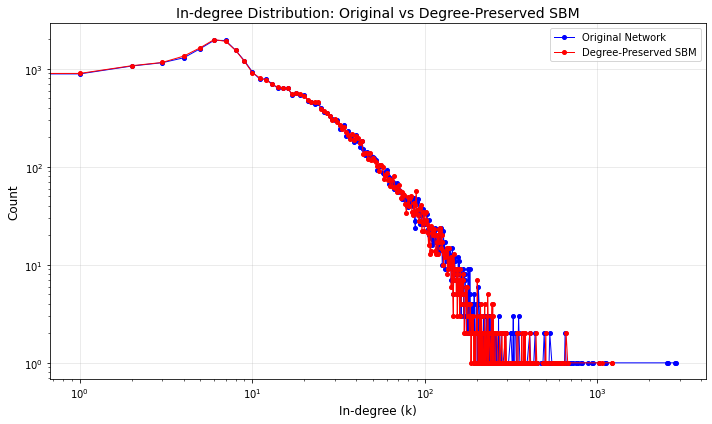

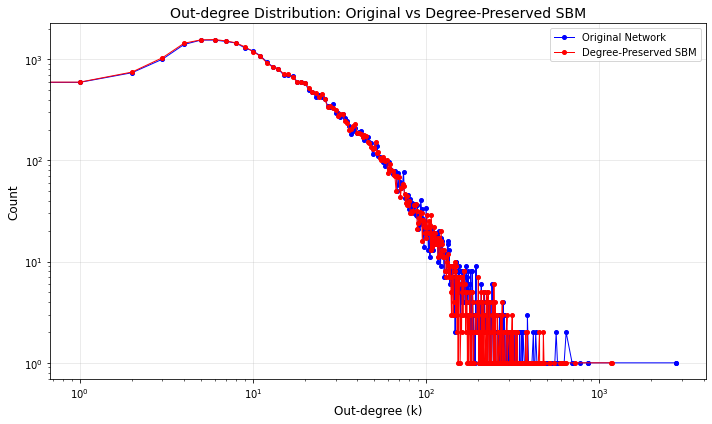

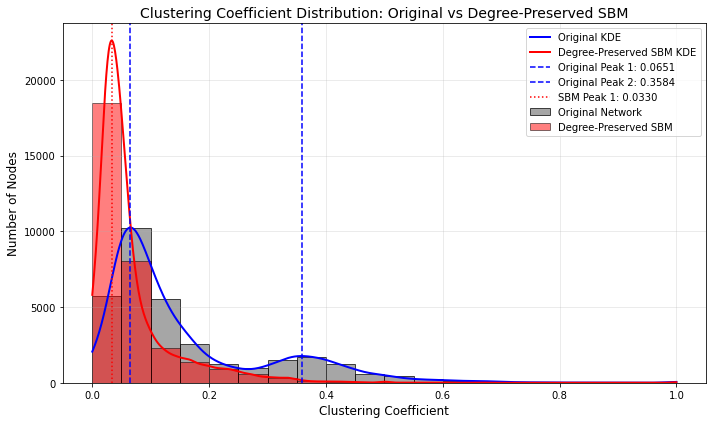

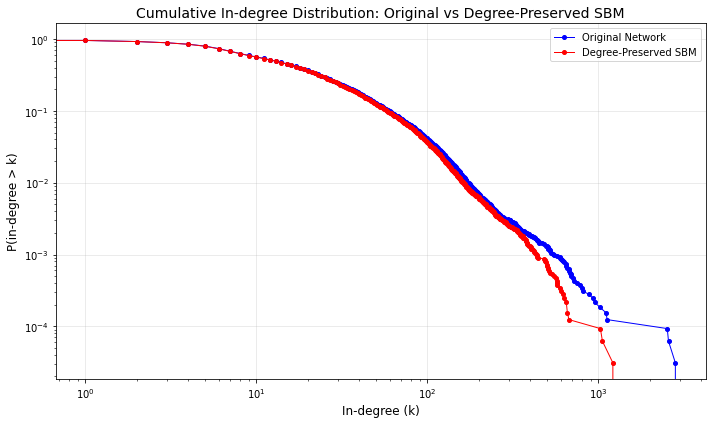

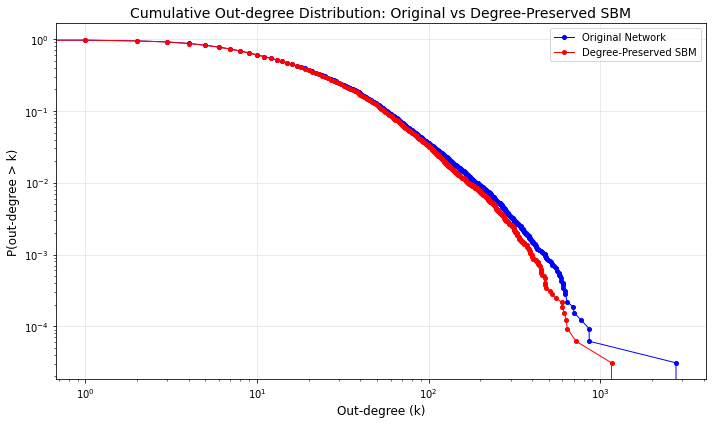

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import time

print("Starting lightweight degree-preserving SBM analysis...")
start_time = time.time()

# Read the data (assuming the original graph G is already loaded)
print("Reading CSV files and building original graph...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Added {G.number_of_edges()} edges to the graph")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Create a new graph for our lightweight degree-preserved SBM
print("Creating lightweight degree-preserved SBM graph...")
ldp_sbm = nx.DiGraph()

# Copy all nodes with their attributes
for node in G.nodes():
    ldp_sbm.add_node(node, **G.nodes[node])

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

print(f"Identified {sum(len(edges) for edges in intra_module_edges.values())} intra-module edges")
print(f"Identified {len(inter_module_edges)} inter-module edges")

# Preserve inter-module connections as they are 
print("Preserving inter-module connections...")
ldp_sbm.add_edges_from(inter_module_edges)
print(f"Added {len(inter_module_edges)} inter-module edges to SBM")

# For each module, randomize intra-module connections using configuration model
print("Randomizing intra-module connections using configuration model...")

for module, nodes in nodes_by_module.items():
    print(f"Processing module {module} with {len(nodes)} nodes...")
    
    if len(nodes) <= 1:
        print(f"Skipping module {module} - too few nodes")
        continue
    
    # Create subgraph of just this module
    subgraph = G.subgraph(nodes)
    
    # Get in-degree and out-degree sequences within this module
    in_degree_seq = {}
    out_degree_seq = {}
    
    for node in subgraph.nodes():
        # Count only intra-module degrees
        in_degree_seq[node] = sum(1 for pred in subgraph.predecessors(node))
        out_degree_seq[node] = sum(1 for succ in subgraph.successors(node))
    
    # Skip if no edges in this module
    if sum(out_degree_seq.values()) == 0:
        print(f"Skipping module {module} - no internal edges")
        continue
    
    print(f"Module {module}: {sum(out_degree_seq.values())} internal edges")
    
    # Create stubs based on degrees within this module
    out_stubs = []
    for node, degree in out_degree_seq.items():
        out_stubs.extend([node] * degree)
    
    in_stubs = []
    for node, degree in in_degree_seq.items():
        in_stubs.extend([node] * degree)
    
    # Shuffle the stubs
    random.shuffle(out_stubs)
    random.shuffle(in_stubs)
    
    # Match stubs while avoiding self-loops
    module_edges = []
    used_in_stubs = set()
    used_out_stubs = set()
    
    # First pass: try to match without self-loops
    for i, out_node in enumerate(out_stubs):
        for j, in_node in enumerate(in_stubs):
            if j not in used_in_stubs and out_node != in_node:
                module_edges.append((out_node, in_node))
                used_in_stubs.add(j)
                used_out_stubs.add(i)
                break
    
    # Second pass: handle any remaining stubs (might have self-loops)
    remaining_out = [out_stubs[i] for i in range(len(out_stubs)) if i not in used_out_stubs]
    remaining_in = [in_stubs[j] for j in range(len(in_stubs)) if j not in used_in_stubs]
    
    # If counts don't match, there might be a problem with the degree sequences
    if len(remaining_out) != len(remaining_in):
        print(f"Warning: Degree sequences don't match in module {module}. " 
              f"Remaining out: {len(remaining_out)}, Remaining in: {len(remaining_in)}")
        # Use the shorter list to avoid index errors
        remaining_count = min(len(remaining_out), len(remaining_in))
        remaining_out = remaining_out[:remaining_count]
        remaining_in = remaining_in[:remaining_count]
    
    # Add any remaining edges (might include self-loops)
    for out_node, in_node in zip(remaining_out, remaining_in):
        if out_node != in_node:  # Still try to avoid self-loops
            module_edges.append((out_node, in_node))
    
    # Add the randomized intra-module edges to our SBM
    ldp_sbm.add_edges_from(module_edges)
    print(f"Added {len(module_edges)} randomized intra-module edges for module {module}")

print(f"Generated lightweight degree-preserved SBM with {ldp_sbm.number_of_nodes()} nodes and {ldp_sbm.number_of_edges()} edges")

# Calculate degree distributions for comparison
print("Calculating degree distributions for comparison...")
original_in_degrees = list(dict(G.in_degree()).values())
original_out_degrees = list(dict(G.out_degree()).values())
ldpsbm_in_degrees = list(dict(ldp_sbm.in_degree()).values())
ldpsbm_out_degrees = list(dict(ldp_sbm.out_degree()).values())

# Plot in-degree distribution comparison
plt.figure(figsize=(10, 6))
# Use log-log scale for power-law distributions
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Degree-Preserved SBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs Degree-Preserved SBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/ldpsbm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
plt.figure(figsize=(10, 6))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Degree-Preserved SBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs Degree-Preserved SBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/ldpsbm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
original_clustering = nx.clustering(G)  # Uses undirected version by default
ldpsbm_clustering = nx.clustering(ldp_sbm)

print(f"Original network average clustering coefficient: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"Degree-preserved SBM network average clustering coefficient: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")

# Convert to lists for histogram
original_clustering_values = list(original_clustering.values())
ldpsbm_clustering_values = list(ldpsbm_clustering.values())

# Plot clustering coefficient distributions with raw counts (not normalized)
plt.figure(figsize=(10, 6))

# Create bins manually to ensure consistency
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

# Plot histograms with raw counts
plt.hist(original_clustering_values, bins=bins, alpha=0.7, color='gray', edgecolor='black', label='Original Network')
plt.hist(ldpsbm_clustering_values, bins=bins, alpha=0.5, color='red', edgecolor='black', label='Degree-Preserved SBM')

# Add kernel density estimation for original network
kde = gaussian_kde(original_clustering_values)
x_vals = np.linspace(0, 1, 1000)
y_vals = kde(x_vals) * len(original_clustering_values) * (bins[1] - bins[0])  # Scale to match histogram height
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='Original KDE')

# Add kernel density for Degree-Preserved SBM network
ldpsbm_kde = gaussian_kde(ldpsbm_clustering_values)
ldpsbm_y_vals = ldpsbm_kde(x_vals) * len(ldpsbm_clustering_values) * (bins[1] - bins[0])
plt.plot(x_vals, ldpsbm_y_vals, 'r-', linewidth=2, label='Degree-Preserved SBM KDE')

# Find peaks in the original KDE
peaks, _ = find_peaks(y_vals, height=max(y_vals)*0.1, distance=50)
peak_x = x_vals[peaks]
peak_y = y_vals[peaks]

# Sort peaks by height
if len(peak_y) > 0:
    peak_indices = sorted(range(len(peak_y)), key=lambda i: peak_y[i], reverse=True)
    top_peaks = [peak_indices[i] for i in range(min(2, len(peak_indices)))]  # Get top 2 peaks

    # Add peak markers
    for i, idx in enumerate(top_peaks):
        x_pos = peak_x[idx]
        plt.axvline(x=x_pos, color='b', linestyle='--', label=f'Original Peak {i+1}: {x_pos:.4f}')

# Find peaks in the Degree-Preserved SBM KDE
ldpsbm_peaks, _ = find_peaks(ldpsbm_y_vals, height=max(ldpsbm_y_vals)*0.1, distance=50)
ldpsbm_peak_x = x_vals[ldpsbm_peaks]
ldpsbm_peak_y = ldpsbm_y_vals[ldpsbm_peaks]

# Sort peaks by height
if len(ldpsbm_peak_y) > 0:
    ldpsbm_peak_indices = sorted(range(len(ldpsbm_peak_y)), key=lambda i: ldpsbm_peak_y[i], reverse=True)
    ldpsbm_top_peaks = [ldpsbm_peak_indices[i] for i in range(min(2, len(ldpsbm_peak_indices)))]

    # Add peak markers
    for i, idx in enumerate(ldpsbm_top_peaks):
        x_pos = ldpsbm_peak_x[idx]
        plt.axvline(x=x_pos, color='r', linestyle=':', label=f'SBM Peak {i+1}: {x_pos:.4f}')

plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Clustering Coefficient Distribution: Original vs Degree-Preserved SBM', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/ldpsbm_clustering_coefficient_distribution.png', dpi=600)
print("Saved clustering coefficient distribution plot at 600dpi")

# Compute cumulative degree distributions for a clearer view of the tail
print("Computing cumulative degree distributions...")

# For in-degrees
original_in_degree_counts = Counter(original_in_degrees)
ldpsbm_in_degree_counts = Counter(ldpsbm_in_degrees)

# Sort degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_ldpsbm_in = sorted(ldpsbm_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_ldpsbm_nodes = ldp_sbm.number_of_nodes()

# For original in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For Degree-Preserved SBM in-degrees
x_ldpsbm_in = [k for k, _ in sorted_ldpsbm_in]
y_ldpsbm_in = []
count_so_far = 0
for _, count in sorted_ldpsbm_in:
    count_so_far += count
    y_ldpsbm_in.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_in, y_orig_in, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_in, y_ldpsbm_in, 'ro-', markersize=4, linewidth=1, label='Degree-Preserved SBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs Degree-Preserved SBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/ldpsbm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
original_out_degree_counts = Counter(original_out_degrees)
ldpsbm_out_degree_counts = Counter(ldpsbm_out_degrees)

# Sort degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_ldpsbm_out = sorted(ldpsbm_out_degree_counts.items())

# For original out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For Degree-Preserved SBM out-degrees
x_ldpsbm_out = [k for k, _ in sorted_ldpsbm_out]
y_ldpsbm_out = []
count_so_far = 0
for _, count in sorted_ldpsbm_out:
    count_so_far += count
    y_ldpsbm_out.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_orig_out, y_orig_out, 'bo-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_out, y_ldpsbm_out, 'ro-', markersize=4, linewidth=1, label='Degree-Preserved SBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs Degree-Preserved SBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/ldpsbm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

print("Lightweight degree-preserved SBM analysis complete!")

# Print summary comparison
print("\nComparison Summary:")
print(f"Original network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Degree-preserved SBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"Original max in-degree: {max(original_in_degrees)}")
print(f"Degree-preserved SBM max in-degree: {max(ldpsbm_in_degrees)}")
print(f"Original max out-degree: {max(original_out_degrees)}")
print(f"Degree-preserved SBM max out-degree: {max(ldpsbm_out_degrees)}")
print(f"Original average clustering: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"Degree-preserved SBM average clustering: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")

# Save the LDPSBM graph to files for future use
print("Saving double-size LDPSBM data...")
single_edges = list(ldp_sbm.edges())
single_edges_df = pd.DataFrame(single_edges, columns=['from', 'to'])
single_edges_df.to_csv('single_size_ldpsbm_edges.csv', index=False)

# Save node metadata
single_nodes = list(ldp_sbm.nodes(data=True))
single_metadata = []
for node, data in single_nodes:
    single_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
single_metadata_df = pd.DataFrame(single_metadata)
single_metadata_df.to_csv('single_size_ldpsbm_metadata.csv', index=False)

print("Single-size LDPSBM data saved to files")


end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

In [7]:
print(ldp_sbm.number_of_nodes())
print(ldp_sbm.number_of_edges())

32272
849981


In [28]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting half-size scaling of LDPSBM...")
start_time = time.time()

# Assume we already have the LDPSBM model loaded or generated from the previous run
# If not loaded, we'll reload it from the original data
print("Loading original graph...")

# First, load the original data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create original graph
print("Creating original graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# We'll assume you've already created the LDPSBM model
# For the purposes of this script, we'll recreate a simplified version to demonstrate scaling
print("Recreating LDPSBM model for demonstration...")
ldp_sbm = nx.DiGraph()

# Copy all nodes with their attributes
for node in G.nodes():
    ldp_sbm.add_node(node, **G.nodes[node])

# Group nodes by module
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

# Add edges to the LDPSBM
# (In practice, you would load your actual LDPSBM model instead of this simplified recreation)
print("Adding edges to LDPSBM model...")
for module, edges in intra_module_edges.items():
    # Shuffle to randomize within module connections
    random_edges = random.sample(edges, len(edges)) if len(edges) > 1 else edges
    ldp_sbm.add_edges_from(random_edges)

# # Add inter-module edges
# ldp_sbm.add_edges_from(inter_module_edges)
print("Loading LDPSBM Model...")
print(f"LDPSBM model: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")

# Create a new half-size LDPSBM
print("Creating half-size LDPSBM...")
half_ldpsbm = nx.DiGraph()

# Sample half the nodes from each module, maintaining proportions
print("Sampling nodes from each module...")
sampled_nodes = {}
total_sampled = 0

# Calculate module sizes and sort by size to prioritize larger modules
module_sizes = {module: len(nodes) for module, nodes in ldp_sbm.items()}
sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)

for module, size in sorted_modules:
    # Calculate target size for this module (half the original)
    target_size = max(1, size // 2)
    
    # Sample nodes from this module, prioritizing high-degree nodes
    module_nodes = nodes_by_module[module]
    
    # Calculate total degree (in + out) for each node in this module
    node_degrees = {}
    for node in module_nodes:
        node_degrees[node] = ldp_sbm.in_degree(node) + ldp_sbm.out_degree(node)
    
    # Sort nodes by degree in descending order
    sorted_nodes = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)
    
    # Take top 20% of highest degree nodes to preserve hubs
    hub_count = max(1, int(0.2 * target_size))
    hubs = [node for node, _ in sorted_nodes[:hub_count]]
    
    # Randomly sample the rest
    non_hubs = [node for node, _ in sorted_nodes[hub_count:]]
    remaining_count = target_size - hub_count
    if remaining_count > 0 and non_hubs:
        sampled_non_hubs = random.sample(non_hubs, min(remaining_count, len(non_hubs)))
    else:
        sampled_non_hubs = []
    
    # Combine hubs and sampled non-hubs
    sampled_nodes[module] = hubs + sampled_non_hubs
    total_sampled += len(sampled_nodes[module])
    
    print(f"Module {module}: original {size} nodes, sampled {len(sampled_nodes[module])} nodes")

print(f"Total sampled nodes: {total_sampled} out of {ldp_sbm.number_of_nodes()} original nodes")

# Create flat list of all sampled nodes
all_sampled_nodes = []
for nodes in sampled_nodes.values():
    all_sampled_nodes.extend(nodes)

# Add sampled nodes to the half-size graph with their original attributes
print("Adding sampled nodes to half-size graph...")
for node in all_sampled_nodes:
    half_ldpsbm.add_node(node, **ldp_sbm.nodes[node])

print(f"Added {half_ldpsbm.number_of_nodes()} nodes to half-size graph")

# Add edges between sampled nodes
print("Adding edges between sampled nodes...")
edges_added = 0

# Create a set of sampled nodes for faster lookup
sampled_nodes_set = set(all_sampled_nodes)

# For each module, add proportional number of edges
for module, nodes in sampled_nodes.items():
    if len(nodes) <= 1:
        continue  # Skip modules with only one node
    
    # Create subgraph for this module in the original LDPSBM
    orig_module_nodes = nodes_by_module[module]
    orig_subgraph = ldp_sbm.subgraph(orig_module_nodes)
    orig_edge_count = orig_subgraph.number_of_edges()
    
    # Get original density within this module
    if len(orig_module_nodes) > 1:
        orig_density = orig_edge_count / (len(orig_module_nodes) * (len(orig_module_nodes) - 1))
    else:
        orig_density = 0
    
    # Calculate target number of edges for the half-size module
    # We want to maintain the same density
    target_edge_count = int(orig_density * len(nodes) * (len(nodes) - 1))
    
    print(f"Module {module}: original {orig_edge_count} edges, target {target_edge_count} edges")
    
    # Get existing edges between sampled nodes in this module
    existing_edges = []
    for u in nodes:
        for v in nodes:
            if u != v and ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edge_count:
        # If we have too many edges, sample randomly
        module_edges = random.sample(existing_edges, target_edge_count)
    else:
        # If we have too few edges, keep all existing and add new ones
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edge_count - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edge_count and attempts < max_attempts:
            u = random.choice(nodes)
            v = random.choice(nodes)
            
            if u != v and (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges for this module
    half_ldpsbm.add_edges_from(module_edges)
    edges_added += len(module_edges)
    
#     print(f"Added {len(module_edges)} edges for module {module}")

# Add inter-module edges
print("Adding inter-module edges...")
inter_module_added = 0

# Get original LDPSBM inter-module edges
orig_inter_module_edges = []
for u, v in ldp_sbm.edges():
    if u in modules and v in modules and modules[u] != modules[v]:
        orig_inter_module_edges.append((u, v))

# Calculate original inter-module density
module_pairs = defaultdict(int)
module_pair_edges = defaultdict(int)

for u, v in orig_inter_module_edges:
    module_u = modules[u]
    module_v = modules[v]
    module_pairs[(module_u, module_v)] += 1

for (module_u, module_v), count in module_pairs.items():
    orig_size_u = len(nodes_by_module[module_u])
    orig_size_v = len(nodes_by_module[module_v])
    
    if orig_size_u > 0 and orig_size_v > 0:
        # Maximum possible edges between modules
        max_edges = orig_size_u * orig_size_v
        # Density
        density = count / max_edges
        module_pair_edges[(module_u, module_v)] = density

# Add inter-module edges to half-size model based on original densities
for (module_u, module_v), density in module_pair_edges.items():
    if module_u not in sampled_nodes or module_v not in sampled_nodes:
        continue
    
    size_u = len(sampled_nodes[module_u])
    size_v = len(sampled_nodes[module_v])
    
    if size_u == 0 or size_v == 0:
        continue
    
    # Target number of edges based on density
    target_edges = int(density * size_u * size_v)
    
    print(f"Inter-module {module_u}-{module_v}: density {density:.6f}, target {target_edges} edges")
    
    # First, add existing edges between sampled nodes
    existing_edges = []
    for u in sampled_nodes[module_u]:
        for v in sampled_nodes[module_v]:
            if ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edges:
        # If we have too many, sample randomly
        module_edges = random.sample(existing_edges, target_edges)
    else:
        # Keep all existing and add new ones if needed
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edges - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edges and attempts < max_attempts:
            u = random.choice(sampled_nodes[module_u])
            v = random.choice(sampled_nodes[module_v])
            
            if (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges
    half_ldpsbm.add_edges_from(module_edges)
    inter_module_added += len(module_edges)

print(f"Added {inter_module_added} inter-module edges")
print(f"Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Calculate degree distributions for comparison
print("Calculating degree distributions for comparison...")
ldpsbm_in_degrees = list(dict(ldp_sbm.in_degree()).values())
ldpsbm_out_degrees = list(dict(ldp_sbm.out_degree()).values())
half_in_degrees = list(dict(half_ldpsbm.in_degree()).values())
half_out_degrees = list(dict(half_ldpsbm.out_degree()).values())

# Plot in-degree distribution comparison
plt.figure(figsize=(10, 6))
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original LDPSBM')
plt.loglog(sorted(Counter(half_in_degrees).keys()), 
           [Counter(half_in_degrees)[k] for k in sorted(Counter(half_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
plt.figure(figsize=(10, 6))
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original LDPSBM')
plt.loglog(sorted(Counter(half_out_degrees).keys()), 
           [Counter(half_out_degrees)[k] for k in sorted(Counter(half_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate clustering coefficients
print("Calculating clustering coefficients...")
ldpsbm_clustering = nx.clustering(ldp_sbm.to_undirected())
half_clustering = nx.clustering(half_ldpsbm.to_undirected())

print(f"Original LDPSBM average clustering coefficient: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"Half-size LDPSBM average clustering coefficient: {sum(half_clustering.values())/len(half_clustering):.4f}")

# Plot clustering coefficient distributions
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.hist(list(ldpsbm_clustering.values()), bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original LDPSBM')
plt.hist(list(half_clustering.values()), bins=bins, alpha=0.5, color='red', edgecolor='black', label='Half-Size LDPSBM')

# Add kernel density estimation
kde_ldpsbm = gaussian_kde(list(ldpsbm_clustering.values()))
kde_half = gaussian_kde(list(half_clustering.values()))
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, kde_ldpsbm(x_vals) * len(ldpsbm_clustering) * (bins[1] - bins[0]), 'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_half(x_vals) * len(half_clustering) * (bins[1] - bins[0]), 'r-', linewidth=2, label='Half-Size KDE')

plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Clustering Coefficient Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_clustering_coefficient_distribution.png', dpi=600)
print("Saved clustering coefficient distribution plot at 600dpi")

# Calculate connection length distributions if spatial data is available
print("Calculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# LDPSBM network distances
print("Calculating distances for original LDPSBM...")
ldpsbm_distances = []
for edge in ldp_sbm.edges():
    try:
        distance = calculate_euclidean_distance(ldp_sbm, edge)
        ldpsbm_distances.append(distance)
    except KeyError:
        continue

# Half-size network distances
print("Calculating distances for half-size LDPSBM...")
half_distances = []
for edge in half_ldpsbm.edges():
    try:
        distance = calculate_euclidean_distance(half_ldpsbm, edge)
        half_distances.append(distance)
    except KeyError:
        continue

print(f"Original LDPSBM average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")

# Plot connection length distributions
plt.figure(figsize=(10, 6))
bins = np.linspace(0, max(np.max(ldpsbm_distances), np.max(half_distances)), 50)
plt.hist(ldpsbm_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='Half-Size LDPSBM')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.title('Connection Length Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(10, 6))
plt.hist(ldpsbm_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='Half-Size LDPSBM')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.yscale('log')
plt.title('Connection Length Distribution (Log Scale): Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution plot at 600dpi")

# Compute cumulative distributions for degree
print("Computing cumulative degree distributions...")

# For in-degrees
ldpsbm_in_degree_counts = Counter(ldpsbm_in_degrees)
half_in_degree_counts = Counter(half_in_degrees)

# Sort degrees
sorted_ldpsbm_in = sorted(ldpsbm_in_degree_counts.items())
sorted_half_in = sorted(half_in_degree_counts.items())

# Calculate cumulative distributions
total_ldpsbm_nodes = ldp_sbm.number_of_nodes()
total_half_nodes = half_ldpsbm.number_of_nodes()

# For original LDPSBM in-degrees
x_ldpsbm_in = [k for k, _ in sorted_ldpsbm_in]
y_ldpsbm_in = []
count_so_far = 0
for _, count in sorted_ldpsbm_in:
    count_so_far += count
    y_ldpsbm_in.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM in-degrees
x_half_in = [k for k, _ in sorted_half_in]
y_half_in = []
count_so_far = 0
for _, count in sorted_half_in:
    count_so_far += count
    y_half_in.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_ldpsbm_in, y_ldpsbm_in, 'bo-', markersize=4, linewidth=1, label='Original LDPSBM')
plt.loglog(x_half_in, y_half_in, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
ldpsbm_out_degree_counts = Counter(ldpsbm_out_degrees)
half_out_degree_counts = Counter(half_out_degrees)

# Sort degrees
sorted_ldpsbm_out = sorted(ldpsbm_out_degree_counts.items())
sorted_half_out = sorted(half_out_degree_counts.items())

# For original LDPSBM out-degrees
x_ldpsbm_out = [k for k, _ in sorted_ldpsbm_out]
y_ldpsbm_out = []
count_so_far = 0
for _, count in sorted_ldpsbm_out:
    count_so_far += count
    y_ldpsbm_out.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM out-degrees
x_half_out = [k for k, _ in sorted_half_out]
y_half_out = []
count_so_far = 0
for _, count in sorted_half_out:
    count_so_far += count
    y_half_out.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(10, 6))
plt.loglog(x_ldpsbm_out, y_ldpsbm_out, 'bo-', markersize=4, linewidth=1, label='Original LDPSBM')
plt.loglog(x_half_out, y_half_out, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution: Original vs Half-Size LDPSBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/half_ldpsbm_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Perform KS tests to compare distributions
print("Performing KS tests for distribution comparisons...")
ks_in_degree = ks_2samp(ldpsbm_in_degrees, half_in_degrees)
ks_out_degree = ks_2samp(ldpsbm_out_degrees, half_out_degrees)
ks_clustering = ks_2samp(list(ldpsbm_clustering.values()), list(half_clustering.values()))
ks_distances = ks_2samp(ldpsbm_distances, half_distances)

print("\nDistribution Comparison (KS Tests):")
print(f"In-degree distributions: statistic={ks_in_degree.statistic:.4f}, p-value={ks_in_degree.pvalue:.4f}")
print(f"Out-degree distributions: statistic={ks_out_degree.statistic:.4f}, p-value={ks_out_degree.pvalue:.4f}")
print(f"Clustering coefficient distributions: statistic={ks_clustering.statistic:.4f}, p-value={ks_clustering.pvalue:.4f}")
print(f"Connection length distributions: statistic={ks_distances.statistic:.4f}, p-value={ks_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print(f"Original LDPSBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")
print(f"Node reduction ratio: {half_ldpsbm.number_of_nodes() / ldp_sbm.number_of_nodes():.4f}")
print(f"Edge reduction ratio: {half_ldpsbm.number_of_edges() / ldp_sbm.number_of_edges():.4f}")

# Calculate density for both networks
ldpsbm_density = ldp_sbm.number_of_edges() / (ldp_sbm.number_of_nodes() * (ldp_sbm.number_of_nodes() - 1))
half_density = half_ldpsbm.number_of_edges() / (half_ldpsbm.number_of_nodes() * (half_ldpsbm.number_of_nodes() - 1))
print(f"Original LDPSBM density: {ldpsbm_density:.8f}")
print(f"Half-size LDPSBM density: {half_density:.8f}")
print(f"Density ratio: {half_density / ldpsbm_density:.4f}")

print(f"Original LDPSBM average clustering: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"Half-size LDPSBM average clustering: {sum(half_clustering.values())/len(half_clustering):.4f}")
print(f"Original LDPSBM average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")
print(f"Connection length ratio: {np.mean(half_distances) / np.mean(ldpsbm_distances):.4f}")

# Save the half-size LDPSBM graph to files for future use
print("Saving half-size LDPSBM data...")
half_edges = list(half_ldpsbm.edges())
half_edges_df = pd.DataFrame(half_edges, columns=['from', 'to'])
half_edges_df.to_csv('half_size_ldpsbm_edges.csv', index=False)

# Save node metadata
half_nodes = list(half_ldpsbm.nodes(data=True))
half_metadata = []
for node, data in half_nodes:
    half_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
half_metadata_df = pd.DataFrame(half_metadata)
half_metadata_df.to_csv('half_size_ldpsbm_metadata.csv', index=False)

print("Half-size LDPSBM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting half-size scaling of LDPSBM...
Loading original graph...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating original graph...
Adding nodes with metadata...
Adding edges...
Original graph: 32272 nodes, 849981 edges
Extracting module assignments...
Found 67 unique modules
Recreating LDPSBM model for demonstration...
Identifying intra-module and inter-module edges...
Adding edges to LDPSBM model...
Loading LDPSBM Model...
LDPSBM model: 32272 nodes, 547299 edges
Creating half-size LDPSBM...
Sampling nodes from each module...


AttributeError: 'DiGraph' object has no attribute 'items'

In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting upscaling of LDPSBM (2x and 4x)...")
start_time = time.time()

# First, load the original data
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create original graph
print("Creating original graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Calculate in-degree and out-degree for original graph
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = {node: in_degrees[node] + out_degrees[node] for node in G.nodes()}

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Create a base model to scale up
# For simplicity, we'll use the original graph as our base
# In a real scenario, you might want to use your LDPSBM model
print("Using original graph as base model for scaling...")
base_model = ldp_sbm.copy()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Function to create a scaled version of the model
def create_scaled_model(base_model, scale_factor, modules, nodes_by_module):
    print(f"\nCreating {scale_factor}x scaled model...")
    
    # Create new scaled graph
    scaled_model = nx.DiGraph()
    
    # Calculate module sizes and sort by size
    module_sizes = {module: len(nodes) for module, nodes in nodes_by_module.items()}
    sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)
    
    # Step 1: Copy all original nodes
    print("Step 1: Copying original nodes...")
    for node in base_model.nodes():
        scaled_model.add_node(node, **base_model.nodes[node])
    
    # Calculate in-degree and out-degree distributions
    module_in_degrees = defaultdict(list)
    module_out_degrees = defaultdict(list)
    
    for node in base_model.nodes():
        module = modules[node]
        module_in_degrees[module].append(in_degrees[node])
        module_out_degrees[module].append(out_degrees[node])
    
    # Step 2: Generate additional nodes for each module
    print("Step 2: Generating additional nodes...")
    next_new_id = max(base_model.nodes()) + 1 if base_model.nodes() else 1
    additional_nodes = {}
    new_modules = {}
    
    for module, size in sorted_modules:
        module_nodes = nodes_by_module[module]
        
        # Calculate how many new nodes to add
        new_node_count = int(size * (scale_factor - 1))
        additional_nodes[module] = []
        
        # If module is too small, ensure at least one new node
        if new_node_count == 0 and size > 0:
            new_node_count = 1
        
        print(f"Module {module}: original {size} nodes, adding {new_node_count} new nodes")
        
        # Generate new nodes for this module
        for i in range(new_node_count):
            # Choose a random existing node as template
            if module_nodes:
                template_node = random.choice(module_nodes)
                x = base_model.nodes[template_node]['x'] + random.uniform(-10, 10)  # Small spatial variation
                y = base_model.nodes[template_node]['y'] + random.uniform(-10, 10)
                z = base_model.nodes[template_node]['z'] + random.uniform(-10, 10)
                root_id = base_model.nodes[template_node]['root_id']
            else:
                # Fallback if module is empty
                x, y, z = 0, 0, 0
                root_id = "generated"
            
            # Create new node
            new_node = next_new_id
            next_new_id += 1
            
            # Add to scaled model with attributes
            scaled_model.add_node(
                new_node,
                x=x,
                y=y,
                z=z,
                module=module,
                root_id=root_id
            )
            
            additional_nodes[module].append(new_node)
            new_modules[new_node] = module
    
    # Combine original module assignments with new ones
    all_modules = modules.copy()
    all_modules.update(new_modules)
    
    # Update nodes_by_module to include new nodes
    scaled_nodes_by_module = defaultdict(list)
    for node, module in all_modules.items():
        scaled_nodes_by_module[module].append(node)
    
    # Step 3: Copy all original edges
    print("Step 3: Copying original edges...")
    scaled_model.add_edges_from(base_model.edges())
    
    # Step 4: Generate in-degree and out-degree for new nodes
    # based on distributions from original modules
    print("Step 4: Generating degrees for new nodes...")
    new_in_degrees = {}
    new_out_degrees = {}
    
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
            
        # Get degree distributions for this module
        if module in module_in_degrees and module_in_degrees[module]:
            # Sample degrees for new nodes from module distribution
            for new_node in new_nodes:
                # Sample with replacement from original degree distribution
                new_in_degrees[new_node] = random.choice(module_in_degrees[module])
                new_out_degrees[new_node] = random.choice(module_out_degrees[module])
        else:
            # Fallback to overall distribution if module is empty
            all_in_degrees = list(in_degrees.values())
            all_out_degrees = list(out_degrees.values())
            
            for new_node in new_nodes:
                new_in_degrees[new_node] = random.choice(all_in_degrees)
                new_out_degrees[new_node] = random.choice(all_out_degrees)
    
    # Step 5: Add edges for new nodes
    print("Step 5: Adding edges for new nodes...")
    edges_added = 0
    
    # First, calculate original intra-module and inter-module densities
    intra_module_density = {}
    inter_module_density = {}
    
    # Calculate intra-module density
    for module, nodes in nodes_by_module.items():
        if len(nodes) > 1:
            intra_edges = sum(1 for u, v in base_model.edges() 
                              if u in nodes and v in nodes)
            max_edges = len(nodes) * (len(nodes) - 1)
            intra_module_density[module] = intra_edges / max_edges if max_edges > 0 else 0
            print(f"Module {module} intra-density: {intra_module_density[module]:.4f}")
    
    # Calculate inter-module density
    for module_i, nodes_i in nodes_by_module.items():
        for module_j, nodes_j in nodes_by_module.items():
            if module_i != module_j:
                inter_edges = sum(1 for u, v in base_model.edges() 
                                 if u in nodes_i and v in nodes_j)
                max_edges = len(nodes_i) * len(nodes_j)
                key = (module_i, module_j)
                inter_module_density[key] = inter_edges / max_edges if max_edges > 0 else 0
    
    # Create intra-module edges
    print("Creating intra-module edges...")
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
            
        all_module_nodes = scaled_nodes_by_module[module]
        density = intra_module_density.get(module, 0.01)  # Default to 1% if no data
        
        for new_node in new_nodes:
            # Determine how many outgoing connections to make
            target_out = new_out_degrees[new_node]
            target_in = new_in_degrees[new_node]
            
            # Calculate how many should be intra-module based on original density
            intra_out_target = int(target_out * density)
            
            # Create intra-module outgoing edges
            potential_targets = [n for n in all_module_nodes if n != new_node]
            if potential_targets and intra_out_target > 0:
                num_edges = min(intra_out_target, len(potential_targets))
                targets = random.sample(potential_targets, num_edges)
                for target in targets:
                    scaled_model.add_edge(new_node, target)
                    edges_added += 1
            
            # Allow other nodes in the module to connect to this node
            # (this will create incoming edges)
            for other_node in all_module_nodes:
                if other_node != new_node and random.random() < density:
                    if not scaled_model.has_edge(other_node, new_node):
                        scaled_model.add_edge(other_node, new_node)
                        edges_added += 1
        
        print(f"Added intra-module edges for module {module}")
    
    # Create inter-module edges
    print("Creating inter-module edges...")
    for (module_i, module_j), density in inter_module_density.items():
        new_nodes_i = additional_nodes.get(module_i, [])
        
        if not new_nodes_i:
            continue
            
        all_nodes_j = scaled_nodes_by_module[module_j]
        
        for new_node in new_nodes_i:
            # Calculate how many edges to create to module_j based on density
            edge_count = int(len(all_nodes_j) * density)
            
            if edge_count > 0 and all_nodes_j:
                # Sample random targets from module_j
                targets = random.sample(all_nodes_j, min(edge_count, len(all_nodes_j)))
                for target in targets:
                    scaled_model.add_edge(new_node, target)
                    edges_added += 1
    
    # Step 6: Balance degrees to match targets
    print("Step 6: Balancing degrees to match targets...")
    # This is complex - implement a simplified version
    # that adjusts edges to better match target distributions
    
    # Calculate current degrees
    current_in_degrees = dict(scaled_model.in_degree())
    current_out_degrees = dict(scaled_model.out_degree())
    
    # For new nodes, check if we need more edges
    in_deficit = {}
    out_deficit = {}
    
    for node in additional_nodes.values():
        for new_node in node:
            # Calculate deficit
            in_deficit[new_node] = max(0, new_in_degrees[new_node] - current_in_degrees.get(new_node, 0))
            out_deficit[new_node] = max(0, new_out_degrees[new_node] - current_out_degrees.get(new_node, 0))
    
    # Create stubs for the remaining deficit
    in_stubs = []
    for node, deficit in in_deficit.items():
        in_stubs.extend([node] * deficit)
    
    out_stubs = []
    for node, deficit in out_deficit.items():
        out_stubs.extend([node] * deficit)
    
    # Shuffle stubs
    random.shuffle(in_stubs)
    random.shuffle(out_stubs)
    
    # Match stubs until either runs out
    additional_edges = 0
    max_attempts = min(len(in_stubs), len(out_stubs)) * 10
    attempts = 0
    
    while in_stubs and out_stubs and attempts < max_attempts:
        in_node = in_stubs.pop()
        out_node = out_stubs.pop()
        
        if in_node != out_node and not scaled_model.has_edge(out_node, in_node):
            scaled_model.add_edge(out_node, in_node)
            additional_edges += 1
        else:
            # Put the stubs back and try again
            in_stubs.append(in_node)
            out_stubs.append(out_node)
        
        attempts += 1
    
    print(f"Added {additional_edges} additional edges to balance degrees")
    print(f"Step 5 & 6: Total edges added: {edges_added + additional_edges}")
    
    print(f"{scale_factor}x scaled model: {scaled_model.number_of_nodes()} nodes, {scaled_model.number_of_edges()} edges")
    
    return scaled_model, all_modules, scaled_nodes_by_module

# Create 2x scaled model
double_model, double_modules, double_nodes_by_module = create_scaled_model(base_model, 2, modules, nodes_by_module)

# Create 4x scaled model
quadruple_model, quadruple_modules, quadruple_nodes_by_module = create_scaled_model(base_model, 4, modules, nodes_by_module)

# Calculate clustering coefficients for all models
print("\nCalculating clustering coefficients...")
base_clustering = nx.clustering(base_model.to_undirected())
double_clustering = nx.clustering(double_model.to_undirected())
quadruple_clustering = nx.clustering(quadruple_model.to_undirected())

print(f"Original model average clustering coefficient: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering coefficient: {sum(double_clustering.values())/len(double_clustering):.4f}")
print(f"4x scaled model average clustering coefficient: {sum(quadruple_clustering.values())/len(quadruple_clustering):.4f}")

# Calculate degree distributions for all models
print("\nCalculating degree distributions...")
base_in_degrees = list(dict(base_model.in_degree()).values())
base_out_degrees = list(dict(base_model.out_degree()).values())
double_in_degrees = list(dict(double_model.in_degree()).values())
double_out_degrees = list(dict(double_model.out_degree()).values())
quadruple_in_degrees = list(dict(quadruple_model.in_degree()).values())
quadruple_out_degrees = list(dict(quadruple_model.out_degree()).values())

# Plot in-degree distribution comparison
print("Plotting in-degree distributions...")
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(base_in_degrees).keys()), 
           [Counter(base_in_degrees)[k] for k in sorted(Counter(base_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.loglog(sorted(Counter(quadruple_in_degrees).keys()), 
           [Counter(quadruple_in_degrees)[k] for k in sorted(Counter(quadruple_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='4x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distributions...")
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(base_out_degrees).keys()), 
           [Counter(base_out_degrees)[k] for k in sorted(Counter(base_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.loglog(sorted(Counter(quadruple_out_degrees).keys()), 
           [Counter(quadruple_out_degrees)[k] for k in sorted(Counter(quadruple_out_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='4x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.hist(list(base_clustering.values()), bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')
plt.hist(list(quadruple_clustering.values()), bins=bins, alpha=0.3, color='green', edgecolor='black', label='4x Scaled Model')

# Add kernel density estimation
kde_base = gaussian_kde(list(base_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
kde_quadruple = gaussian_kde(list(quadruple_clustering.values()))
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, kde_base(x_vals) * len(base_clustering) * (bins[1] - bins[0]), 'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_double(x_vals) * len(double_clustering) * (bins[1] - bins[0]), 'r-', linewidth=2, label='2x Scaled KDE')
plt.plot(x_vals, kde_quadruple(x_vals) * len(quadruple_clustering) * (bins[1] - bins[0]), 'g-', linewidth=2, label='4x Scaled KDE')

plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Clustering Coefficient Distribution Comparison', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_clustering_coefficient_distribution.png', dpi=600)
print("Saved clustering coefficient distribution plot at 600dpi")

# Calculate connection length distributions
print("\nCalculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Base model distances
print("Calculating distances for original model...")
base_distances = []
for edge in base_model.edges():
    try:
        distance = calculate_euclidean_distance(base_model, edge)
        base_distances.append(distance)
    except KeyError:
        continue

# Double-size model distances
print("Calculating distances for 2x scaled model...")
double_distances = []
for edge in double_model.edges():
    try:
        distance = calculate_euclidean_distance(double_model, edge)
        double_distances.append(distance)
    except KeyError:
        continue

# Quadruple-size model distances
print("Calculating distances for 4x scaled model...")
quadruple_distances = []
for edge in quadruple_model.edges():
    try:
        distance = calculate_euclidean_distance(quadruple_model, edge)
        quadruple_distances.append(distance)
    except KeyError:
        continue

print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")
print(f"4x scaled model average connection length: {np.mean(quadruple_distances):.4f}")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, max(np.max(base_distances), np.max(double_distances), np.max(quadruple_distances)), 50)
plt.hist(base_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(double_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')
plt.hist(quadruple_distances, bins=bins, alpha=0.3, color='green', edgecolor='black', label='4x Scaled Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.title('Connection Length Distribution Comparison', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scaled_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting log-scale connection length distributions...")
plt.figure(figsize=(12, 8))
plt.hist(base_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(double_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')
plt.hist(quadruple_distances, bins=bins, alpha=0.3, color='green', edgecolor='black', label='4x Scaled Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scaled_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution plot at 600dpi")

# Compute cumulative distributions for degree
print("\nComputing cumulative degree distributions...")

# For in-degrees
base_in_degree_counts = Counter(base_in_degrees)
double_in_degree_counts = Counter(double_in_degrees)
quadruple_in_degree_counts = Counter(quadruple_in_degrees)

# Sort degrees
sorted_base_in = sorted(base_in_degree_counts.items())
sorted_double_in = sorted(double_in_degree_counts.items())
sorted_quadruple_in = sorted(quadruple_in_degree_counts.items())

# Calculate cumulative distributions
total_base_nodes = base_model.number_of_nodes()
total_double_nodes = double_model.number_of_nodes()
total_quadruple_nodes = quadruple_model.number_of_nodes()

# For original model in-degrees
x_base_in = [k for k, _ in sorted_base_in]
y_base_in = []
count_so_far = 0
for _, count in sorted_base_in:
    count_so_far += count
    y_base_in.append(1 - count_so_far / total_base_nodes)  # P(degree > k)

# For 2x scaled model in-degrees
x_double_in = [k for k, _ in sorted_double_in]
y_double_in = []
count_so_far = 0
for _, count in sorted_double_in:
    count_so_far += count
    y_double_in.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# For 4x scaled model in-degrees
x_quadruple_in = [k for k, _ in sorted_quadruple_in]
y_quadruple_in = []
count_so_far = 0
for _, count in sorted_quadruple_in:
    count_so_far += count
    y_quadruple_in.append(1 - count_so_far / total_quadruple_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_base_in, y_base_in, 'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.loglog(x_quadruple_in, y_quadruple_in, 'go-', markersize=4, linewidth=1, label='4x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
base_out_degree_counts = Counter(base_out_degrees)
double_out_degree_counts = Counter(double_out_degrees)
quadruple_out_degree_counts = Counter(quadruple_out_degrees)

# Sort degrees
sorted_base_out = sorted(base_out_degree_counts.items())
sorted_double_out = sorted(double_out_degree_counts.items())
sorted_quadruple_out = sorted(quadruple_out_degree_counts.items())

# For original model out-degrees
x_base_out = [k for k, _ in sorted_base_out]
y_base_out = []
count_so_far = 0
for _, count in sorted_base_out:
    count_so_far += count
    y_base_out.append(1 - count_so_far / total_base_nodes)  # P(degree > k)

# For 2x scaled model out-degrees
x_double_out = [k for k, _ in sorted_double_out]
y_double_out = []
count_so_far = 0
for _, count in sorted_double_out:
    count_so_far += count
    y_double_out.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# For 4x scaled model out-degrees
x_quadruple_out = [k for k, _ in sorted_quadruple_out]
y_quadruple_out = []
count_so_far = 0
for _, count in sorted_quadruple_out:
    count_so_far += count
    y_quadruple_out.append(1 - count_so_far / total_quadruple_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_base_out, y_base_out, 'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.loglog(x_quadruple_out, y_quadruple_out, 'go-', markersize=4, linewidth=1, label='4x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Perform KS tests to compare distributions
print("\nPerforming KS tests for distribution comparisons...")
ks_base_double_in = ks_2samp(base_in_degrees, double_in_degrees)
ks_base_quadruple_in = ks_2samp(base_in_degrees, quadruple_in_degrees)
ks_base_double_out = ks_2samp(base_out_degrees, double_out_degrees)
ks_base_quadruple_out = ks_2samp(base_out_degrees, quadruple_out_degrees)
ks_base_double_clustering = ks_2samp(list(base_clustering.values()), list(double_clustering.values()))
ks_base_quadruple_clustering = ks_2samp(list(base_clustering.values()), list(quadruple_clustering.values()))
ks_base_double_distances = ks_2samp(base_distances, double_distances)
ks_base_quadruple_distances = ks_2samp(base_distances, quadruple_distances)

print("\nDistribution Comparison (KS Tests):")
print(f"Original vs 2x in-degree: statistic={ks_base_double_in.statistic:.4f}, p-value={ks_base_double_in.pvalue:.4f}")
print(f"Original vs 4x in-degree: statistic={ks_base_quadruple_in.statistic:.4f}, p-value={ks_base_quadruple_in.pvalue:.4f}")
print(f"Original vs 2x out-degree: statistic={ks_base_double_out.statistic:.4f}, p-value={ks_base_double_out.pvalue:.4f}")
print(f"Original vs 4x out-degree: statistic={ks_base_quadruple_out.statistic:.4f}, p-value={ks_base_quadruple_out.pvalue:.4f}")
print(f"Original vs 2x clustering: statistic={ks_base_double_clustering.statistic:.4f}, p-value={ks_base_double_clustering.pvalue:.4f}")
print(f"Original vs 4x clustering: statistic={ks_base_quadruple_clustering.statistic:.4f}, p-value={ks_base_quadruple_clustering.pvalue:.4f}")
print(f"Original vs 2x distances: statistic={ks_base_double_distances.statistic:.4f}, p-value={ks_base_double_distances.pvalue:.4f}")
print(f"Original vs 4x distances: statistic={ks_base_quadruple_distances.statistic:.4f}, p-value={ks_base_quadruple_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print(f"Original model: {base_model.number_of_nodes()} nodes, {base_model.number_of_edges()} edges")
print(f"2x scaled model: {double_model.number_of_nodes()} nodes, {double_model.number_of_edges()} edges")
print(f"4x scaled model: {quadruple_model.number_of_nodes()} nodes, {quadruple_model.number_of_edges()} edges")
print(f"2x node scaling ratio: {double_model.number_of_nodes() / base_model.number_of_nodes():.4f}")
print(f"2x edge scaling ratio: {double_model.number_of_edges() / base_model.number_of_edges():.4f}")
print(f"4x node scaling ratio: {quadruple_model.number_of_nodes() / base_model.number_of_nodes():.4f}")
print(f"4x edge scaling ratio: {quadruple_model.number_of_edges() / base_model.number_of_edges():.4f}")

# Calculate density for all networks
base_density = base_model.number_of_edges() / (base_model.number_of_nodes() * (base_model.number_of_nodes() - 1))
double_density = double_model.number_of_edges() / (double_model.number_of_nodes() * (double_model.number_of_nodes() - 1))
quadruple_density = quadruple_model.number_of_edges() / (quadruple_model.number_of_nodes() * (quadruple_model.number_of_nodes() - 1))
print(f"Original model density: {base_density:.8f}")
print(f"2x scaled model density: {double_density:.8f}")
print(f"4x scaled model density: {quadruple_density:.8f}")
print(f"2x density ratio: {double_density / base_density:.4f}")
print(f"4x density ratio: {quadruple_density / base_density:.4f}")

print(f"Original model average clustering: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering: {sum(double_clustering.values())/len(double_clustering):.4f}")
print(f"4x scaled model average clustering: {sum(quadruple_clustering.values())/len(quadruple_clustering):.4f}")
print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")
print(f"4x scaled model average connection length: {np.mean(quadruple_distances):.4f}")
print(f"2x connection length ratio: {np.mean(double_distances) / np.mean(base_distances):.4f}")
print(f"4x connection length ratio: {np.mean(quadruple_distances) / np.mean(base_distances):.4f}")

# Save the 2x scaled model to files
print("\nSaving 2x scaled model data...")
double_edges = list(double_model.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_model_edges.csv', index=False)

# Save 2x node metadata
double_nodes = list(double_model.nodes(data=True))
double_metadata = []
for node, data in double_nodes:
    double_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
double_metadata_df = pd.DataFrame(double_metadata)
double_metadata_df.to_csv('double_size_model_metadata.csv', index=False)
print("2x scaled model data saved to files")

# Save the 4x scaled model to files
print("\nSaving 4x scaled model data...")
quadruple_edges = list(quadruple_model.edges())
quadruple_edges_df = pd.DataFrame(quadruple_edges, columns=['from', 'to'])
quadruple_edges_df.to_csv('quadruple_size_model_edges.csv', index=False)

# Save 4x node metadata
quadruple_nodes = list(quadruple_model.nodes(data=True))
quadruple_metadata = []
for node, data in quadruple_nodes:
    quadruple_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
quadruple_metadata_df = pd.DataFrame(quadruple_metadata)
quadruple_metadata_df.to_csv('quadruple_size_model_metadata.csv', index=False)
print("4x scaled model data saved to files")

# Calculate module-wise statistics
print("\nCalculating module-wise statistics...")

# Function to calculate module statistics
def calculate_module_stats(graph, modules):
    module_stats = defaultdict(dict)
    for module in set(modules.values()):
        module_nodes = [n for n, m in modules.items() if m == module and n in graph]
        
        if not module_nodes:
            continue
            
        # Create subgraph for this module
        subgraph = graph.subgraph(module_nodes)
        
        # Calculate statistics
        node_count = subgraph.number_of_nodes()
        edge_count = subgraph.number_of_edges()
        
        # Skip if too few nodes
        if node_count <= 1:
            continue
            
        density = edge_count / (node_count * (node_count - 1)) if node_count > 1 else 0
        
        # Calculate average clustering
        clustering_values = [nx.clustering(graph.to_undirected(), n) for n in module_nodes]
        avg_clustering = sum(clustering_values) / len(clustering_values) if clustering_values else 0
        
        # Store statistics
        module_stats[module]['node_count'] = node_count
        module_stats[module]['edge_count'] = edge_count
        module_stats[module]['density'] = density
        module_stats[module]['avg_clustering'] = avg_clustering
    
    return module_stats

# Calculate module stats for each model
base_module_stats = calculate_module_stats(base_model, modules)
double_module_stats = calculate_module_stats(double_model, double_modules)
quadruple_module_stats = calculate_module_stats(quadruple_model, quadruple_modules)

# Prepare data for plotting
all_modules = set(base_module_stats.keys()) | set(double_module_stats.keys()) | set(quadruple_module_stats.keys())
module_names = sorted(all_modules)

# Extract metrics for plotting
base_node_counts = [base_module_stats.get(m, {}).get('node_count', 0) for m in module_names]
double_node_counts = [double_module_stats.get(m, {}).get('node_count', 0) for m in module_names]
quadruple_node_counts = [quadruple_module_stats.get(m, {}).get('node_count', 0) for m in module_names]

base_densities = [base_module_stats.get(m, {}).get('density', 0) for m in module_names]
double_densities = [double_module_stats.get(m, {}).get('density', 0) for m in module_names]
quadruple_densities = [quadruple_module_stats.get(m, {}).get('density', 0) for m in module_names]

base_clustering = [base_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]
double_clustering = [double_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]
quadruple_clustering = [quadruple_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]

# Plot module sizes
plt.figure(figsize=(14, 10))
indices = np.arange(len(module_names))
bar_width = 0.25

plt.bar(indices - bar_width, base_node_counts, bar_width, label='Original Model')
plt.bar(indices, double_node_counts, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_node_counts, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Module Sizes Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_sizes_comparison.png', dpi=600)
print("Saved module sizes comparison plot at 600dpi")

# Plot module densities
plt.figure(figsize=(14, 10))
plt.bar(indices - bar_width, base_densities, bar_width, label='Original Model')
plt.bar(indices, double_densities, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_densities, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Module Densities Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_densities_comparison.png', dpi=600)
print("Saved module densities comparison plot at 600dpi")

# Plot module clustering coefficients
plt.figure(figsize=(14, 10))
plt.bar(indices - bar_width, base_clustering, bar_width, label='Original Model')
plt.bar(indices, double_clustering, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_clustering, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Module Clustering Coefficients Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_clustering_comparison.png', dpi=600)
print("Saved module clustering comparison plot at 600dpi")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting upscaling of LDPSBM (2x and 4x)...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating original graph...
Adding nodes with metadata...
Adding edges...
Original graph: 32272 nodes, 849981 edges
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Using original graph as base model for scaling...

Creating 2x scaled model...
Step 1: Copying original nodes...
Step 2: Generating additional nodes...
Module 13: original 3168 nodes, adding 3168 new nodes
Module 14: original 3118 nodes, adding 3118 new nodes
Module 8: original 2494 nodes, adding 2494 new nodes
Module 2: original 2431 nodes, adding 2431 new nodes
Module 3: original 2256 nodes, adding 2256 new nodes
Module 11: original 2037 nodes, adding 2037 new nodes
Module 12: original 1950 nodes, adding 1950 new nodes
Module 4: original 1692 nodes, adding 1692 new nodes
Module 1: original 1

KeyboardInterrupt: 

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting upscaling of LDPSBM (2x)...")
start_time = time.time()

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Create a base model to scale up
# For simplicity, we'll use the original graph as our base
# In a real scenario, you might want to use your LDPSBM model
print("Using original graph as base model for scaling...")
base_model = ldp_sbm.copy()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Function to create a scaled version of the model
def create_scaled_model(base_model, scale_factor, modules, nodes_by_module):
    print(f"\nCreating {scale_factor}x scaled model...")
    
    # Create new scaled graph
    scaled_model = nx.DiGraph()
    
    # Calculate module sizes and sort by size
    module_sizes = {module: len(nodes) for module, nodes in nodes_by_module.items()}
    sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)
    
    # Step 1: Copy all original nodes
    print("Step 1: Copying original nodes...")
    for node in base_model.nodes():
        scaled_model.add_node(node, **base_model.nodes[node])
    
    # Calculate in-degree and out-degree distributions
    module_in_degrees = defaultdict(list)
    module_out_degrees = defaultdict(list)
    
    for node in base_model.nodes():
        module = modules[node]
        module_in_degrees[module].append(in_degrees[node])
        module_out_degrees[module].append(out_degrees[node])
    
    # Step 2: Generate additional nodes for each module
    print("Step 2: Generating additional nodes...")
    next_new_id = max(base_model.nodes()) + 1 if base_model.nodes() else 1
    additional_nodes = {}
    new_modules = {}
    
    for module, size in sorted_modules:
        module_nodes = nodes_by_module[module]
        
        # Calculate how many new nodes to add
        new_node_count = int(size * (scale_factor - 1))
        additional_nodes[module] = []
        
        # If module is too small, ensure at least one new node
        if new_node_count == 0 and size > 0:
            new_node_count = 1
        
        print(f"Module {module}: original {size} nodes, adding {new_node_count} new nodes")
        
        # Generate new nodes for this module
        for i in range(new_node_count):
            # Choose a random existing node as template
            if module_nodes:
                template_node = random.choice(module_nodes)
                x = base_model.nodes[template_node]['x'] + random.uniform(-10, 10)  # Small spatial variation
                y = base_model.nodes[template_node]['y'] + random.uniform(-10, 10)
                z = base_model.nodes[template_node]['z'] + random.uniform(-10, 10)
                root_id = base_model.nodes[template_node]['root_id']
            else:
                # Fallback if module is empty
                x, y, z = 0, 0, 0
                root_id = "generated"
            
            # Create new node
            new_node = next_new_id
            next_new_id += 1
            
            # Add to scaled model with attributes
            scaled_model.add_node(
                new_node,
                x=x,
                y=y,
                z=z,
                module=module,
                root_id=root_id
            )
            
            additional_nodes[module].append(new_node)
            new_modules[new_node] = module
    
    # Combine original module assignments with new ones
    all_modules = modules.copy()
    all_modules.update(new_modules)
    
    # Update nodes_by_module to include new nodes
    scaled_nodes_by_module = defaultdict(list)
    for node, module in all_modules.items():
        scaled_nodes_by_module[module].append(node)
    
    # Step 3: Copy all original edges
    print("Step 3: Copying original edges...")
    scaled_model.add_edges_from(base_model.edges())
    
    # Step 4: Generate in-degree and out-degree for new nodes
    # based on distributions from original modules
    print("Step 4: Generating degrees for new nodes...")
    new_in_degrees = {}
    new_out_degrees = {}
    
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
            
        # Get degree distributions for this module
        if module in module_in_degrees and module_in_degrees[module]:
            # Sample degrees for new nodes from module distribution
            for new_node in new_nodes:
                # Sample with replacement from original degree distribution
                new_in_degrees[new_node] = random.choice(module_in_degrees[module])
                new_out_degrees[new_node] = random.choice(module_out_degrees[module])
        else:
            # Fallback to overall distribution if module is empty
            all_in_degrees = list(in_degrees.values())
            all_out_degrees = list(out_degrees.values())
            
            for new_node in new_nodes:
                new_in_degrees[new_node] = random.choice(all_in_degrees)
                new_out_degrees[new_node] = random.choice(all_out_degrees)
    
    # Step 5: Add edges for new nodes
    print("Step 5: Adding edges for new nodes...")
    edges_added = 0
    
    # First, calculate original intra-module and inter-module densities
    intra_module_density = {}
    inter_module_density = {}
    
    # Calculate intra-module density
    for module, nodes in nodes_by_module.items():
        if len(nodes) > 1:
            intra_edges = sum(1 for u, v in base_model.edges() 
                              if u in nodes and v in nodes)
            max_edges = len(nodes) * (len(nodes) - 1)
            intra_module_density[module] = intra_edges / max_edges if max_edges > 0 else 0
            print(f"Module {module} intra-density: {intra_module_density[module]:.4f}")
    
    # Calculate inter-module density
    for module_i, nodes_i in nodes_by_module.items():
        for module_j, nodes_j in nodes_by_module.items():
            if module_i != module_j:
                inter_edges = sum(1 for u, v in base_model.edges() 
                                 if u in nodes_i and v in nodes_j)
                max_edges = len(nodes_i) * len(nodes_j)
                key = (module_i, module_j)
                inter_module_density[key] = inter_edges / max_edges if max_edges > 0 else 0
    
    # Create intra-module edges
    print("Creating intra-module edges...")
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
            
        all_module_nodes = scaled_nodes_by_module[module]
        density = intra_module_density.get(module, 0.01)  # Default to 1% if no data
        
        for new_node in new_nodes:
            # Determine how many outgoing connections to make
            target_out = new_out_degrees[new_node]
            target_in = new_in_degrees[new_node]
            
            # Calculate how many should be intra-module based on original density
            intra_out_target = int(target_out * density)
            
            # Create intra-module outgoing edges
            potential_targets = [n for n in all_module_nodes if n != new_node]
            if potential_targets and intra_out_target > 0:
                num_edges = min(intra_out_target, len(potential_targets))
                targets = random.sample(potential_targets, num_edges)
                for target in targets:
                    scaled_model.add_edge(new_node, target)
                    edges_added += 1
            
            # Allow other nodes in the module to connect to this node
            # (this will create incoming edges)
            for other_node in all_module_nodes:
                if other_node != new_node and random.random() < density:
                    if not scaled_model.has_edge(other_node, new_node):
                        scaled_model.add_edge(other_node, new_node)
                        edges_added += 1
        
        print(f"Added intra-module edges for module {module}")
    
    # Create inter-module edges
    print("Creating inter-module edges...")
    for (module_i, module_j), density in inter_module_density.items():
        new_nodes_i = additional_nodes.get(module_i, [])
        
        if not new_nodes_i:
            continue
            
        all_nodes_j = scaled_nodes_by_module[module_j]
        
        for new_node in new_nodes_i:
            # Calculate how many edges to create to module_j based on density
            edge_count = int(len(all_nodes_j) * density)
            
            if edge_count > 0 and all_nodes_j:
                # Sample random targets from module_j
                targets = random.sample(all_nodes_j, min(edge_count, len(all_nodes_j)))
                for target in targets:
                    scaled_model.add_edge(new_node, target)
                    edges_added += 1
    
    # Step 6: Balance degrees to match targets
    print("Step 6: Balancing degrees to match targets...")
    # This is complex - implement a simplified version
    # that adjusts edges to better match target distributions
    
    # Calculate current degrees
    current_in_degrees = dict(scaled_model.in_degree())
    current_out_degrees = dict(scaled_model.out_degree())
    
    # For new nodes, check if we need more edges
    in_deficit = {}
    out_deficit = {}
    
    for node in additional_nodes.values():
        for new_node in node:
            # Calculate deficit
            in_deficit[new_node] = max(0, new_in_degrees[new_node] - current_in_degrees.get(new_node, 0))
            out_deficit[new_node] = max(0, new_out_degrees[new_node] - current_out_degrees.get(new_node, 0))
    
    # Create stubs for the remaining deficit
    in_stubs = []
    for node, deficit in in_deficit.items():
        in_stubs.extend([node] * deficit)
    
    out_stubs = []
    for node, deficit in out_deficit.items():
        out_stubs.extend([node] * deficit)
    
    # Shuffle stubs
    random.shuffle(in_stubs)
    random.shuffle(out_stubs)
    
    # Match stubs until either runs out
    additional_edges = 0
    max_attempts = min(len(in_stubs), len(out_stubs)) * 10
    attempts = 0
    
    while in_stubs and out_stubs and attempts < max_attempts:
        in_node = in_stubs.pop()
        out_node = out_stubs.pop()
        
        if in_node != out_node and not scaled_model.has_edge(out_node, in_node):
            scaled_model.add_edge(out_node, in_node)
            additional_edges += 1
        else:
            # Put the stubs back and try again
            in_stubs.append(in_node)
            out_stubs.append(out_node)
        
        attempts += 1
    
    print(f"Added {additional_edges} additional edges to balance degrees")
    print(f"Step 5 & 6: Total edges added: {edges_added + additional_edges}")
    
    print(f"{scale_factor}x scaled model: {scaled_model.number_of_nodes()} nodes, {scaled_model.number_of_edges()} edges")
    
    return scaled_model, all_modules, scaled_nodes_by_module

# Create 2x scaled model
double_model, double_modules, double_nodes_by_module = create_scaled_model(base_model, 2, modules, nodes_by_module)

# Calculate clustering coefficients for all models
print("\nCalculating clustering coefficients...")
# base_clustering = nx.clustering(base_model.to_undirected())
# double_clustering = nx.clustering(double_model.to_undirected())
base_clustering = nx.clustering(base_model)
double_clustering = nx.clustering(double_model)

print(f"Original model average clustering coefficient: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering coefficient: {sum(double_clustering.values())/len(double_clustering):.4f}")

# Calculate degree distributions for all models
print("\nCalculating degree distributions...")
base_in_degrees = list(dict(base_model.in_degree()).values())
base_out_degrees = list(dict(base_model.out_degree()).values())
double_in_degrees = list(dict(double_model.in_degree()).values())
double_out_degrees = list(dict(double_model.out_degree()).values())

# Plot in-degree distribution comparison
print("Plotting in-degree distributions...")
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(base_in_degrees).keys()), 
           [Counter(base_in_degrees)[k] for k in sorted(Counter(base_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('In-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison
print("Plotting out-degree distributions...")
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(base_out_degrees).keys()), 
           [Counter(base_out_degrees)[k] for k in sorted(Counter(base_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Out-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
plt.hist(list(base_clustering.values()), bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')

# Add kernel density estimation
kde_base = gaussian_kde(list(base_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
kde_quadruple = gaussian_kde(list(quadruple_clustering.values()))
x_vals = np.linspace(0, 1, 1000)
plt.plot(x_vals, kde_base(x_vals) * len(base_clustering) * (bins[1] - bins[0]), 'b-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_double(x_vals) * len(double_clustering) * (bins[1] - bins[0]), 'r-', linewidth=2, label='2x Scaled KDE')

plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Clustering Coefficient Distribution Comparison', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_clustering_coefficient_distribution.png', dpi=600)
print("Saved clustering coefficient distribution plot at 600dpi")

# Calculate connection length distributions
print("\nCalculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Base model distances
print("Calculating distances for original model...")
base_distances = []
for edge in base_model.edges():
    try:
        distance = calculate_euclidean_distance(base_model, edge)
        base_distances.append(distance)
    except KeyError:
        continue

# Double-size model distances
print("Calculating distances for 2x scaled model...")
double_distances = []
for edge in double_model.edges():
    try:
        distance = calculate_euclidean_distance(double_model, edge)
        double_distances.append(distance)
    except KeyError:
        continue

print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")

# Plot connection length distributions
print("Plotting connection length distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, max(np.max(base_distances), np.max(double_distances), np.max(quadruple_distances)), 50)
plt.hist(base_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(double_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.title('Connection Length Distribution Comparison', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scaled_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
print("Plotting log-scale connection length distributions...")
plt.figure(figsize=(12, 8))
plt.hist(base_distances, bins=bins, alpha=0.7, color='blue', edgecolor='black', label='Original Model')
plt.hist(double_distances, bins=bins, alpha=0.5, color='red', edgecolor='black', label='2x Scaled Model')
plt.xlabel('Connection Length (Euclidean)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scaled_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution plot at 600dpi")

# Compute cumulative distributions for degree
print("\nComputing cumulative degree distributions...")

# For in-degrees
base_in_degree_counts = Counter(base_in_degrees)
double_in_degree_counts = Counter(double_in_degrees)

# Sort degrees
sorted_base_in = sorted(base_in_degree_counts.items())
sorted_double_in = sorted(double_in_degree_counts.items())

# Calculate cumulative distributions
total_base_nodes = base_model.number_of_nodes()
total_double_nodes = double_model.number_of_nodes()

# For original model in-degrees
x_base_in = [k for k, _ in sorted_base_in]
y_base_in = []
count_so_far = 0
for _, count in sorted_base_in:
    count_so_far += count
    y_base_in.append(1 - count_so_far / total_base_nodes)  # P(degree > k)

# For 2x scaled model in-degrees
x_double_in = [k for k, _ in sorted_double_in]
y_double_in = []
count_so_far = 0
for _, count in sorted_double_in:
    count_so_far += count
    y_double_in.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_base_in, y_base_in, 'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=12)
plt.ylabel('P(in-degree > k)', fontsize=12)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution plot at 600dpi")

# For out-degrees
base_out_degree_counts = Counter(base_out_degrees)
double_out_degree_counts = Counter(double_out_degrees)

# Sort degrees
sorted_base_out = sorted(base_out_degree_counts.items())
sorted_double_out = sorted(double_out_degree_counts.items())

# For original model out-degrees
x_base_out = [k for k, _ in sorted_base_out]
y_base_out = []
count_so_far = 0
for _, count in sorted_base_out:
    count_so_far += count
    y_base_out.append(1 - count_so_far / total_base_nodes)  # P(degree > k)

# For 2x scaled model out-degrees
x_double_out = [k for k, _ in sorted_double_out]
y_double_out = []
count_so_far = 0
for _, count in sorted_double_out:
    count_so_far += count
    y_double_out.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution
plt.figure(figsize=(12, 8))
plt.loglog(x_base_out, y_base_out, 'bo-', markersize=4, linewidth=1, label='Original Model')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='2x Scaled Model')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('P(out-degree > k)', fontsize=12)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('plots/scaled_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution plot at 600dpi")

# Perform KS tests to compare distributions
print("\nPerforming KS tests for distribution comparisons...")
ks_base_double_in = ks_2samp(base_in_degrees, double_in_degrees)
ks_base_double_out = ks_2samp(base_out_degrees, double_out_degrees)
ks_base_double_clustering = ks_2samp(list(base_clustering.values()), list(double_clustering.values()))
ks_base_double_distances = ks_2samp(base_distances, double_distances)

print("\nDistribution Comparison (KS Tests):")
print(f"Original vs 2x in-degree: statistic={ks_base_double_in.statistic:.4f}, p-value={ks_base_double_in.pvalue:.4f}")
print(f"Original vs 2x out-degree: statistic={ks_base_double_out.statistic:.4f}, p-value={ks_base_double_out.pvalue:.4f}")
print(f"Original vs 2x clustering: statistic={ks_base_double_clustering.statistic:.4f}, p-value={ks_base_double_clustering.pvalue:.4f}")
print(f"Original vs 2x distances: statistic={ks_base_double_distances.statistic:.4f}, p-value={ks_base_double_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print(f"Original model: {base_model.number_of_nodes()} nodes, {base_model.number_of_edges()} edges")
print(f"2x scaled model: {double_model.number_of_nodes()} nodes, {double_model.number_of_edges()} edges")
print(f"2x node scaling ratio: {double_model.number_of_nodes() / base_model.number_of_nodes():.4f}")
print(f"2x edge scaling ratio: {double_model.number_of_edges() / base_model.number_of_edges():.4f}")

# Calculate density for all networks
base_density = base_model.number_of_edges() / (base_model.number_of_nodes() * (base_model.number_of_nodes() - 1))
double_density = double_model.number_of_edges() / (double_model.number_of_nodes() * (double_model.number_of_nodes() - 1))
quadruple_density = quadruple_model.number_of_edges() / (quadruple_model.number_of_nodes() * (quadruple_model.number_of_nodes() - 1))
print(f"Original model density: {base_density:.8f}")
print(f"2x scaled model density: {double_density:.8f}")
print(f"2x density ratio: {double_density / base_density:.4f}")

print(f"Original model average clustering: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering: {sum(double_clustering.values())/len(double_clustering):.4f}")
print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")
print(f"2x connection length ratio: {np.mean(double_distances) / np.mean(base_distances):.4f}")

# Save the 2x scaled model to files
print("\nSaving 2x scaled model data...")
double_edges = list(double_model.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_model_edges.csv', index=False)

# Save 2x node metadata
double_nodes = list(double_model.nodes(data=True))
double_metadata = []
for node, data in double_nodes:
    double_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
double_metadata_df = pd.DataFrame(double_metadata)
double_metadata_df.to_csv('double_size_model_metadata.csv', index=False)
print("2x scaled model data saved to files")

# Calculate module-wise statistics
print("\nCalculating module-wise statistics...")

# Function to calculate module statistics
def calculate_module_stats(graph, modules):
    module_stats = defaultdict(dict)
    for module in set(modules.values()):
        module_nodes = [n for n, m in modules.items() if m == module and n in graph]
        
        if not module_nodes:
            continue
            
        # Create subgraph for this module
        subgraph = graph.subgraph(module_nodes)
        
        # Calculate statistics
        node_count = subgraph.number_of_nodes()
        edge_count = subgraph.number_of_edges()
        
        # Skip if too few nodes
        if node_count <= 1:
            continue
            
        density = edge_count / (node_count * (node_count - 1)) if node_count > 1 else 0
        
        # Calculate average clustering
        clustering_values = [nx.clustering(graph.to_undirected(), n) for n in module_nodes]
        avg_clustering = sum(clustering_values) / len(clustering_values) if clustering_values else 0
        
        # Store statistics
        module_stats[module]['node_count'] = node_count
        module_stats[module]['edge_count'] = edge_count
        module_stats[module]['density'] = density
        module_stats[module]['avg_clustering'] = avg_clustering
    
    return module_stats

# Calculate module stats for each model
base_module_stats = calculate_module_stats(base_model, modules)
double_module_stats = calculate_module_stats(double_model, double_modules)
quadruple_module_stats = calculate_module_stats(quadruple_model, quadruple_modules)

# Prepare data for plotting
all_modules = set(base_module_stats.keys()) | set(double_module_stats.keys()) | set(quadruple_module_stats.keys())
module_names = sorted(all_modules)

# Extract metrics for plotting
base_node_counts = [base_module_stats.get(m, {}).get('node_count', 0) for m in module_names]
double_node_counts = [double_module_stats.get(m, {}).get('node_count', 0) for m in module_names]
quadruple_node_counts = [quadruple_module_stats.get(m, {}).get('node_count', 0) for m in module_names]

base_densities = [base_module_stats.get(m, {}).get('density', 0) for m in module_names]
double_densities = [double_module_stats.get(m, {}).get('density', 0) for m in module_names]
quadruple_densities = [quadruple_module_stats.get(m, {}).get('density', 0) for m in module_names]

base_clustering = [base_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]
double_clustering = [double_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]
quadruple_clustering = [quadruple_module_stats.get(m, {}).get('avg_clustering', 0) for m in module_names]

# Plot module sizes
plt.figure(figsize=(14, 10))
indices = np.arange(len(module_names))
bar_width = 0.25

plt.bar(indices - bar_width, base_node_counts, bar_width, label='Original Model')
plt.bar(indices, double_node_counts, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_node_counts, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Number of Nodes', fontsize=12)
plt.title('Module Sizes Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_sizes_comparison.png', dpi=600)
print("Saved module sizes comparison plot at 600dpi")

# Plot module densities
plt.figure(figsize=(14, 10))
plt.bar(indices - bar_width, base_densities, bar_width, label='Original Model')
plt.bar(indices, double_densities, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_densities, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Module Densities Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_densities_comparison.png', dpi=600)
print("Saved module densities comparison plot at 600dpi")

# Plot module clustering coefficients
plt.figure(figsize=(14, 10))
plt.bar(indices - bar_width, base_clustering, bar_width, label='Original Model')
plt.bar(indices, double_clustering, bar_width, label='2x Scaled Model')
plt.bar(indices + bar_width, quadruple_clustering, bar_width, label='4x Scaled Model')

plt.xlabel('Module', fontsize=12)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.title('Module Clustering Coefficients Comparison', fontsize=14)
plt.xticks(indices, module_names, rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('plots/module_clustering_comparison.png', dpi=600)
print("Saved module clustering comparison plot at 600dpi")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting upscaling of LDPSBM (2x)...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Using original graph as base model for scaling...

Creating 2x scaled model...
Step 1: Copying original nodes...
Step 2: Generating additional nodes...
Module 13: original 3168 nodes, adding 3168 new nodes
Module 14: original 3118 nodes, adding 3118 new nodes
Module 8: original 2494 nodes, adding 2494 new nodes
Module 2: original 2431 nodes, adding 2431 new nodes
Module 3: original 2256 nodes, adding 2256 new nodes
Module 11: original 2037 nodes, adding 2037 new nodes
Module 12: original 1950 nodes, adding 1950 new nodes
Module 4: original 1692 nodes, adding 1692 new nodes
Module 1: original 1264 nodes, adding 1264 new nodes
Module 7: original 1026 nodes, adding 1026 new nodes
Module 6: original 971 nodes, adding 971 new nodes
Module 20: original 962 nodes, adding 962 new nodes
Module 10: original 806 nodes, adding 806 new nodes
Module 5: original 749 nodes, adding 749 new nodes
Modu

KeyboardInterrupt: 

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time
import multiprocessing as mp
from functools import partial
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print("Starting upscaling of LDPSBM (2x)...")
start_time = time.time()

# Read the data (assuming the original graph G is already loaded)
print("Reading CSV files and building original graph...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")

print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
G = nx.DiGraph()

# Add nodes with metadata - Using dictionary comprehension for speed
print("Adding nodes with metadata...")
node_attributes = {row['node_id']: {
    'x': row['x'],
    'y': row['y'],
    'z': row['z'],
    'module': row['module'],
    'root_id': row['root_id']
} for _, row in metadata_df.iterrows()}

G.add_nodes_from(node_attributes.items())
print(f"Added {G.number_of_nodes()} nodes to the graph")

# Add edges efficiently using add_edges_from
print("Adding edges...")
edge_list = list(zip(edges_df['from'], edges_df['to']))
G.add_edges_from(edge_list)
print(f"Added {G.number_of_edges()} edges to the graph")

# Calculate degree sequences
print("Calculating degree sequences...")
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"In-degree range: min={min(in_degrees.values())}, max={max(in_degrees.values())}")
print(f"Out-degree range: min={min(out_degrees.values())}, max={max(out_degrees.values())}")

# Extract module information more efficiently
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module efficiently
print("Grouping nodes by module...")
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# Create a base model to scale up
# For simplicity, we'll use a LDPSBM-like model as our base
print("Creating lightweight base model...")
base_model = ldp_sbm.copy() 
# Copy nodes efficiently
for node in G.nodes():
    base_model.add_node(node, **G.nodes[node])

# For each module, randomize connections using configuration model
print("Randomizing intra-module connections...")
# Pre-compute intra-module and inter-module edges for efficiency
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

# Add inter-module edges
base_model.add_edges_from(inter_module_edges)

# For each module, randomize intra-module connections in parallel
def process_module(module_data):
    module, edges = module_data
    if len(edges) <= 1:
        return edges  # No randomization needed
    
    # Get nodes in this module
    module_nodes = nodes_by_module[module]
    
    # Create mapping of nodes to their indices in this module
    node_to_idx = {node: i for i, node in enumerate(module_nodes)}
    
    # Count the in and out degrees within this module
    in_count = defaultdict(int)
    out_count = defaultdict(int)
    
    for u, v in edges:
        out_count[u] += 1
        in_count[v] += 1
    
    # Create stubs
    in_stubs = []
    for node, count in in_count.items():
        in_stubs.extend([node] * count)
    
    out_stubs = []
    for node, count in out_count.items():
        out_stubs.extend([node] * count)
    
    # Shuffle stubs
    random.shuffle(in_stubs)
    random.shuffle(out_stubs)
    
    # Create randomized edges
    randomized_edges = []
    used_pairs = set()
    
    for i in range(min(len(in_stubs), len(out_stubs))):
        out_node = out_stubs[i]
        in_node = in_stubs[i]
        
        # Skip self-loops and repeated edges
        if out_node != in_node and (out_node, in_node) not in used_pairs:
            randomized_edges.append((out_node, in_node))
            used_pairs.add((out_node, in_node))
    
    return randomized_edges

# Process modules (avoiding ProcessPoolExecutor due to serialization issues)
print("Processing modules sequentially...")
module_edges_list = list(intra_module_edges.items())
randomized_edges_list = []

# Process each module sequentially - safer than parallel in this case
for module_data in module_edges_list:
    randomized_edges = process_module(module_data)
    randomized_edges_list.append(randomized_edges)
    print(f"Processed module {module_data[0]}: randomized {len(randomized_edges)} edges")

# Add all randomized edges
for edges in randomized_edges_list:
    base_model.add_edges_from(edges)
    
print(f"Added randomized edges to base model")

print(f"Base model: {base_model.number_of_nodes()} nodes, {base_model.number_of_edges()} edges")

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Function to create a scaled version of the model - optimized for speed
def create_scaled_model(base_model, scale_factor, modules, nodes_by_module):
    print(f"\nCreating {scale_factor}x scaled model...")
    
    # Create new scaled graph
    scaled_model = nx.DiGraph()
    
    # Step 1: Copy all original nodes - more efficiently
    print("Step 1: Copying original nodes...")
    scaled_model.add_nodes_from(base_model.nodes(data=True))
    
    # Calculate in-degree and out-degree distributions - more efficiently
    module_in_degrees = defaultdict(list)
    module_out_degrees = defaultdict(list)
    
    # Pre-compute all degrees at once
    in_degree_dict = dict(base_model.in_degree())
    out_degree_dict = dict(base_model.out_degree())
    
    for node, module in modules.items():
        if node in in_degree_dict:
            module_in_degrees[module].append(in_degree_dict[node])
            module_out_degrees[module].append(out_degree_dict[node])
    
    # Calculate module sizes and sort by size
    module_sizes = {module: len(nodes) for module, nodes in nodes_by_module.items()}
    sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)
    
    # Step 2: Generate additional nodes
    print("Step 2: Generating additional nodes...")
    next_new_id = max(base_model.nodes()) + 1 if base_model.nodes() else 1
    additional_nodes = {}
    new_modules = {}
    
    # Pre-allocate node attributes for batch addition
    new_node_attrs = {}
    
    for module, size in sorted_modules:
        module_nodes = nodes_by_module[module]
        
        # Calculate how many new nodes to add
        new_node_count = int(size * (scale_factor - 1))
        additional_nodes[module] = []
        
        # If module is too small, ensure at least one new node
        if new_node_count == 0 and size > 0:
            new_node_count = 1
        
        print(f"Module {module}: original {size} nodes, adding {new_node_count} new nodes")
        
        # If the module has nodes, pre-select template nodes
        if module_nodes:
            # Choose random template nodes (with replacement)
            template_nodes = random.choices(module_nodes, k=new_node_count)
            
            # Generate new nodes in batch
            for i in range(new_node_count):
                template_node = template_nodes[i]
                new_node = next_new_id + i
                
                # Get attributes from template
                x = base_model.nodes[template_node]['x'] + random.uniform(-10, 10)
                y = base_model.nodes[template_node]['y'] + random.uniform(-10, 10)
                z = base_model.nodes[template_node]['z'] + random.uniform(-10, 10)
                root_id = base_model.nodes[template_node]['root_id']
                
                # Store attributes
                new_node_attrs[new_node] = {
                    'x': x,
                    'y': y,
                    'z': z,
                    'module': module,
                    'root_id': root_id
                }
                
                additional_nodes[module].append(new_node)
                new_modules[new_node] = module
            
            next_new_id += new_node_count
        
        else:
            # Fallback if module is empty
            for i in range(new_node_count):
                new_node = next_new_id + i
                
                new_node_attrs[new_node] = {
                    'x': 0,
                    'y': 0,
                    'z': 0,
                    'module': module,
                    'root_id': "generated"
                }
                
                additional_nodes[module].append(new_node)
                new_modules[new_node] = module
            
            next_new_id += new_node_count
    
    # Add all new nodes in one batch operation
    scaled_model.add_nodes_from(new_node_attrs.items())
    
    # Combine original module assignments with new ones
    all_modules = modules.copy()
    all_modules.update(new_modules)
    
    # Update nodes_by_module to include new nodes - more efficiently
    scaled_nodes_by_module = defaultdict(list)
    for node, module in all_modules.items():
        scaled_nodes_by_module[module].append(node)
    
    # Step 3: Copy all original edges
    print("Step 3: Copying original edges...")
    scaled_model.add_edges_from(base_model.edges())
    
    # Step 4: Generate in-degree and out-degree for new nodes
    print("Step 4: Generating degrees for new nodes...")
    new_in_degrees = {}
    new_out_degrees = {}
    
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
            
        # Get degree distributions for this module
        if module in module_in_degrees and module_in_degrees[module]:
            # Pre-generate random samples for all nodes at once for efficiency
            in_samples = random.choices(module_in_degrees[module], k=len(new_nodes))
            out_samples = random.choices(module_out_degrees[module], k=len(new_nodes))
            
            for i, new_node in enumerate(new_nodes):
                new_in_degrees[new_node] = in_samples[i]
                new_out_degrees[new_node] = out_samples[i]
        else:
            # Fallback to overall distribution if module is empty
            all_in_degrees = list(in_degree_dict.values())
            all_out_degrees = list(out_degree_dict.values())
            
            in_samples = random.choices(all_in_degrees, k=len(new_nodes))
            out_samples = random.choices(all_out_degrees, k=len(new_nodes))
            
            for i, new_node in enumerate(new_nodes):
                new_in_degrees[new_node] = in_samples[i]
                new_out_degrees[new_node] = out_samples[i]
    
    # First, calculate original intra-module and inter-module densities
    print("Calculating module densities...")
    intra_module_density = {}
    inter_module_density = {}
    
    # Pre-compute all edges by module pair
    module_pair_edges = defaultdict(int)
    for u, v in base_model.edges():
        if u in modules and v in modules:
            u_module = modules[u]
            v_module = modules[v]
            
            if u_module == v_module:
                intra_module_edges[u_module].append((u, v))
            else:
                module_pair_edges[(u_module, v_module)] += 1
    
    # Calculate intra-module density
    for module, nodes in nodes_by_module.items():
        if len(nodes) > 1:
            intra_edges = len(intra_module_edges.get(module, []))
            max_edges = len(nodes) * (len(nodes) - 1)
            intra_module_density[module] = intra_edges / max_edges if max_edges > 0 else 0
            print(f"Module {module} intra-density: {intra_module_density[module]:.4f}")
    
    # Calculate inter-module density
    for module_i, nodes_i in nodes_by_module.items():
        for module_j, nodes_j in nodes_by_module.items():
            if module_i != module_j:
                edge_count = module_pair_edges.get((module_i, module_j), 0)
                max_edges = len(nodes_i) * len(nodes_j)
                key = (module_i, module_j)
                inter_module_density[key] = edge_count / max_edges if max_edges > 0 else 0
    
    # Step 5: Add edges for new nodes
    print("Step 5: Adding edges for new nodes...")
    edges_to_add = []  # Collect edges for batch addition
    
    # Create intra-module edges
    print("Creating intra-module edges...")
    for module, new_nodes in additional_nodes.items():
        if not new_nodes:
            continue
        
        all_module_nodes = scaled_nodes_by_module[module]
        density = intra_module_density.get(module, 0.01)  # Default to 1% if no data
        
        for new_node in new_nodes:
            # Get target out-degree for this node
            target_out = new_out_degrees[new_node]
            intra_out_target = int(target_out * density)
            
            # Skip if no connections needed
            if intra_out_target <= 0 or not all_module_nodes:
                continue
            
            # Choose targets efficiently
            potential_targets = [n for n in all_module_nodes if n != new_node]
            if potential_targets:
                num_edges = min(intra_out_target, len(potential_targets))
                targets = random.sample(potential_targets, num_edges)
                edges_to_add.extend((new_node, target) for target in targets)
        
        # Allow other nodes to connect to new nodes based on density
        module_edges = []
        for i, new_node in enumerate(new_nodes):
            for other_node in all_module_nodes:
                if other_node != new_node and random.random() < density:
                    module_edges.append((other_node, new_node))
        
        # Add a batch of edges (more efficient than adding one by one)
        edges_to_add.extend(module_edges)
    
    # Create inter-module edges
    print("Creating inter-module edges...")
    for (module_i, module_j), density in inter_module_density.items():
        new_nodes_i = additional_nodes.get(module_i, [])
        
        if not new_nodes_i:
            continue
        
        all_nodes_j = scaled_nodes_by_module[module_j]
        
        if not all_nodes_j:
            continue
        
        # Calculate how many edges to create for each new node
        for new_node in new_nodes_i:
            edge_count = int(len(all_nodes_j) * density)
            
            if edge_count > 0:
                # Sample targets
                targets = random.sample(all_nodes_j, min(edge_count, len(all_nodes_j)))
                edges_to_add.extend((new_node, target) for target in targets)
    
    # Add all collected edges in one batch operation
    scaled_model.add_edges_from(edges_to_add)
    print(f"Added {len(edges_to_add)} edges for new nodes")
    
    # Step 6: Balance degrees to match targets
    print("Step 6: Balancing degrees to match targets...")
    
    # Calculate current degrees
    current_in_degrees = dict(scaled_model.in_degree())
    current_out_degrees = dict(scaled_model.out_degree())
    
    # Calculate deficits more efficiently using dictionary comprehensions
    in_deficit = {
        node: max(0, new_in_degrees[node] - current_in_degrees.get(node, 0)) 
        for module_nodes in additional_nodes.values()
        for node in module_nodes
        if node in new_in_degrees
    }
    
    out_deficit = {
        node: max(0, new_out_degrees[node] - current_out_degrees.get(node, 0)) 
        for module_nodes in additional_nodes.values()
        for node in module_nodes
        if node in new_out_degrees
    }
    
    # Create stubs more efficiently
    in_stubs = []
    for node, deficit in in_deficit.items():
        if deficit > 0:
            in_stubs.extend([node] * deficit)
    
    out_stubs = []
    for node, deficit in out_deficit.items():
        if deficit > 0:
            out_stubs.extend([node] * deficit)
    
    # Shuffle stubs
    random.shuffle(in_stubs)
    random.shuffle(out_stubs)
    
    # Match stubs efficiently
    additional_edges = []
    max_attempts = min(len(in_stubs), len(out_stubs)) * 10
    attempts = 0
    
    # Use sets for faster edge existence checking
    existing_edges = set(scaled_model.edges())
    
    while in_stubs and out_stubs and attempts < max_attempts:
        in_node = in_stubs.pop(0)
        out_node = out_stubs.pop(0)
        
        if in_node != out_node and (out_node, in_node) not in existing_edges:
            additional_edges.append((out_node, in_node))
            existing_edges.add((out_node, in_node))
        else:
            # Put the stubs back and try again
            in_stubs.append(in_node)
            out_stubs.append(out_node)
        
        attempts += 1
    
    # Add all additional edges in one batch
    scaled_model.add_edges_from(additional_edges)
    print(f"Added {len(additional_edges)} additional edges to balance degrees")
    
    print(f"{scale_factor}x scaled model: {scaled_model.number_of_nodes()} nodes, {scaled_model.number_of_edges()} edges")
    
    return scaled_model, all_modules, scaled_nodes_by_module

# Create 2x scaled model
double_model, double_modules, double_nodes_by_module = create_scaled_model(base_model, 2, modules, nodes_by_module)

# Calculate clustering coefficients for models
print("\nCalculating clustering coefficients...")
base_clustering = nx.clustering(base_model.to_undirected())
double_clustering = nx.clustering(double_model.to_undirected())

print(f"Original model average clustering coefficient: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering coefficient: {sum(double_clustering.values())/len(double_clustering):.4f}")

# Calculate degree distributions
print("\nCalculating degree distributions...")
base_in_degrees = list(dict(base_model.in_degree()).values())
base_out_degrees = list(dict(base_model.out_degree()).values())
double_in_degrees = list(dict(double_model.in_degree()).values())
double_out_degrees = list(dict(double_model.out_degree()).values())

# Function to compute distances in parallel
def calculate_distances_batch(graph, edges_batch):
    distances = []
    for u, v in edges_batch:
        try:
            u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
            v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
            distance = np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
            distances.append(distance)
        except KeyError:
            continue
    return distances

# Calculate connection length distributions sequentially instead of in parallel
# to avoid ProcessPoolExecutor serialization issues
print("\nCalculating connection length distributions...")

def calculate_distances(graph):
    distances = []
    edges = list(graph.edges())
    total_edges = len(edges)
    
    # Process in batches to show progress
    batch_size = max(1, total_edges // 10)
    for i in range(0, total_edges, batch_size):
        batch = edges[i:i + batch_size]
        batch_distances = calculate_distances_batch(graph, batch)
        distances.extend(batch_distances)
        
        # Show progress
        if i % (batch_size * 5) == 0:
            print(f"Processed {i}/{total_edges} edges ({(i/total_edges)*100:.1f}%)")
    
    return distances

# Base model distances
print("Calculating distances for original model...")
base_distances = calculate_distances(base_model)

# Double-size model distances
print("Calculating distances for 2x scaled model...")
double_distances = calculate_distances(double_model)

print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")

# Optimized plotting function
def plot_and_save(fig_size, x_data, y_data, x_label, y_label, title, filename, dpi=600, log_scale=False):
    plt.figure(figsize=fig_size)
    
    for x, y, label, color in y_data:
        plt.loglog(x, y, f'{color}o-', markersize=4, linewidth=1, label=label)
    
    plt.grid(True, alpha=0.3)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.tight_layout()
    
    if log_scale:
        plt.yscale('log')
    
    plt.savefig(f'plots/{filename}', dpi=dpi)
    plt.close()  # Close the figure to free memory
    print(f"Saved {filename} plot at {dpi}dpi")

# Optimize histogram plots
def plot_hist_and_save(fig_size, data_sets, bins, x_label, y_label, title, filename, dpi=600, log_scale=False, kde=False):
    plt.figure(figsize=fig_size)
    
    for data, label, color, alpha in data_sets:
        plt.hist(data, bins=bins, alpha=alpha, color=color, edgecolor='black', label=label)
    
    if kde:
        x_vals = np.linspace(bins[0], bins[-1], 1000)
        bin_width = bins[1] - bins[0]
        
        for data, label, color, _ in data_sets:
            if len(data) > 1:  # KDE requires at least 2 data points
                try:
                    kde_func = gaussian_kde(data)
                    y_vals = kde_func(x_vals) * len(data) * bin_width
                    plt.plot(x_vals, y_vals, f'{color}-', linewidth=2, label=f'{label} KDE')
                except Exception as e:
                    print(f"KDE failed for {label}: {e}")
    
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14)
    
    if log_scale:
        plt.yscale('log')
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=dpi)
    plt.close()  # Close the figure to free memory
    print(f"Saved {filename} plot at {dpi}dpi")

# Plot in parallel using ThreadPoolExecutor
print("\nGenerating plots in parallel...")
with ThreadPoolExecutor(max_workers=4) as executor:
    # Prepare degree distribution data
    in_degree_data = [
        (sorted(Counter(base_in_degrees).keys()),
         [Counter(base_in_degrees)[k] for k in sorted(Counter(base_in_degrees).keys())],
         'Original Model', 'b'),
        (sorted(Counter(double_in_degrees).keys()),
         [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())],
         '2x Scaled Model', 'r')
    ]
    
    out_degree_data = [
        (sorted(Counter(base_out_degrees).keys()),
         [Counter(base_out_degrees)[k] for k in sorted(Counter(base_out_degrees).keys())],
         'Original Model', 'b'),
        (sorted(Counter(double_out_degrees).keys()),
         [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())],
         '2x Scaled Model', 'r')
    ]
    
    # Plot degree distributions
    executor.submit(
        plot_and_save,
        (10, 6),
        None,
        in_degree_data,
        'In-degree (k)', 'Count',
        'In-degree Distribution Comparison',
        'scaled_in_degree_distribution.png'
    )
    
    executor.submit(
        plot_and_save,
        (10, 6),
        None,
        out_degree_data,
        'Out-degree (k)', 'Count',
        'Out-degree Distribution Comparison',
        'scaled_out_degree_distribution.png'
    )
    
    # Prepare clustering data
    clustering_data = [
        (list(base_clustering.values()), 'Original Model', 'blue', 0.7),
        (list(double_clustering.values()), '2x Scaled Model', 'red', 0.5)
    ]
    
    # Plot clustering coefficient distributions
    executor.submit(
        plot_hist_and_save,
        (10, 6),
        clustering_data,
        np.linspace(0, 1, 21),
        'Clustering Coefficient', 'Number of Nodes',
        'Clustering Coefficient Distribution Comparison',
        'scaled_clustering_coefficient_distribution.png',
        kde=True
    )
    
    # Prepare connection length data
    connection_data = [
        (base_distances, 'Original Model', 'blue', 0.7),
        (double_distances, '2x Scaled Model', 'red', 0.5)
    ]
    
    # Plot connection length distributions
    bins = np.linspace(0, max(np.max(base_distances), np.max(double_distances)), 50)
    
    executor.submit(
        plot_hist_and_save,
        (10, 6),
        connection_data,
        bins,
        'Connection Length (Euclidean)', 'Number of Connections',
        'Connection Length Distribution Comparison',
        'scaled_connection_length_distribution.png'
    )
    
    executor.submit(
        plot_hist_and_save,
        (10, 6),
        connection_data,
        bins,
        'Connection Length (Euclidean)', 'Number of Connections',
        'Connection Length Distribution Comparison (Log Scale)',
        'scaled_connection_length_distribution_log.png',
        log_scale=True
    )

# Compute cumulative distributions for degree
print("\nComputing cumulative degree distributions...")

# Helper function for cumulative distributions
def compute_cumulative_dist(degrees, total_count):
    counter = Counter(degrees)
    sorted_items = sorted(counter.items())
    x_vals = [k for k, _ in sorted_items]
    y_vals = []
    count_so_far = 0
    for _, count in sorted_items:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_count)  # P(degree > k)
    return x_vals, y_vals

# For in-degrees
base_in_x, base_in_y = compute_cumulative_dist(base_in_degrees, base_model.number_of_nodes())
double_in_x, double_in_y = compute_cumulative_dist(double_in_degrees, double_model.number_of_nodes())

# For out-degrees
base_out_x, base_out_y = compute_cumulative_dist(base_out_degrees, base_model.number_of_nodes())
double_out_x, double_out_y = compute_cumulative_dist(double_out_degrees, double_model.number_of_nodes())

# Plot cumulative distributions in parallel
with ThreadPoolExecutor(max_workers=2) as executor:
    # In-degree cumulative
    in_cum_data = [
        (base_in_x, base_in_y, 'Original Model', 'b'),
        (double_in_x, double_in_y, '2x Scaled Model', 'r')
    ]
    
    executor.submit(
        plot_and_save,
        (10, 6),
        None,
        in_cum_data,
        'In-degree (k)', 'P(in-degree > k)',
        'Cumulative In-degree Distribution Comparison',
        'scaled_cumulative_in_degree.png'
    )
    
    # Out-degree cumulative
    out_cum_data = [
        (base_out_x, base_out_y, 'Original Model', 'b'),
        (double_out_x, double_out_y, '2x Scaled Model', 'r')
    ]
    
    executor.submit(
        plot_and_save,
        (10, 6),
        None,
        out_cum_data,
        'Out-degree (k)', 'P(out-degree > k)',
        'Cumulative Out-degree Distribution Comparison',
        'scaled_cumulative_out_degree.png'
    )

# Perform KS tests to compare distributions
print("\nPerforming KS tests for distribution comparisons...")
ks_base_double_in = ks_2samp(base_in_degrees, double_in_degrees)
ks_base_double_out = ks_2samp(base_out_degrees, double_out_degrees)
ks_base_double_clustering = ks_2samp(list(base_clustering.values()), list(double_clustering.values()))
ks_base_double_distances = ks_2samp(base_distances, double_distances)

print("\nDistribution Comparison (KS Tests):")
print(f"Original vs 2x in-degree: statistic={ks_base_double_in.statistic:.4f}, p-value={ks_base_double_in.pvalue:.4f}")
print(f"Original vs 2x out-degree: statistic={ks_base_double_out.statistic:.4f}, p-value={ks_base_double_out.pvalue:.4f}")
print(f"Original vs 2x clustering: statistic={ks_base_double_clustering.statistic:.4f}, p-value={ks_base_double_clustering.pvalue:.4f}")
print(f"Original vs 2x distances: statistic={ks_base_double_distances.statistic:.4f}, p-value={ks_base_double_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print(f"Original model: {base_model.number_of_nodes()} nodes, {base_model.number_of_edges()} edges")
print(f"2x scaled model: {double_model.number_of_nodes()} nodes, {double_model.number_of_edges()} edges")
print(f"2x node scaling ratio: {double_model.number_of_nodes() / base_model.number_of_nodes():.4f}")
print(f"2x edge scaling ratio: {double_model.number_of_edges() / base_model.number_of_edges():.4f}")

# Calculate density for both networks (using faster formula)
n_base = base_model.number_of_nodes()
n_double = double_model.number_of_nodes()
e_base = base_model.number_of_edges()
e_double = double_model.number_of_edges()

base_density = e_base / (n_base * (n_base - 1)) if n_base > 1 else 0
double_density = e_double / (n_double * (n_double - 1)) if n_double > 1 else 0

print(f"Original model density: {base_density:.8f}")
print(f"2x scaled model density: {double_density:.8f}")
print(f"2x density ratio: {double_density / base_density:.4f}" if base_density > 0 else "2x density ratio: N/A")

print(f"Original model average clustering: {sum(base_clustering.values())/len(base_clustering):.4f}")
print(f"2x scaled model average clustering: {sum(double_clustering.values())/len(double_clustering):.4f}")
print(f"Original model average connection length: {np.mean(base_distances):.4f}")
print(f"2x scaled model average connection length: {np.mean(double_distances):.4f}")
print(f"2x connection length ratio: {np.mean(double_distances) / np.mean(base_distances):.4f}")

# Save the models to files efficiently using pandas
print("\nSaving 2x scaled model data...")

# Save edges efficiently
double_edges = list(double_model.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_model_edges.csv', index=False)

# Save node metadata efficiently
double_nodes_data = []
for node in double_model.nodes():
    attrs = double_model.nodes[node]
    double_nodes_data.append({
        'node_id': node,
        'x': attrs.get('x', 0),
        'y': attrs.get('y', 0),
        'z': attrs.get('z', 0),
        'module': attrs.get('module', ''),
        'root_id': attrs.get('root_id', '')
    })

double_metadata_df = pd.DataFrame(double_nodes_data)
double_metadata_df.to_csv('double_size_model_metadata.csv', index=False)
print("2x scaled model data saved to files")

# Function to calculate module statistics
def calculate_module_stats(graph, modules):
    module_stats = defaultdict(dict)
    
    # Pre-calculate clustering for all nodes once
    graph_undirected = graph.to_undirected()
    all_clustering = nx.clustering(graph_undirected)
    
    # Process modules sequentially to avoid serialization issues
    def process_module(module_data):
        module, nodes = module_data
        if len(nodes) <= 1:
            return module, {
                'node_count': len(nodes),
                'edge_count': 0,
                'density': 0,
                'avg_clustering': 0
            }
        
        # Create subgraph for this module
        subgraph = graph.subgraph(nodes)
        
        # Calculate statistics
        node_count = subgraph.number_of_nodes()
        edge_count = subgraph.number_of_edges()
        
        density = edge_count / (node_count * (node_count - 1)) if node_count > 1 else 0
        
        # Calculate average clustering
        clustering_values = [all_clustering[n] for n in nodes if n in all_clustering]
        avg_clustering = sum(clustering_values) / len(clustering_values) if clustering_values else 0
        
        return module, {
            'node_count': node_count,
            'edge_count': edge_count,
            'density': density,
            'avg_clustering': avg_clustering
        }
    
    # Group nodes by module
    module_nodes = defaultdict(list)
    for node, module in modules.items():
        if node in graph:
            module_nodes[module].append(node)
    
    # Process modules sequentially
    for module, nodes in module_nodes.items():
        module, stats = process_module((module, nodes))
        module_stats[module] = stats
        print(f"Processed module {module}: {stats['node_count']} nodes, {stats['edge_count']} edges")
    
    return module_stats

# Calculate module stats
print("\nCalculating module-wise statistics...")
base_module_stats = calculate_module_stats(base_model, modules)
double_module_stats = calculate_module_stats(double_model, double_modules)

# Function for module comparison plots
def plot_module_comparison(base_stats, double_stats, metric, y_label, title, filename, dpi=600):
    # Get all modules
    all_modules = set(base_stats.keys()) | set(double_stats.keys())
    module_names = sorted(all_modules)
    
    # Get metric values
    base_values = [base_stats.get(m, {}).get(metric, 0) for m in module_names]
    double_values = [double_stats.get(m, {}).get(metric, 0) for m in module_names]
    
    # Plot
    plt.figure(figsize=(12, 8))
    indices = np.arange(len(module_names))
    bar_width = 0.35
    
    plt.bar(indices - bar_width/2, base_values, bar_width, label='Original Model')
    plt.bar(indices + bar_width/2, double_values, bar_width, label='2x Scaled Model')
    
    plt.xlabel('Module', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(indices, module_names, rotation=90)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(f'plots/{filename}', dpi=dpi)
    plt.close()  # Close figure to free memory
    print(f"Saved {filename} at {dpi}dpi")

# Generate module comparison plots in parallel
print("\nGenerating module comparison plots...")
with ThreadPoolExecutor(max_workers=3) as executor:
    # Node counts
    executor.submit(
        plot_module_comparison,
        base_module_stats, double_module_stats,
        'node_count', 'Number of Nodes',
        'Module Sizes Comparison',
        'module_sizes_comparison.png'
    )
    
    # Densities
    executor.submit(
        plot_module_comparison,
        base_module_stats, double_module_stats,
        'density', 'Density',
        'Module Densities Comparison',
        'module_densities_comparison.png'
    )
    
    # Clustering
    executor.submit(
        plot_module_comparison,
        base_module_stats, double_module_stats,
        'avg_clustering', 'Average Clustering Coefficient',
        'Module Clustering Coefficients Comparison',
        'module_clustering_comparison.png'
    )

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting upscaling of LDPSBM (2x)...
Reading CSV files and building original graph...
Loaded 849981 edges and 32272 nodes
Creating directed graph...
Adding nodes with metadata...
Added 32272 nodes to the graph
Adding edges...
Added 849981 edges to the graph
Calculating degree sequences...
In-degree range: min=0, max=2843
Out-degree range: min=0, max=2763
Extracting module assignments...
Found 67 unique modules
Grouping nodes by module...
Creating lightweight base model...
Randomizing intra-module connections...
Processing modules sequentially...
Processed module 3: randomized 63618 edges
Processed module 46: randomized 10 edges
Processed module 21: randomized 14858 edges
Processed module 11: randomized 28414 edges
Processed module 14: randomized 35748 edges
Processed module 6: randomized 21807 edges
Processed module 19: randomized 16822 edges
Processed module 13: randomized 38471 edges
Processed module 12: randomized 20222 edges
Processed module 1: randomized 17484 edges
Processed modu

<ipython-input-13-a824158e68d6>:565: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.hist(data, bins=bins, alpha=alpha, color=color, edgecolor='black', label=label)
<ipython-input-13-a824158e68d6>:544: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.loglog(x, y, f'{color}o-', markersize=4, linewidth=1, label=label)


Saved scaled_out_degree_distribution.png plot at 600dpi
KDE failed for Original Model: Unrecognized character l in format string
KDE failed for 2x Scaled Model: Unrecognized character e in format string
Saved scaled_clustering_coefficient_distribution.png plot at 600dpi
Saved scaled_connection_length_distribution_log.png plot at 600dpi

Computing cumulative degree distributions...
Saved scaled_cumulative_in_degree.png plot at 600dpi

Performing KS tests for distribution comparisons...

Distribution Comparison (KS Tests):
Original vs 2x in-degree: statistic=0.3739, p-value=0.0000
Original vs 2x out-degree: statistic=0.5742, p-value=0.0000
Original vs 2x clustering: statistic=0.6276, p-value=0.0000
Original vs 2x distances: statistic=0.0423, p-value=0.0000

Final Comparison Summary:
Original model: 32272 nodes, 1309108 edges
2x scaled model: 64544 nodes, 5057301 edges
2x node scaling ratio: 2.0000
2x edge scaling ratio: 3.8632
Original model density: 0.00125701
2x scaled model density: 0

In [30]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting half-size scaling of LDPSBM...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Load original graph data
print("Loading original graph...")
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create original graph
print("Creating original graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

print(f"Identified {sum(len(edges) for edges in intra_module_edges.values())} intra-module edges")
print(f"Identified {len(inter_module_edges)} inter-module edges")

# Create a lightweight degree-preserved SBM
print("Creating lightweight degree-preserved SBM graph...")
ldp_sbm = nx.DiGraph()

# Copy all nodes with their attributes
for node in G.nodes():
    ldp_sbm.add_node(node, **G.nodes[node])

# Preserve inter-module connections as they are 
print("Preserving inter-module connections...")
ldp_sbm.add_edges_from(inter_module_edges)
print(f"Added {len(inter_module_edges)} inter-module edges to SBM")

# For each module, randomize intra-module connections using configuration model
print("Randomizing intra-module connections using configuration model...")

for module, nodes in nodes_by_module.items():
    print(f"Processing module {module} with {len(nodes)} nodes...")
    
    if len(nodes) <= 1:
        print(f"Skipping module {module} - too few nodes")
        continue
    
    # Create subgraph of just this module
    subgraph = G.subgraph(nodes)
    
    # Get in-degree and out-degree sequences within this module
    in_degree_seq = {}
    out_degree_seq = {}
    
    for node in subgraph.nodes():
        # Count only intra-module degrees
        in_degree_seq[node] = sum(1 for pred in subgraph.predecessors(node))
        out_degree_seq[node] = sum(1 for succ in subgraph.successors(node))
    
    # Skip if no edges in this module
    if sum(out_degree_seq.values()) == 0:
        print(f"Skipping module {module} - no internal edges")
        continue
    
    print(f"Module {module}: {sum(out_degree_seq.values())} internal edges")
    
    # Create stubs based on degrees within this module
    out_stubs = []
    for node, degree in out_degree_seq.items():
        out_stubs.extend([node] * degree)
    
    in_stubs = []
    for node, degree in in_degree_seq.items():
        in_stubs.extend([node] * degree)
    
    # Shuffle the stubs
    random.shuffle(out_stubs)
    random.shuffle(in_stubs)
    
    # Match stubs while avoiding self-loops
    module_edges = []
    used_in_stubs = set()
    used_out_stubs = set()
    
    # First pass: try to match without self-loops
    for i, out_node in enumerate(out_stubs):
        for j, in_node in enumerate(in_stubs):
            if j not in used_in_stubs and out_node != in_node:
                module_edges.append((out_node, in_node))
                used_in_stubs.add(j)
                used_out_stubs.add(i)
                break
    
    # Second pass: handle any remaining stubs (might have self-loops)
    remaining_out = [out_stubs[i] for i in range(len(out_stubs)) if i not in used_out_stubs]
    remaining_in = [in_stubs[j] for j in range(len(in_stubs)) if j not in used_in_stubs]
    
    # If counts don't match, there might be a problem with the degree sequences
    if len(remaining_out) != len(remaining_in):
        print(f"Warning: Degree sequences don't match in module {module}. " 
              f"Remaining out: {len(remaining_out)}, Remaining in: {len(remaining_in)}")
        # Use the shorter list to avoid index errors
        remaining_count = min(len(remaining_out), len(remaining_in))
        remaining_out = remaining_out[:remaining_count]
        remaining_in = remaining_in[:remaining_count]
    
    # Add any remaining edges (might include self-loops)
    for out_node, in_node in zip(remaining_out, remaining_in):
        if out_node != in_node:  # Still try to avoid self-loops
            module_edges.append((out_node, in_node))
    
    # Add the randomized intra-module edges to our SBM
    ldp_sbm.add_edges_from(module_edges)
    print(f"Added {len(module_edges)} randomized intra-module edges for module {module}")

print(f"Generated lightweight degree-preserved SBM with {ldp_sbm.number_of_nodes()} nodes and {ldp_sbm.number_of_edges()} edges")

# Create a new half-size LDPSBM
print("Creating half-size LDPSBM...")
half_ldpsbm = nx.DiGraph()

# Sample half the nodes from each module, maintaining proportions
print("Sampling nodes from each module...")
sampled_nodes = {}
total_sampled = 0

# Calculate module sizes and sort by size to prioritize larger modules
module_sizes = {module: len(nodes_by_module[module]) for module in unique_modules}
sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)

for module, size in sorted_modules:
    # Calculate target size for this module (half the original)
    target_size = max(1, size // 2)
    
    # Sample nodes from this module, prioritizing high-degree nodes
    module_nodes = nodes_by_module[module]
    
    # Calculate total degree (in + out) for each node in this module
    node_degrees = {}
    for node in module_nodes:
        node_degrees[node] = ldp_sbm.in_degree(node) + ldp_sbm.out_degree(node)
    
    # Sort nodes by degree in descending order
    sorted_nodes = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)
    
    # Take top 20% of highest degree nodes to preserve hubs
    hub_count = max(1, int(0.2 * target_size))
    hubs = [node for node, _ in sorted_nodes[:hub_count]]
    
    # Randomly sample the rest
    non_hubs = [node for node, _ in sorted_nodes[hub_count:]]
    remaining_count = target_size - hub_count
    if remaining_count > 0 and non_hubs:
        sampled_non_hubs = random.sample(non_hubs, min(remaining_count, len(non_hubs)))
    else:
        sampled_non_hubs = []
    
    # Combine hubs and sampled non-hubs
    sampled_nodes[module] = hubs + sampled_non_hubs
    total_sampled += len(sampled_nodes[module])
    
    print(f"Module {module}: original {size} nodes, sampled {len(sampled_nodes[module])} nodes")

print(f"Total sampled nodes: {total_sampled} out of {ldp_sbm.number_of_nodes()} original nodes")

# Create flat list of all sampled nodes
all_sampled_nodes = []
for nodes in sampled_nodes.values():
    all_sampled_nodes.extend(nodes)

# Add sampled nodes to the half-size graph with their original attributes
print("Adding sampled nodes to half-size graph...")
for node in all_sampled_nodes:
    half_ldpsbm.add_node(node, **ldp_sbm.nodes[node])

print(f"Added {half_ldpsbm.number_of_nodes()} nodes to half-size graph")

# Add edges between sampled nodes
print("Adding edges between sampled nodes...")
edges_added = 0

# Create a set of sampled nodes for faster lookup
sampled_nodes_set = set(all_sampled_nodes)

# For each module, add proportional number of edges
for module, nodes in sampled_nodes.items():
    if len(nodes) <= 1:
        continue  # Skip modules with only one node
    
    # Create subgraph for this module in the original LDPSBM
    orig_module_nodes = nodes_by_module[module]
    orig_subgraph = ldp_sbm.subgraph(orig_module_nodes)
    orig_edge_count = orig_subgraph.number_of_edges()
    
    # Get original density within this module
    if len(orig_module_nodes) > 1:
        orig_density = orig_edge_count / (len(orig_module_nodes) * (len(orig_module_nodes) - 1))
    else:
        orig_density = 0
    
    # Calculate target number of edges for the half-size module
    # We want to maintain the same density
    target_edge_count = int(orig_density * len(nodes) * (len(nodes) - 1))
    
    print(f"Module {module}: original {orig_edge_count} edges, target {target_edge_count} edges")
    
    # Get existing edges between sampled nodes in this module
    existing_edges = []
    for u in nodes:
        for v in nodes:
            if u != v and ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edge_count:
        # If we have too many edges, sample randomly
        module_edges = random.sample(existing_edges, target_edge_count)
    else:
        # If we have too few edges, keep all existing and add new ones
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edge_count - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edge_count and attempts < max_attempts:
            u = random.choice(nodes)
            v = random.choice(nodes)
            
            if u != v and (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges for this module
    half_ldpsbm.add_edges_from(module_edges)
    edges_added += len(module_edges)

# Add inter-module edges
print("Adding inter-module edges...")
inter_module_added = 0

# Get original LDPSBM inter-module edges
orig_inter_module_edges = []
for u, v in ldp_sbm.edges():
    if u in modules and v in modules and modules[u] != modules[v]:
        orig_inter_module_edges.append((u, v))

# Calculate original inter-module density
module_pairs = defaultdict(int)
module_pair_edges = defaultdict(int)

for u, v in orig_inter_module_edges:
    module_u = modules[u]
    module_v = modules[v]
    module_pairs[(module_u, module_v)] += 1

for (module_u, module_v), count in module_pairs.items():
    orig_size_u = len(nodes_by_module[module_u])
    orig_size_v = len(nodes_by_module[module_v])
    
    if orig_size_u > 0 and orig_size_v > 0:
        # Maximum possible edges between modules
        max_edges = orig_size_u * orig_size_v
        # Density
        density = count / max_edges
        module_pair_edges[(module_u, module_v)] = density

# Add inter-module edges to half-size model based on original densities
for (module_u, module_v), density in module_pair_edges.items():
    if module_u not in sampled_nodes or module_v not in sampled_nodes:
        continue
    
    size_u = len(sampled_nodes[module_u])
    size_v = len(sampled_nodes[module_v])
    
    if size_u == 0 or size_v == 0:
        continue
    
    # Target number of edges based on density
    target_edges = int(density * size_u * size_v)
    
    if target_edges > 0:
        print(f"Inter-module {module_u}-{module_v}: density {density:.6f}, target {target_edges} edges")
    
    # First, add existing edges between sampled nodes
    existing_edges = []
    for u in sampled_nodes[module_u]:
        for v in sampled_nodes[module_v]:
            if ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edges:
        # If we have too many, sample randomly
        module_edges = random.sample(existing_edges, target_edges)
    else:
        # Keep all existing and add new ones if needed
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edges - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edges and attempts < max_attempts:
            u = random.choice(sampled_nodes[module_u])
            v = random.choice(sampled_nodes[module_v])
            
            if (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges
    half_ldpsbm.add_edges_from(module_edges)
    inter_module_added += len(module_edges)

print(f"Added {inter_module_added} inter-module edges")
print(f"Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")

# Calculate degree distributions for comparison
print("Calculating degree distributions for comparison...")
original_in_degrees = list(dict(G.in_degree()).values())
original_out_degrees = list(dict(G.out_degree()).values())
ldpsbm_in_degrees = list(dict(ldp_sbm.in_degree()).values())
ldpsbm_out_degrees = list(dict(ldp_sbm.out_degree()).values())
half_in_degrees = list(dict(half_ldpsbm.in_degree()).values())
half_out_degrees = list(dict(half_ldpsbm.out_degree()).values())

# Plot in-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(half_in_degrees).keys()), 
           [Counter(half_in_degrees)[k] for k in sorted(Counter(half_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(half_out_degrees).keys()), 
           [Counter(half_out_degrees)[k] for k in sorted(Counter(half_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate directed clustering coefficients for all three networks
print("Calculating directed clustering coefficients...")

def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

original_clustering = directed_clustering_coefficient(G)
ldpsbm_clustering = directed_clustering_coefficient(ldp_sbm)
half_clustering = directed_clustering_coefficient(half_ldpsbm)

print(f"Original network average directed clustering coefficient: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"LDPSBM network average directed clustering coefficient: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"Half-size LDPSBM average directed clustering coefficient: {sum(half_clustering.values())/len(half_clustering):.4f}")

# Plot clustering coefficient distributions for all three networks
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

plt.hist(list(original_clustering.values()), bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(list(ldpsbm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(list(half_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

# Add kernel density estimation
kde_original = gaussian_kde(list(original_clustering.values()))
kde_ldpsbm = gaussian_kde(list(ldpsbm_clustering.values()))
kde_half = gaussian_kde(list(half_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_original(x_vals) * len(original_clustering) * (bins[1] - bins[0]), 
         'g-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_ldpsbm(x_vals) * len(ldpsbm_clustering) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='LDPSBM KDE')
plt.plot(x_vals, kde_half(x_vals) * len(half_clustering) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='Half-Size LDPSBM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot at 600dpi")

# Calculate connection length distributions for all three networks
print("Calculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Calculate distances for all three networks
print("Calculating distances for all networks...")
original_distances = []
for edge in G.edges():
    try:
        distance = calculate_euclidean_distance(G, edge)
        original_distances.append(distance)
    except KeyError:
        continue

ldpsbm_distances = []
for edge in ldp_sbm.edges():
    try:
        distance = calculate_euclidean_distance(ldp_sbm, edge)
        ldpsbm_distances.append(distance)
    except KeyError:
        continue

half_distances = []
for edge in half_ldpsbm.edges():
    try:
        distance = calculate_euclidean_distance(half_ldpsbm, edge)
        half_distances.append(distance)
    except KeyError:
        continue

print(f"Original network average connection length: {np.mean(original_distances):.4f}")
print(f"LDPSBM network average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")

# Plot connection length distributions for all three networks
plt.figure(figsize=(12, 8))
max_distance = max(np.max(original_distances), np.max(ldpsbm_distances), np.max(half_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(12, 8))
plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Compute cumulative distributions for degree (for all three networks)
print("Computing cumulative degree distributions...")

# For in-degrees
original_in_degree_counts = Counter(original_in_degrees)
ldpsbm_in_degree_counts = Counter(ldpsbm_in_degrees)
half_in_degree_counts = Counter(half_in_degrees)

# Sort degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_ldpsbm_in = sorted(ldpsbm_in_degree_counts.items())
sorted_half_in = sorted(half_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_ldpsbm_nodes = ldp_sbm.number_of_nodes()
total_half_nodes = half_ldpsbm.number_of_nodes()

# For original network in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM in-degrees
x_ldpsbm_in = [k for k, _ in sorted_ldpsbm_in]
y_ldpsbm_in = []
count_so_far = 0
for _, count in sorted_ldpsbm_in:
    count_so_far += count
    y_ldpsbm_in.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM in-degrees
x_half_in = [k for k, _ in sorted_half_in]
y_half_in = []
count_so_far = 0
for _, count in sorted_half_in:
    count_so_far += count
    y_half_in.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_in, y_orig_in, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_in, y_ldpsbm_in, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_half_in, y_half_in, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# For out-degrees
original_out_degree_counts = Counter(original_out_degrees)
ldpsbm_out_degree_counts = Counter(ldpsbm_out_degrees)
half_out_degree_counts = Counter(half_out_degrees)

# Sort degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_ldpsbm_out = sorted(ldpsbm_out_degree_counts.items())
sorted_half_out = sorted(half_out_degree_counts.items())

# For original network out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM out-degrees
x_ldpsbm_out = [k for k, _ in sorted_ldpsbm_out]
y_ldpsbm_out = []
count_so_far = 0
for _, count in sorted_ldpsbm_out:
    count_so_far += count
    y_ldpsbm_out.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM out-degrees
x_half_out = [k for k, _ in sorted_half_out]
y_half_out = []
count_so_far = 0
for _, count in sorted_half_out:
    count_so_far += count
    y_half_out.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_out, y_orig_out, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_out, y_ldpsbm_out, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_half_out, y_half_out, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform KS tests to compare distributions
print("Performing KS tests for distribution comparisons...")

# Compare original vs LDPSBM
ks_original_ldpsbm_in = ks_2samp(original_in_degrees, ldpsbm_in_degrees)
ks_original_ldpsbm_out = ks_2samp(original_out_degrees, ldpsbm_out_degrees)
ks_original_ldpsbm_clustering = ks_2samp(list(original_clustering.values()), list(ldpsbm_clustering.values()))
ks_original_ldpsbm_distances = ks_2samp(original_distances, ldpsbm_distances)

# Compare LDPSBM vs half-size LDPSBM
ks_ldpsbm_half_in = ks_2samp(ldpsbm_in_degrees, half_in_degrees)
ks_ldpsbm_half_out = ks_2samp(ldpsbm_out_degrees, half_out_degrees)
ks_ldpsbm_half_clustering = ks_2samp(list(ldpsbm_clustering.values()), list(half_clustering.values()))
ks_ldpsbm_half_distances = ks_2samp(ldpsbm_distances, half_distances)

# Compare original vs half-size LDPSBM
ks_original_half_in = ks_2samp(original_in_degrees, half_in_degrees)
ks_original_half_out = ks_2samp(original_out_degrees, half_out_degrees)
ks_original_half_clustering = ks_2samp(list(original_clustering.values()), list(half_clustering.values()))
ks_original_half_distances = ks_2samp(original_distances, half_distances)

print("\nDistribution Comparison (KS Tests):")
print("Original vs LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_ldpsbm_in.statistic:.4f}, p-value={ks_original_ldpsbm_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_ldpsbm_out.statistic:.4f}, p-value={ks_original_ldpsbm_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_ldpsbm_clustering.statistic:.4f}, p-value={ks_original_ldpsbm_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_ldpsbm_distances.statistic:.4f}, p-value={ks_original_ldpsbm_distances.pvalue:.4f}")

print("\nLDPSBM vs Half-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_ldpsbm_half_in.statistic:.4f}, p-value={ks_ldpsbm_half_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_ldpsbm_half_out.statistic:.4f}, p-value={ks_ldpsbm_half_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_ldpsbm_half_clustering.statistic:.4f}, p-value={ks_ldpsbm_half_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_ldpsbm_half_distances.statistic:.4f}, p-value={ks_ldpsbm_half_distances.pvalue:.4f}")

print("\nOriginal vs Half-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_half_in.statistic:.4f}, p-value={ks_original_half_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_half_out.statistic:.4f}, p-value={ks_original_half_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_half_clustering.statistic:.4f}, p-value={ks_original_half_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_half_distances.statistic:.4f}, p-value={ks_original_half_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print("Network sizes:")
print(f"  Original: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  LDPSBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"  Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")
print(f"Node reduction ratio (half/original): {half_ldpsbm.number_of_nodes() / G.number_of_nodes():.4f}")
print(f"Node reduction ratio (half/LDPSBM): {half_ldpsbm.number_of_nodes() / ldp_sbm.number_of_nodes():.4f}")
print(f"Edge reduction ratio (half/original): {half_ldpsbm.number_of_edges() / G.number_of_edges():.4f}")
print(f"Edge reduction ratio (half/LDPSBM): {half_ldpsbm.number_of_edges() / ldp_sbm.number_of_edges():.4f}")

# Calculate density for all three networks
original_density = G.number_of_edges() / (G.number_of_nodes() * (G.number_of_nodes() - 1))
ldpsbm_density = ldp_sbm.number_of_edges() / (ldp_sbm.number_of_nodes() * (ldp_sbm.number_of_nodes() - 1))
half_density = half_ldpsbm.number_of_edges() / (half_ldpsbm.number_of_nodes() * (half_ldpsbm.number_of_nodes() - 1))

print("\nNetwork densities:")
print(f"  Original density: {original_density:.8f}")
print(f"  LDPSBM density: {ldpsbm_density:.8f}")
print(f"  Half-size LDPSBM density: {half_density:.8f}")
print(f"  Density ratio (half/original): {half_density / original_density:.4f}")
print(f"  Density ratio (half/LDPSBM): {half_density / ldpsbm_density:.4f}")

print("\nClustering coefficients:")
print(f"  Original average directed clustering: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"  LDPSBM average directed clustering: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"  Half-size LDPSBM average directed clustering: {sum(half_clustering.values())/len(half_clustering):.4f}")

print("\nConnection lengths:")
print(f"  Original average connection length: {np.mean(original_distances):.4f}")
print(f"  LDPSBM average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"  Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")
print(f"  Connection length ratio (half/original): {np.mean(half_distances) / np.mean(original_distances):.4f}")
print(f"  Connection length ratio (half/LDPSBM): {np.mean(half_distances) / np.mean(ldpsbm_distances):.4f}")

# Save the half-size LDPSBM graph to files for future use
print("Saving half-size LDPSBM data...")
half_edges = list(half_ldpsbm.edges())
half_edges_df = pd.DataFrame(half_edges, columns=['from', 'to'])
half_edges_df.to_csv('half_size_ldpsbm_edges.csv', index=False)

# Save node metadata
half_nodes = list(half_ldpsbm.nodes(data=True))
half_metadata = []
for node, data in half_nodes:
    half_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
half_metadata_df = pd.DataFrame(half_metadata)
half_metadata_df.to_csv('half_size_ldpsbm_metadata.csv', index=False)

print("Half-size LDPSBM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting half-size scaling of LDPSBM...
Loading original graph...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating original graph...
Adding nodes with metadata...
Adding edges...
Original graph: 32272 nodes, 849981 edges
Extracting module assignments...
Found 67 unique modules
Identifying intra-module and inter-module edges...
Identified 547299 intra-module edges
Identified 302682 inter-module edges
Creating lightweight degree-preserved SBM graph...
Preserving inter-module connections...
Added 302682 inter-module edges to SBM
Randomizing intra-module connections using configuration model...
Processing module 3 with 2256 nodes...
Module 3: 66706 internal edges
Added 66706 randomized intra-module edges for module 3
Processing module 46 with 11 nodes...
Module 46: 12 internal edges
Added 12 randomized intra-module edges for module 46
Processing module 21 with 705 nodes...
Module 21: 15734 internal edges
Added 15734 randomized intra-module edges for module 21
Processing mo

KeyboardInterrupt: 

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting half-size scaling of LDPSBM...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

print(f"Identified {sum(len(edges) for edges in intra_module_edges.values())} intra-module edges")
print(f"Identified {len(inter_module_edges)} inter-module edges")

# Create a new half-size LDPSBM
print("Creating half-size LDPSBM...")
half_ldpsbm = nx.DiGraph()

# Sample half the nodes from each module, maintaining proportions
print("Sampling nodes from each module...")
sampled_nodes = {}
total_sampled = 0

# Calculate module sizes and sort by size to prioritize larger modules
module_sizes = {module: len(nodes_by_module[module]) for module in unique_modules}
sorted_modules = sorted(module_sizes.items(), key=lambda x: x[1], reverse=True)

for module, size in sorted_modules:
    # Calculate target size for this module (half the original)
    target_size = max(1, size // 2)
    
    # Sample nodes from this module, prioritizing high-degree nodes
    module_nodes = nodes_by_module[module]
    
    # Calculate total degree (in + out) for each node in this module
    node_degrees = {}
    for node in module_nodes:
        node_degrees[node] = ldp_sbm.in_degree(node) + ldp_sbm.out_degree(node)
    
    # Sort nodes by degree in descending order
    sorted_nodes = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)
    
    # Take top 20% of highest degree nodes to preserve hubs
    hub_count = max(1, int(0.2 * target_size))
    hubs = [node for node, _ in sorted_nodes[:hub_count]]
    
    # Randomly sample the rest
    non_hubs = [node for node, _ in sorted_nodes[hub_count:]]
    remaining_count = target_size - hub_count
    if remaining_count > 0 and non_hubs:
        sampled_non_hubs = random.sample(non_hubs, min(remaining_count, len(non_hubs)))
    else:
        sampled_non_hubs = []
    
    # Combine hubs and sampled non-hubs
    sampled_nodes[module] = hubs + sampled_non_hubs
    total_sampled += len(sampled_nodes[module])
    
    print(f"Module {module}: original {size} nodes, sampled {len(sampled_nodes[module])} nodes")

print(f"Total sampled nodes: {total_sampled} out of {ldp_sbm.number_of_nodes()} original nodes")

# Create flat list of all sampled nodes
all_sampled_nodes = []
for nodes in sampled_nodes.values():
    all_sampled_nodes.extend(nodes)

# Add sampled nodes to the half-size graph with their original attributes
print("Adding sampled nodes to half-size graph...")
for node in all_sampled_nodes:
    half_ldpsbm.add_node(node, **ldp_sbm.nodes[node])

print(f"Added {half_ldpsbm.number_of_nodes()} nodes to half-size graph")

# Add edges between sampled nodes
print("Adding edges between sampled nodes...")
edges_added = 0

# Create a set of sampled nodes for faster lookup
sampled_nodes_set = set(all_sampled_nodes)

# For each module, add proportional number of edges
for module, nodes in sampled_nodes.items():
    if len(nodes) <= 1:
        continue  # Skip modules with only one node
    
    # Create subgraph for this module in the original LDPSBM
    orig_module_nodes = nodes_by_module[module]
    orig_subgraph = ldp_sbm.subgraph(orig_module_nodes)
    orig_edge_count = orig_subgraph.number_of_edges()
    
    # Get original density within this module
    if len(orig_module_nodes) > 1:
        orig_density = orig_edge_count / (len(orig_module_nodes) * (len(orig_module_nodes) - 1))
    else:
        orig_density = 0
    
    # Calculate target number of edges for the half-size module
    # We want to maintain the same density
    target_edge_count = int(orig_density * len(nodes) * (len(nodes) - 1))
    
    print(f"Module {module}: original {orig_edge_count} edges, target {target_edge_count} edges")
    
    # Get existing edges between sampled nodes in this module
    existing_edges = []
    for u in nodes:
        for v in nodes:
            if u != v and ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edge_count:
        # If we have too many edges, sample randomly
        module_edges = random.sample(existing_edges, target_edge_count)
    else:
        # If we have too few edges, keep all existing and add new ones
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edge_count - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edge_count and attempts < max_attempts:
            u = random.choice(nodes)
            v = random.choice(nodes)
            
            if u != v and (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges for this module
    half_ldpsbm.add_edges_from(module_edges)
    edges_added += len(module_edges)

# Add inter-module edges
print("Adding inter-module edges...")
inter_module_added = 0

# Get original LDPSBM inter-module edges
orig_inter_module_edges = []
for u, v in ldp_sbm.edges():
    if u in modules and v in modules and modules[u] != modules[v]:
        orig_inter_module_edges.append((u, v))

# Calculate original inter-module density
module_pairs = defaultdict(int)
module_pair_edges = defaultdict(int)

for u, v in orig_inter_module_edges:
    module_u = modules[u]
    module_v = modules[v]
    module_pairs[(module_u, module_v)] += 1

for (module_u, module_v), count in module_pairs.items():
    orig_size_u = len(nodes_by_module[module_u])
    orig_size_v = len(nodes_by_module[module_v])
    
    if orig_size_u > 0 and orig_size_v > 0:
        # Maximum possible edges between modules
        max_edges = orig_size_u * orig_size_v
        # Density
        density = count / max_edges
        module_pair_edges[(module_u, module_v)] = density

# Add inter-module edges to half-size model based on original densities
for (module_u, module_v), density in module_pair_edges.items():
    if module_u not in sampled_nodes or module_v not in sampled_nodes:
        continue
    
    size_u = len(sampled_nodes[module_u])
    size_v = len(sampled_nodes[module_v])
    
    if size_u == 0 or size_v == 0:
        continue
    
    # Target number of edges based on density
    target_edges = int(density * size_u * size_v)
    
    if target_edges > 0:
        print(f"Inter-module {module_u}-{module_v}: density {density:.6f}, target {target_edges} edges")
    
    # First, add existing edges between sampled nodes
    existing_edges = []
    for u in sampled_nodes[module_u]:
        for v in sampled_nodes[module_v]:
            if ldp_sbm.has_edge(u, v):
                existing_edges.append((u, v))
    
    if len(existing_edges) > target_edges:
        # If we have too many, sample randomly
        module_edges = random.sample(existing_edges, target_edges)
    else:
        # Keep all existing and add new ones if needed
        module_edges = existing_edges.copy()
        
        # Add more edges randomly until we reach the target
        additional_needed = target_edges - len(module_edges)
        attempts = 0
        max_attempts = additional_needed * 10
        
        while len(module_edges) < target_edges and attempts < max_attempts:
            u = random.choice(sampled_nodes[module_u])
            v = random.choice(sampled_nodes[module_v])
            
            if (u, v) not in module_edges and not half_ldpsbm.has_edge(u, v):
                module_edges.append((u, v))
            
            attempts += 1
    
    # Add the edges
    half_ldpsbm.add_edges_from(module_edges)
    inter_module_added += len(module_edges)

print(f"Added {inter_module_added} inter-module edges")
print(f"Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")

# Calculate degree distributions for comparison
print("Calculating degree distributions for comparison...")
original_in_degrees = list(dict(G.in_degree()).values())
original_out_degrees = list(dict(G.out_degree()).values())
ldpsbm_in_degrees = list(dict(ldp_sbm.in_degree()).values())
ldpsbm_out_degrees = list(dict(ldp_sbm.out_degree()).values())
half_in_degrees = list(dict(half_ldpsbm.in_degree()).values())
half_out_degrees = list(dict(half_ldpsbm.out_degree()).values())

# Plot in-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(half_in_degrees).keys()), 
           [Counter(half_in_degrees)[k] for k in sorted(Counter(half_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(half_out_degrees).keys()), 
           [Counter(half_out_degrees)[k] for k in sorted(Counter(half_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate directed clustering coefficients for all three networks
print("Calculating directed clustering coefficients...")

def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

original_clustering = directed_clustering_coefficient(G)
ldpsbm_clustering = directed_clustering_coefficient(ldp_sbm)
half_clustering = directed_clustering_coefficient(half_ldpsbm)

print(f"Original network average directed clustering coefficient: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"LDPSBM network average directed clustering coefficient: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"Half-size LDPSBM average directed clustering coefficient: {sum(half_clustering.values())/len(half_clustering):.4f}")

# Plot clustering coefficient distributions for all three networks
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

plt.hist(list(original_clustering.values()), bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(list(ldpsbm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(list(half_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

# Add kernel density estimation
kde_original = gaussian_kde(list(original_clustering.values()))
kde_ldpsbm = gaussian_kde(list(ldpsbm_clustering.values()))
kde_half = gaussian_kde(list(half_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_original(x_vals) * len(original_clustering) * (bins[1] - bins[0]), 
         'g-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_ldpsbm(x_vals) * len(ldpsbm_clustering) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='LDPSBM KDE')
plt.plot(x_vals, kde_half(x_vals) * len(half_clustering) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='Half-Size LDPSBM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot at 600dpi")

# Calculate connection length distributions for all three networks
print("Calculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Calculate distances for all three networks
print("Calculating distances for all networks...")
original_distances = []
for edge in G.edges():
    try:
        distance = calculate_euclidean_distance(G, edge)
        original_distances.append(distance)
    except KeyError:
        continue

ldpsbm_distances = []
for edge in ldp_sbm.edges():
    try:
        distance = calculate_euclidean_distance(ldp_sbm, edge)
        ldpsbm_distances.append(distance)
    except KeyError:
        continue

half_distances = []
for edge in half_ldpsbm.edges():
    try:
        distance = calculate_euclidean_distance(half_ldpsbm, edge)
        half_distances.append(distance)
    except KeyError:
        continue

print(f"Original network average connection length: {np.mean(original_distances):.4f}")
print(f"LDPSBM network average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")

# Plot connection length distributions for all three networks
plt.figure(figsize=(12, 8))
max_distance = max(np.max(original_distances), np.max(ldpsbm_distances), np.max(half_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(12, 8))
plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(half_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Half-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Compute cumulative distributions for degree (for all three networks)
print("Computing cumulative degree distributions...")

# For in-degrees
original_in_degree_counts = Counter(original_in_degrees)
ldpsbm_in_degree_counts = Counter(ldpsbm_in_degrees)
half_in_degree_counts = Counter(half_in_degrees)

# Sort degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_ldpsbm_in = sorted(ldpsbm_in_degree_counts.items())
sorted_half_in = sorted(half_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_ldpsbm_nodes = ldp_sbm.number_of_nodes()
total_half_nodes = half_ldpsbm.number_of_nodes()

# For original network in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM in-degrees
x_ldpsbm_in = [k for k, _ in sorted_ldpsbm_in]
y_ldpsbm_in = []
count_so_far = 0
for _, count in sorted_ldpsbm_in:
    count_so_far += count
    y_ldpsbm_in.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM in-degrees
x_half_in = [k for k, _ in sorted_half_in]
y_half_in = []
count_so_far = 0
for _, count in sorted_half_in:
    count_so_far += count
    y_half_in.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_in, y_orig_in, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_in, y_ldpsbm_in, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_half_in, y_half_in, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# For out-degrees
original_out_degree_counts = Counter(original_out_degrees)
ldpsbm_out_degree_counts = Counter(ldpsbm_out_degrees)
half_out_degree_counts = Counter(half_out_degrees)

# Sort degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_ldpsbm_out = sorted(ldpsbm_out_degree_counts.items())
sorted_half_out = sorted(half_out_degree_counts.items())

# For original network out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM out-degrees
x_ldpsbm_out = [k for k, _ in sorted_ldpsbm_out]
y_ldpsbm_out = []
count_so_far = 0
for _, count in sorted_ldpsbm_out:
    count_so_far += count
    y_ldpsbm_out.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Half-Size LDPSBM out-degrees
x_half_out = [k for k, _ in sorted_half_out]
y_half_out = []
count_so_far = 0
for _, count in sorted_half_out:
    count_so_far += count
    y_half_out.append(1 - count_so_far / total_half_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_out, y_orig_out, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_out, y_ldpsbm_out, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_half_out, y_half_out, 'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform KS tests to compare distributions
print("Performing KS tests for distribution comparisons...")

# Compare original vs LDPSBM
ks_original_ldpsbm_in = ks_2samp(original_in_degrees, ldpsbm_in_degrees)
ks_original_ldpsbm_out = ks_2samp(original_out_degrees, ldpsbm_out_degrees)
ks_original_ldpsbm_clustering = ks_2samp(list(original_clustering.values()), list(ldpsbm_clustering.values()))
ks_original_ldpsbm_distances = ks_2samp(original_distances, ldpsbm_distances)

# Compare LDPSBM vs half-size LDPSBM
ks_ldpsbm_half_in = ks_2samp(ldpsbm_in_degrees, half_in_degrees)
ks_ldpsbm_half_out = ks_2samp(ldpsbm_out_degrees, half_out_degrees)
ks_ldpsbm_half_clustering = ks_2samp(list(ldpsbm_clustering.values()), list(half_clustering.values()))
ks_ldpsbm_half_distances = ks_2samp(ldpsbm_distances, half_distances)

# Compare original vs half-size LDPSBM
ks_original_half_in = ks_2samp(original_in_degrees, half_in_degrees)
ks_original_half_out = ks_2samp(original_out_degrees, half_out_degrees)
ks_original_half_clustering = ks_2samp(list(original_clustering.values()), list(half_clustering.values()))
ks_original_half_distances = ks_2samp(original_distances, half_distances)

print("\nDistribution Comparison (KS Tests):")
print("Original vs LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_ldpsbm_in.statistic:.4f}, p-value={ks_original_ldpsbm_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_ldpsbm_out.statistic:.4f}, p-value={ks_original_ldpsbm_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_ldpsbm_clustering.statistic:.4f}, p-value={ks_original_ldpsbm_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_ldpsbm_distances.statistic:.4f}, p-value={ks_original_ldpsbm_distances.pvalue:.4f}")

print("\nLDPSBM vs Half-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_ldpsbm_half_in.statistic:.4f}, p-value={ks_ldpsbm_half_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_ldpsbm_half_out.statistic:.4f}, p-value={ks_ldpsbm_half_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_ldpsbm_half_clustering.statistic:.4f}, p-value={ks_ldpsbm_half_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_ldpsbm_half_distances.statistic:.4f}, p-value={ks_ldpsbm_half_distances.pvalue:.4f}")

print("\nOriginal vs Half-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_half_in.statistic:.4f}, p-value={ks_original_half_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_half_out.statistic:.4f}, p-value={ks_original_half_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_half_clustering.statistic:.4f}, p-value={ks_original_half_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_half_distances.statistic:.4f}, p-value={ks_original_half_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print("Network sizes:")
print(f"  Original: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  LDPSBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"  Half-size LDPSBM: {half_ldpsbm.number_of_nodes()} nodes, {half_ldpsbm.number_of_edges()} edges")
print(f"Node reduction ratio (half/original): {half_ldpsbm.number_of_nodes() / G.number_of_nodes():.4f}")
print(f"Node reduction ratio (half/LDPSBM): {half_ldpsbm.number_of_nodes() / ldp_sbm.number_of_nodes():.4f}")
print(f"Edge reduction ratio (half/original): {half_ldpsbm.number_of_edges() / G.number_of_edges():.4f}")
print(f"Edge reduction ratio (half/LDPSBM): {half_ldpsbm.number_of_edges() / ldp_sbm.number_of_edges():.4f}")

# Calculate density for all three networks
original_density = G.number_of_edges() / (G.number_of_nodes() * (G.number_of_nodes() - 1))
ldpsbm_density = ldp_sbm.number_of_edges() / (ldp_sbm.number_of_nodes() * (ldp_sbm.number_of_nodes() - 1))
half_density = half_ldpsbm.number_of_edges() / (half_ldpsbm.number_of_nodes() * (half_ldpsbm.number_of_nodes() - 1))

print("\nNetwork densities:")
print(f"  Original density: {original_density:.8f}")
print(f"  LDPSBM density: {ldpsbm_density:.8f}")
print(f"  Half-size LDPSBM density: {half_density:.8f}")
print(f"  Density ratio (half/original): {half_density / original_density:.4f}")
print(f"  Density ratio (half/LDPSBM): {half_density / ldpsbm_density:.4f}")

print("\nClustering coefficients:")
print(f"  Original average directed clustering: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"  LDPSBM average directed clustering: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"  Half-size LDPSBM average directed clustering: {sum(half_clustering.values())/len(half_clustering):.4f}")

print("\nConnection lengths:")
print(f"  Original average connection length: {np.mean(original_distances):.4f}")
print(f"  LDPSBM average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"  Half-size LDPSBM average connection length: {np.mean(half_distances):.4f}")
print(f"  Connection length ratio (half/original): {np.mean(half_distances) / np.mean(original_distances):.4f}")
print(f"  Connection length ratio (half/LDPSBM): {np.mean(half_distances) / np.mean(ldpsbm_distances):.4f}")

# Save the half-size LDPSBM graph to files for future use
print("Saving half-size LDPSBM data...")
half_edges = list(half_ldpsbm.edges())
half_edges_df = pd.DataFrame(half_edges, columns=['from', 'to'])
half_edges_df.to_csv('half_size_ldpsbm_edges.csv', index=False)

# Save node metadata
half_nodes = list(half_ldpsbm.nodes(data=True))
half_metadata = []
for node, data in half_nodes:
    half_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
half_metadata_df = pd.DataFrame(half_metadata)
half_metadata_df.to_csv('half_size_ldpsbm_metadata.csv', index=False)

print("Half-size LDPSBM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting double-size scaling of LDPSBM...
Loading original graph...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating original graph...
Adding nodes with metadata...
Adding edges...
Original graph: 32272 nodes, 849981 edges
Extracting module assignments...
Found 67 unique modules
Identifying intra-module and inter-module edges...
Identified 547299 intra-module edges
Identified 302682 inter-module edges
Creating lightweight degree-preserved SBM graph...
Preserving inter-module connections...
Added 302682 inter-module edges to SBM
Randomizing intra-module connections using configuration model...
Processing module 3 with 2256 nodes...
Module 3: 66706 internal edges
Added 66706 randomized intra-module edges for module 3
Processing module 46 with 11 nodes...
Module 46: 12 internal edges
Added 12 randomized intra-module edges for module 46
Processing module 21 with 705 nodes...
Module 21: 15734 internal edges
Added 15734 randomized intra-module edges for module 21
Processing 

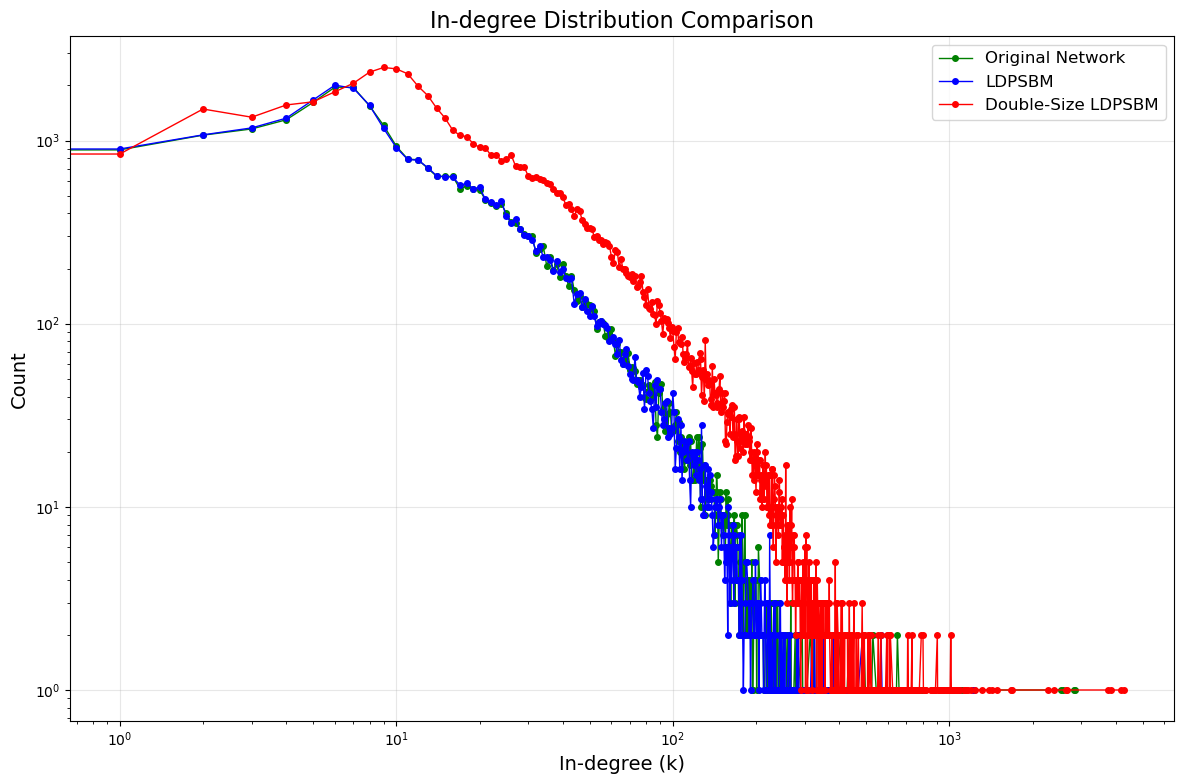

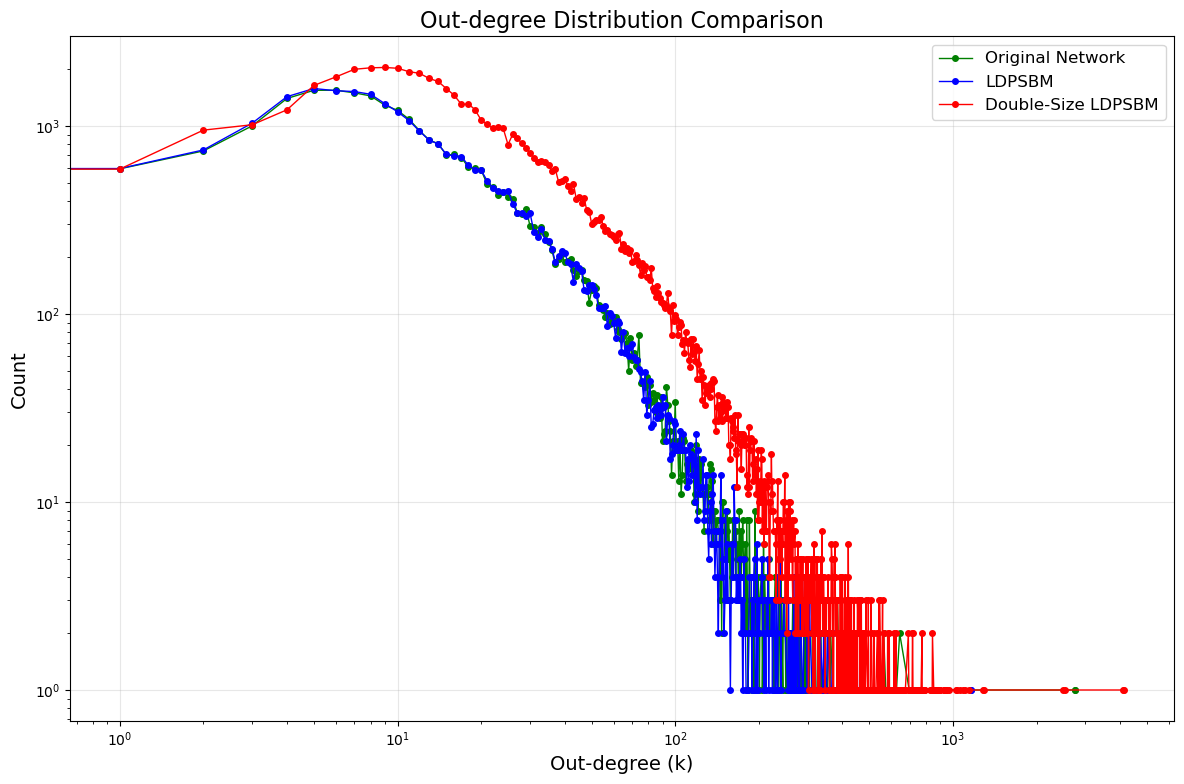

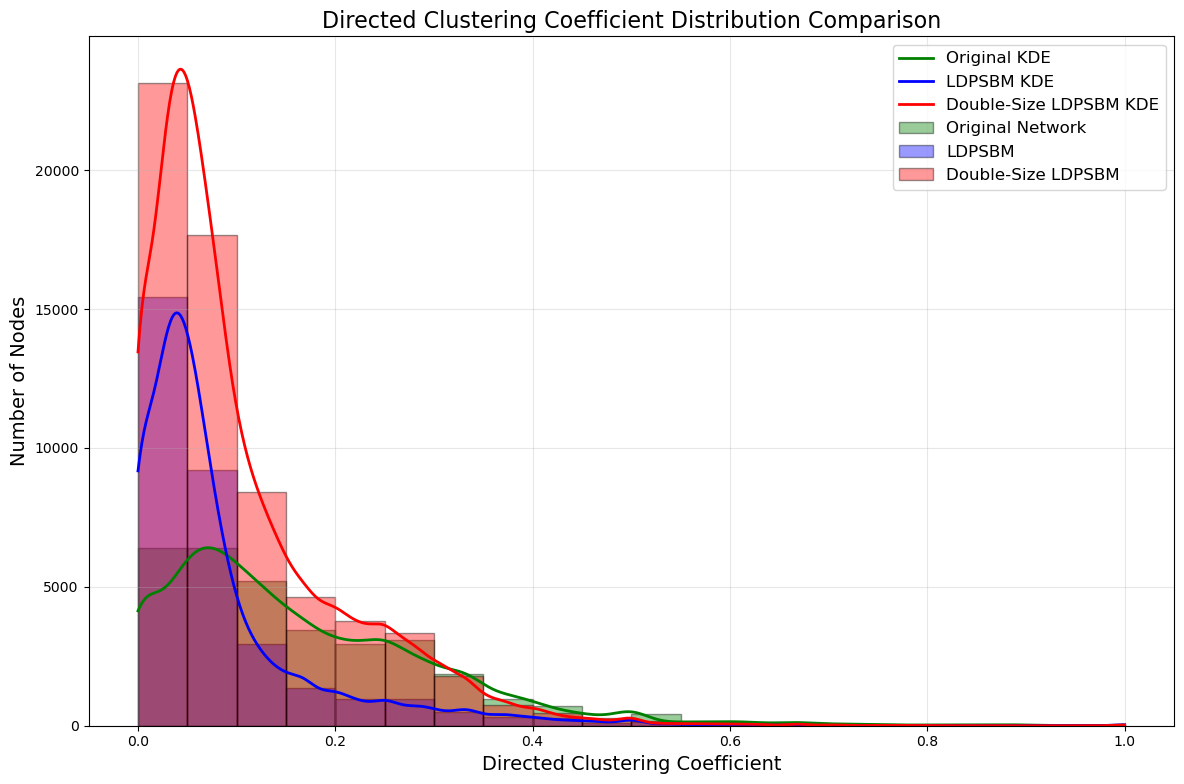

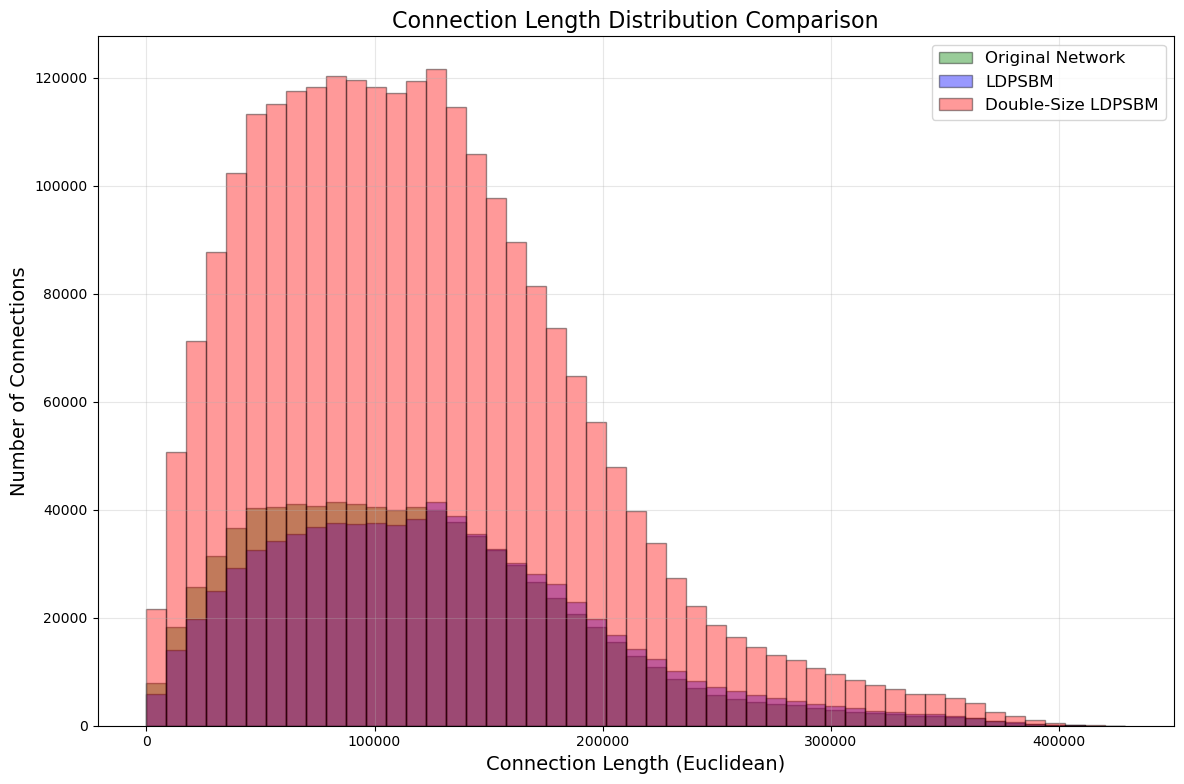

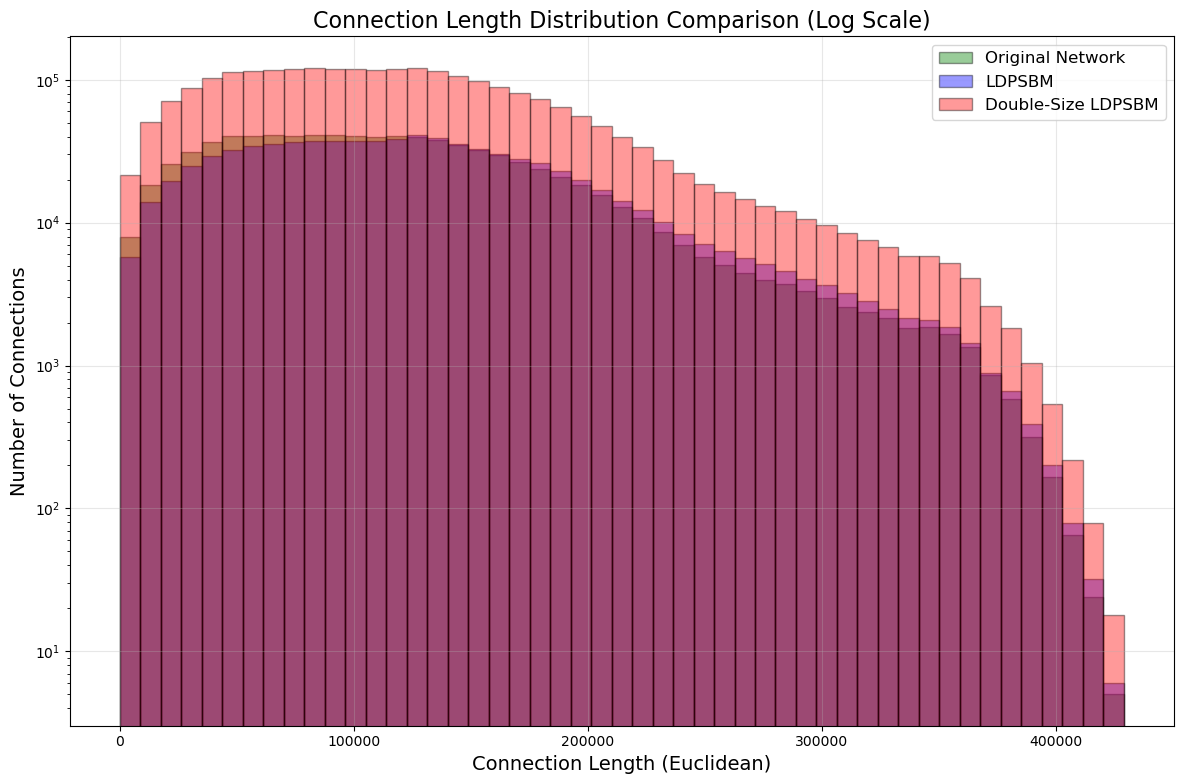

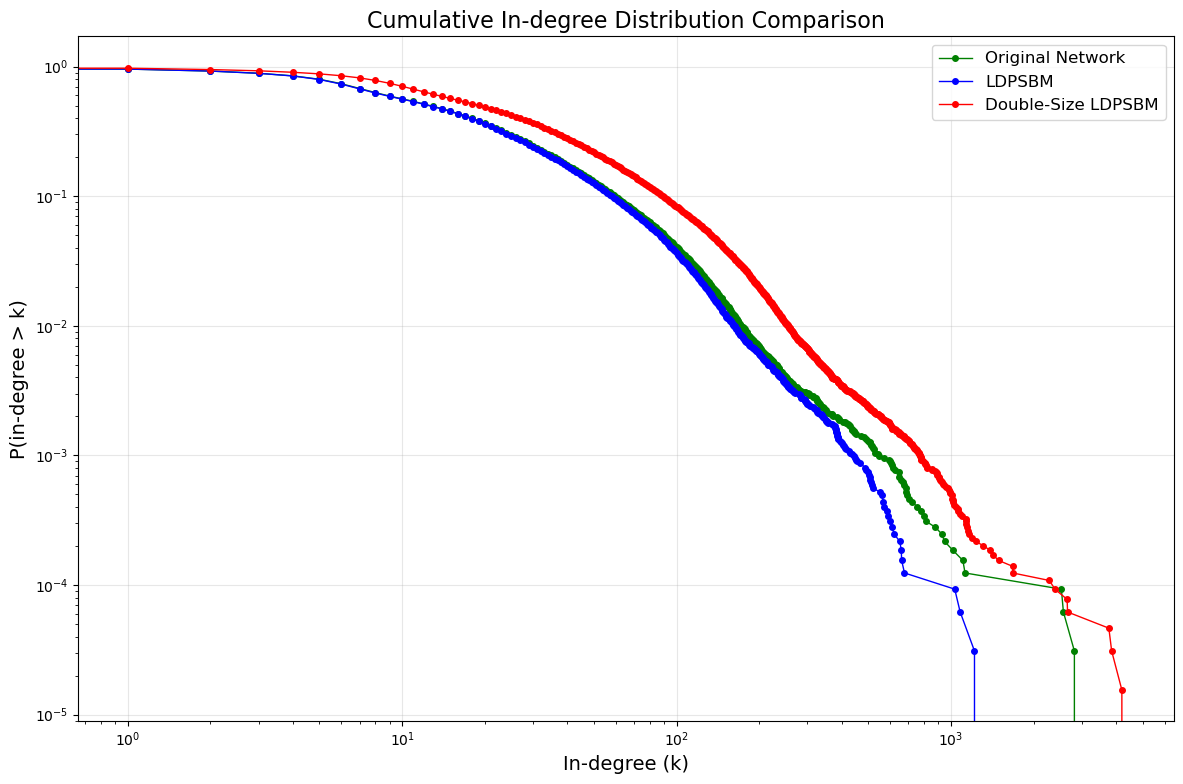

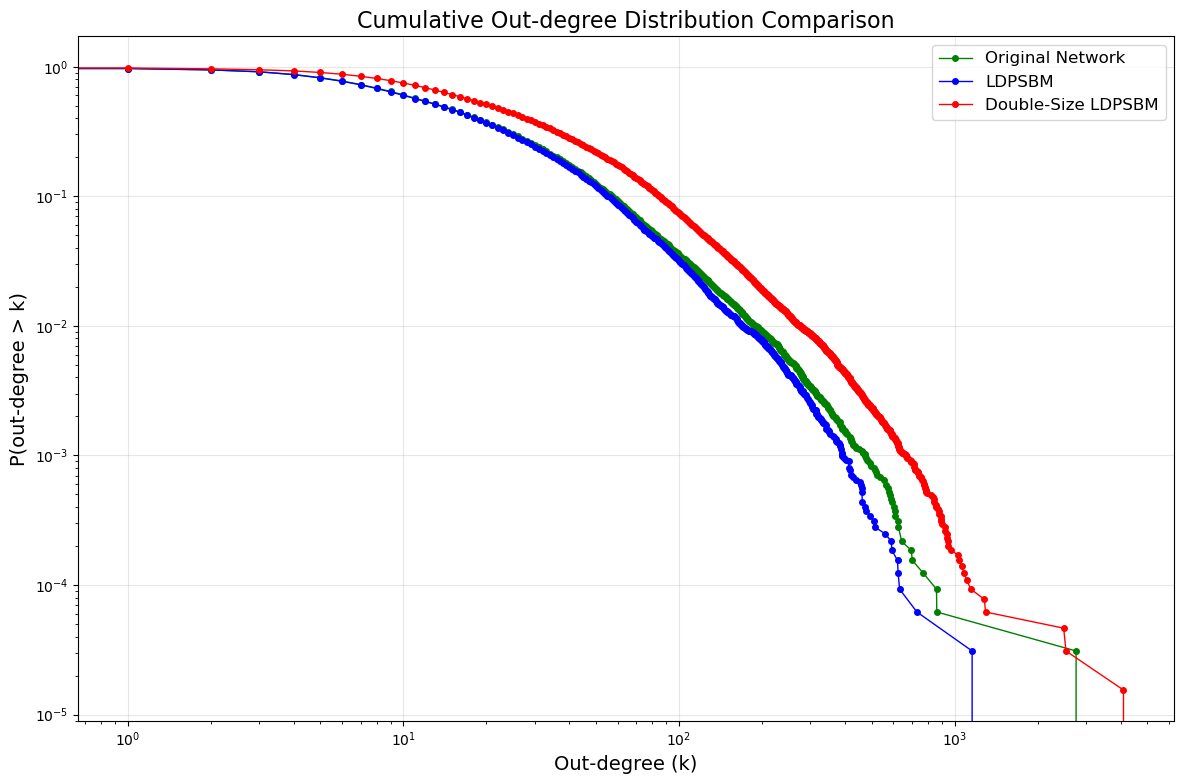

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde, ks_2samp
import time

print("Starting double-size scaling of LDPSBM...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Load original graph data
print("Loading original graph...")
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create original graph
print("Creating original graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

print(f"Identified {sum(len(edges) for edges in intra_module_edges.values())} intra-module edges")
print(f"Identified {len(inter_module_edges)} inter-module edges")

# Create a lightweight degree-preserved SBM
print("Creating lightweight degree-preserved SBM graph...")
ldp_sbm = nx.DiGraph()

# Copy all nodes with their attributes
for node in G.nodes():
    ldp_sbm.add_node(node, **G.nodes[node])

# Preserve inter-module connections as they are 
print("Preserving inter-module connections...")
ldp_sbm.add_edges_from(inter_module_edges)
print(f"Added {len(inter_module_edges)} inter-module edges to SBM")

# For each module, randomize intra-module connections using configuration model
print("Randomizing intra-module connections using configuration model...")

for module, nodes in nodes_by_module.items():
    print(f"Processing module {module} with {len(nodes)} nodes...")
    
    if len(nodes) <= 1:
        print(f"Skipping module {module} - too few nodes")
        continue
    
    # Create subgraph of just this module
    subgraph = G.subgraph(nodes)
    
    # Get in-degree and out-degree sequences within this module
    in_degree_seq = {}
    out_degree_seq = {}
    
    for node in subgraph.nodes():
        # Count only intra-module degrees
        in_degree_seq[node] = sum(1 for pred in subgraph.predecessors(node))
        out_degree_seq[node] = sum(1 for succ in subgraph.successors(node))
    
    # Skip if no edges in this module
    if sum(out_degree_seq.values()) == 0:
        print(f"Skipping module {module} - no internal edges")
        continue
    
    print(f"Module {module}: {sum(out_degree_seq.values())} internal edges")
    
    # Create stubs based on degrees within this module
    out_stubs = []
    for node, degree in out_degree_seq.items():
        out_stubs.extend([node] * degree)
    
    in_stubs = []
    for node, degree in in_degree_seq.items():
        in_stubs.extend([node] * degree)
    
    # Shuffle the stubs
    random.shuffle(out_stubs)
    random.shuffle(in_stubs)
    
    # Match stubs while avoiding self-loops
    module_edges = []
    used_in_stubs = set()
    used_out_stubs = set()
    
    # First pass: try to match without self-loops
    for i, out_node in enumerate(out_stubs):
        for j, in_node in enumerate(in_stubs):
            if j not in used_in_stubs and out_node != in_node:
                module_edges.append((out_node, in_node))
                used_in_stubs.add(j)
                used_out_stubs.add(i)
                break
    
    # Second pass: handle any remaining stubs (might have self-loops)
    remaining_out = [out_stubs[i] for i in range(len(out_stubs)) if i not in used_out_stubs]
    remaining_in = [in_stubs[j] for j in range(len(in_stubs)) if j not in used_in_stubs]
    
    # If counts don't match, there might be a problem with the degree sequences
    if len(remaining_out) != len(remaining_in):
        print(f"Warning: Degree sequences don't match in module {module}. " 
              f"Remaining out: {len(remaining_out)}, Remaining in: {len(remaining_in)}")
        # Use the shorter list to avoid index errors
        remaining_count = min(len(remaining_out), len(remaining_in))
        remaining_out = remaining_out[:remaining_count]
        remaining_in = remaining_in[:remaining_count]
    
    # Add any remaining edges (might include self-loops)
    for out_node, in_node in zip(remaining_out, remaining_in):
        if out_node != in_node:  # Still try to avoid self-loops
            module_edges.append((out_node, in_node))
    
    # Add the randomized intra-module edges to our SBM
    ldp_sbm.add_edges_from(module_edges)
    print(f"Added {len(module_edges)} randomized intra-module edges for module {module}")

print(f"Generated lightweight degree-preserved SBM with {ldp_sbm.number_of_nodes()} nodes and {ldp_sbm.number_of_edges()} edges")

# Create a new double-size LDPSBM
print("Creating double-size LDPSBM...")
double_ldpsbm = nx.DiGraph()

# Function to generate small random displacement
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to double-size graph...")
for node in ldp_sbm.nodes():
    double_ldpsbm.add_node(node, **ldp_sbm.nodes[node])

# Then, duplicate nodes with slight variations to create new nodes
print("Duplicating nodes for double-size graph...")
node_to_duplicate = {}  # Mapping from original node to its duplicate
duplicated_count = 0

# First duplicate all nodes with metadata
for module, nodes in nodes_by_module.items():
    # Calculate how many nodes to duplicate from this module
    target_count = len(nodes)  # We want to duplicate each node once
    
    # Create duplicates with slight spatial variations
    for node in nodes:
        # Generate a new node ID (must be unique)
        new_node = f"dup_{node}"
        
        # Copy attributes with slight spatial variation
        attrs = dict(ldp_sbm.nodes[node])
        if 'x' in attrs and 'y' in attrs and 'z' in attrs:
            # Add small random displacement to coordinates
            displacement = generate_displacement()
            attrs['x'] += displacement[0]
            attrs['y'] += displacement[1]
            attrs['z'] += displacement[2]
        
        # Add the duplicate node
        double_ldpsbm.add_node(new_node, **attrs)
        node_to_duplicate[node] = new_node
        duplicated_count += 1

print(f"Duplicated {duplicated_count} nodes")
print(f"Double-size graph has {double_ldpsbm.number_of_nodes()} nodes")

# Add all edges from the original LDPSBM
print("Adding original edges to double-size graph...")
double_ldpsbm.add_edges_from(ldp_sbm.edges())

# Add edges to connect duplicate nodes, following similar patterns
print("Adding edges between duplicate nodes...")
added_edges = 0

# Function to create edges between duplicates based on original edges
def duplicate_edges(module_edges, node_to_duplicate):
    duplicate_edges = []
    
    # For each original edge, create edges between duplicate nodes
    for u, v in module_edges:
        if u in node_to_duplicate and v in node_to_duplicate:
            # Original -> Original (already added)
            # Duplicate -> Duplicate (similar to original pattern)
            duplicate_edges.append((node_to_duplicate[u], node_to_duplicate[v]))
            
            # Occasionally add cross connections for diversity
            if random.random() < 0.5:
                # Original -> Duplicate
                duplicate_edges.append((u, node_to_duplicate[v]))
            
            if random.random() < 0.5:
                # Duplicate -> Original
                duplicate_edges.append((node_to_duplicate[u], v))
    
    return duplicate_edges

# Duplicate intra-module edges
for module, edges in intra_module_edges.items():
    new_edges = duplicate_edges(edges, node_to_duplicate)
    double_ldpsbm.add_edges_from(new_edges)
    added_edges += len(new_edges)
    if len(new_edges) > 0:
        print(f"Added {len(new_edges)} duplicate intra-module edges for module {module}")

# Duplicate inter-module edges
new_inter_edges = duplicate_edges(inter_module_edges, node_to_duplicate)
double_ldpsbm.add_edges_from(new_inter_edges)
added_edges += len(new_inter_edges)
print(f"Added {len(new_inter_edges)} duplicate inter-module edges")

print(f"Added a total of {added_edges} duplicate edges")
print(f"Double-size LDPSBM: {double_ldpsbm.number_of_nodes()} nodes, {double_ldpsbm.number_of_edges()} edges")

# Calculate degree distributions for comparison
print("Calculating degree distributions for comparison...")
original_in_degrees = list(dict(G.in_degree()).values())
original_out_degrees = list(dict(G.out_degree()).values())
ldpsbm_in_degrees = list(dict(ldp_sbm.in_degree()).values())
ldpsbm_out_degrees = list(dict(ldp_sbm.out_degree()).values())
double_in_degrees = list(dict(double_ldpsbm.in_degree()).values())
double_out_degrees = list(dict(double_ldpsbm.out_degree()).values())

# Plot in-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

# Calculate directed clustering coefficients for all three networks
print("Calculating directed clustering coefficients...")

def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

original_clustering = directed_clustering_coefficient(G)
ldpsbm_clustering = directed_clustering_coefficient(ldp_sbm)
double_clustering = directed_clustering_coefficient(double_ldpsbm)

print(f"Original network average directed clustering coefficient: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"LDPSBM network average directed clustering coefficient: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"Double-size LDPSBM average directed clustering coefficient: {sum(double_clustering.values())/len(double_clustering):.4f}")

# Plot clustering coefficient distributions for all three networks
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

plt.hist(list(original_clustering.values()), bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(list(ldpsbm_clustering.values()), bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(list(double_clustering.values()), bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size LDPSBM')

# Add kernel density estimation
kde_original = gaussian_kde(list(original_clustering.values()))
kde_ldpsbm = gaussian_kde(list(ldpsbm_clustering.values()))
kde_double = gaussian_kde(list(double_clustering.values()))
x_vals = np.linspace(0, 1, 1000)

plt.plot(x_vals, kde_original(x_vals) * len(original_clustering) * (bins[1] - bins[0]), 
         'g-', linewidth=2, label='Original KDE')
plt.plot(x_vals, kde_ldpsbm(x_vals) * len(ldpsbm_clustering) * (bins[1] - bins[0]), 
         'b-', linewidth=2, label='LDPSBM KDE')
plt.plot(x_vals, kde_double(x_vals) * len(double_clustering) * (bins[1] - bins[0]), 
         'r-', linewidth=2, label='Double-Size LDPSBM KDE')

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot at 600dpi")

# Calculate connection length distributions for all three networks
print("Calculating connection length distributions...")

def calculate_euclidean_distance(graph, edge):
    u, v = edge
    u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
    v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
    return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))

# Calculate distances for all three networks
print("Calculating distances for all networks...")
original_distances = []
for edge in G.edges():
    try:
        distance = calculate_euclidean_distance(G, edge)
        original_distances.append(distance)
    except KeyError:
        continue

ldpsbm_distances = []
for edge in ldp_sbm.edges():
    try:
        distance = calculate_euclidean_distance(ldp_sbm, edge)
        ldpsbm_distances.append(distance)
    except KeyError:
        continue

double_distances = []
for edge in double_ldpsbm.edges():
    try:
        distance = calculate_euclidean_distance(double_ldpsbm, edge)
        double_distances.append(distance)
    except KeyError:
        continue

print(f"Original network average connection length: {np.mean(original_distances):.4f}")
print(f"LDPSBM network average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"Double-size LDPSBM average connection length: {np.mean(double_distances):.4f}")

# Plot connection length distributions for all three networks
plt.figure(figsize=(12, 8))
max_distance = max(np.max(original_distances), np.max(ldpsbm_distances), np.max(double_distances))
bins = np.linspace(0, max_distance, 50)

plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution.png', dpi=600)
print("Saved connection length distribution comparison plot at 600dpi")

# Plot connection length distributions with log scale on y-axis
plt.figure(figsize=(12, 8))
plt.hist(original_distances, bins=bins, alpha=0.4, color='green', 
         edgecolor='black', label='Original Network')
plt.hist(ldpsbm_distances, bins=bins, alpha=0.4, color='blue', 
         edgecolor='black', label='LDPSBM')
plt.hist(double_distances, bins=bins, alpha=0.4, color='red', 
         edgecolor='black', label='Double-Size LDPSBM')

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_distribution_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot at 600dpi")

# Compute cumulative distributions for degree (for all three networks)
print("Computing cumulative degree distributions...")

# For in-degrees
original_in_degree_counts = Counter(original_in_degrees)
ldpsbm_in_degree_counts = Counter(ldpsbm_in_degrees)
double_in_degree_counts = Counter(double_in_degrees)

# Sort degrees
sorted_original_in = sorted(original_in_degree_counts.items())
sorted_ldpsbm_in = sorted(ldpsbm_in_degree_counts.items())
sorted_double_in = sorted(double_in_degree_counts.items())

# Calculate cumulative distributions
total_original_nodes = G.number_of_nodes()
total_ldpsbm_nodes = ldp_sbm.number_of_nodes()
total_double_nodes = double_ldpsbm.number_of_nodes()

# For original network in-degrees
x_orig_in = [k for k, _ in sorted_original_in]
y_orig_in = []
count_so_far = 0
for _, count in sorted_original_in:
    count_so_far += count
    y_orig_in.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM in-degrees
x_ldpsbm_in = [k for k, _ in sorted_ldpsbm_in]
y_ldpsbm_in = []
count_so_far = 0
for _, count in sorted_ldpsbm_in:
    count_so_far += count
    y_ldpsbm_in.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Double-Size LDPSBM in-degrees
x_double_in = [k for k, _ in sorted_double_in]
y_double_in = []
count_so_far = 0
for _, count in sorted_double_in:
    count_so_far += count
    y_double_in.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# Plot cumulative in-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_in, y_orig_in, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_in, y_ldpsbm_in, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_double_in, y_double_in, 'ro-', markersize=4, linewidth=1, label='Double-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot at 600dpi")

# For out-degrees
original_out_degree_counts = Counter(original_out_degrees)
ldpsbm_out_degree_counts = Counter(ldpsbm_out_degrees)
double_out_degree_counts = Counter(double_out_degrees)

# Sort degrees
sorted_original_out = sorted(original_out_degree_counts.items())
sorted_ldpsbm_out = sorted(ldpsbm_out_degree_counts.items())
sorted_double_out = sorted(double_out_degree_counts.items())

# For original network out-degrees
x_orig_out = [k for k, _ in sorted_original_out]
y_orig_out = []
count_so_far = 0
for _, count in sorted_original_out:
    count_so_far += count
    y_orig_out.append(1 - count_so_far / total_original_nodes)  # P(degree > k)

# For LDPSBM out-degrees
x_ldpsbm_out = [k for k, _ in sorted_ldpsbm_out]
y_ldpsbm_out = []
count_so_far = 0
for _, count in sorted_ldpsbm_out:
    count_so_far += count
    y_ldpsbm_out.append(1 - count_so_far / total_ldpsbm_nodes)  # P(degree > k)

# For Double-Size LDPSBM out-degrees
x_double_out = [k for k, _ in sorted_double_out]
y_double_out = []
count_so_far = 0
for _, count in sorted_double_out:
    count_so_far += count
    y_double_out.append(1 - count_so_far / total_double_nodes)  # P(degree > k)

# Plot cumulative out-degree distribution for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(x_orig_out, y_orig_out, 'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(x_ldpsbm_out, y_ldpsbm_out, 'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(x_double_out, y_double_out, 'ro-', markersize=4, linewidth=1, label='Double-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot at 600dpi")

# Perform KS tests to compare distributions
print("Performing KS tests for distribution comparisons...")
print("This may take some time for large networks...")

# Compare original vs LDPSBM
ks_original_ldpsbm_in = ks_2samp(original_in_degrees, ldpsbm_in_degrees)
ks_original_ldpsbm_out = ks_2samp(original_out_degrees, ldpsbm_out_degrees)
ks_original_ldpsbm_clustering = ks_2samp(list(original_clustering.values()), list(ldpsbm_clustering.values()))
ks_original_ldpsbm_distances = ks_2samp(original_distances, ldpsbm_distances)

# Compare LDPSBM vs double-size LDPSBM
ks_ldpsbm_double_in = ks_2samp(ldpsbm_in_degrees, double_in_degrees)
ks_ldpsbm_double_out = ks_2samp(ldpsbm_out_degrees, double_out_degrees)
ks_ldpsbm_double_clustering = ks_2samp(list(ldpsbm_clustering.values()), list(double_clustering.values()))
ks_ldpsbm_double_distances = ks_2samp(ldpsbm_distances, double_distances)

# Compare original vs double-size LDPSBM
ks_original_double_in = ks_2samp(original_in_degrees, double_in_degrees)
ks_original_double_out = ks_2samp(original_out_degrees, double_out_degrees)
ks_original_double_clustering = ks_2samp(list(original_clustering.values()), list(double_clustering.values()))
ks_original_double_distances = ks_2samp(original_distances, double_distances)

print("\nDistribution Comparison (KS Tests):")
print("Original vs LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_ldpsbm_in.statistic:.4f}, p-value={ks_original_ldpsbm_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_ldpsbm_out.statistic:.4f}, p-value={ks_original_ldpsbm_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_ldpsbm_clustering.statistic:.4f}, p-value={ks_original_ldpsbm_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_ldpsbm_distances.statistic:.4f}, p-value={ks_original_ldpsbm_distances.pvalue:.4f}")

print("\nLDPSBM vs Double-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_ldpsbm_double_in.statistic:.4f}, p-value={ks_ldpsbm_double_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_ldpsbm_double_out.statistic:.4f}, p-value={ks_ldpsbm_double_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_ldpsbm_double_clustering.statistic:.4f}, p-value={ks_ldpsbm_double_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_ldpsbm_double_distances.statistic:.4f}, p-value={ks_ldpsbm_double_distances.pvalue:.4f}")

print("\nOriginal vs Double-Size LDPSBM:")
print(f"  In-degree distributions: statistic={ks_original_double_in.statistic:.4f}, p-value={ks_original_double_in.pvalue:.4f}")
print(f"  Out-degree distributions: statistic={ks_original_double_out.statistic:.4f}, p-value={ks_original_double_out.pvalue:.4f}")
print(f"  Clustering coefficient distributions: statistic={ks_original_double_clustering.statistic:.4f}, p-value={ks_original_double_clustering.pvalue:.4f}")
print(f"  Connection length distributions: statistic={ks_original_double_distances.statistic:.4f}, p-value={ks_original_double_distances.pvalue:.4f}")

# Generate final comparison metrics
print("\nFinal Comparison Summary:")
print("Network sizes:")
print(f"  Original: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  LDPSBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"  Double-size LDPSBM: {double_ldpsbm.number_of_nodes()} nodes, {double_ldpsbm.number_of_edges()} edges")
print(f"Node expansion ratio (double/original): {double_ldpsbm.number_of_nodes() / G.number_of_nodes():.4f}")
print(f"Node expansion ratio (double/LDPSBM): {double_ldpsbm.number_of_nodes() / ldp_sbm.number_of_nodes():.4f}")
print(f"Edge expansion ratio (double/original): {double_ldpsbm.number_of_edges() / G.number_of_edges():.4f}")
print(f"Edge expansion ratio (double/LDPSBM): {double_ldpsbm.number_of_edges() / ldp_sbm.number_of_edges():.4f}")

# Calculate density for all three networks
original_density = G.number_of_edges() / (G.number_of_nodes() * (G.number_of_nodes() - 1))
ldpsbm_density = ldp_sbm.number_of_edges() / (ldp_sbm.number_of_nodes() * (ldp_sbm.number_of_nodes() - 1))
double_density = double_ldpsbm.number_of_edges() / (double_ldpsbm.number_of_nodes() * (double_ldpsbm.number_of_nodes() - 1))

print("\nNetwork densities:")
print(f"  Original density: {original_density:.8f}")
print(f"  LDPSBM density: {ldpsbm_density:.8f}")
print(f"  Double-size LDPSBM density: {double_density:.8f}")
print(f"  Density ratio (double/original): {double_density / original_density:.4f}")
print(f"  Density ratio (double/LDPSBM): {double_density / ldpsbm_density:.4f}")

print("\nClustering coefficients:")
print(f"  Original average directed clustering: {sum(original_clustering.values())/len(original_clustering):.4f}")
print(f"  LDPSBM average directed clustering: {sum(ldpsbm_clustering.values())/len(ldpsbm_clustering):.4f}")
print(f"  Double-size LDPSBM average directed clustering: {sum(double_clustering.values())/len(double_clustering):.4f}")

print("\nConnection lengths:")
print(f"  Original average connection length: {np.mean(original_distances):.4f}")
print(f"  LDPSBM average connection length: {np.mean(ldpsbm_distances):.4f}")
print(f"  Double-size LDPSBM average connection length: {np.mean(double_distances):.4f}")
print(f"  Connection length ratio (double/original): {np.mean(double_distances) / np.mean(original_distances):.4f}")
print(f"  Connection length ratio (double/LDPSBM): {np.mean(double_distances) / np.mean(ldpsbm_distances):.4f}")

# Save the double-size LDPSBM graph to files for future use
print("Saving double-size LDPSBM data...")
double_edges = list(double_ldpsbm.edges())
double_edges_df = pd.DataFrame(double_edges, columns=['from', 'to'])
double_edges_df.to_csv('double_size_ldpsbm_edges.csv', index=False)

# Save node metadata
double_nodes = list(double_ldpsbm.nodes(data=True))
double_metadata = []
for node, data in double_nodes:
    double_metadata.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
double_metadata_df = pd.DataFrame(double_metadata)
double_metadata_df.to_csv('double_size_ldpsbm_metadata.csv', index=False)

print("Double-size LDPSBM data saved to files")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
print(f"  Out-degree distributions: statistic={ks_original_ldpsbm_out.statistic:.4f}, p-value={ks_original_ldpsbm_out.pvalue}")

Saved in-degree distribution comparison plot at 600dpi
Saved out-degree distribution comparison plot at 600dpi


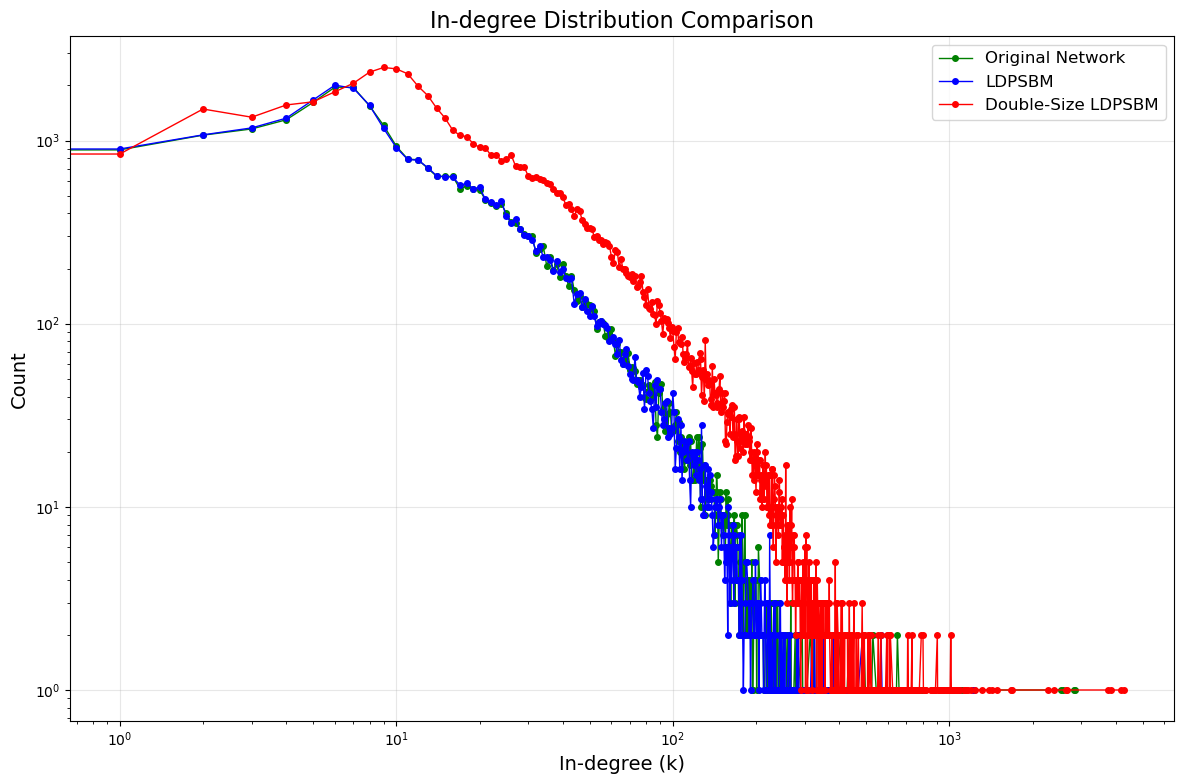

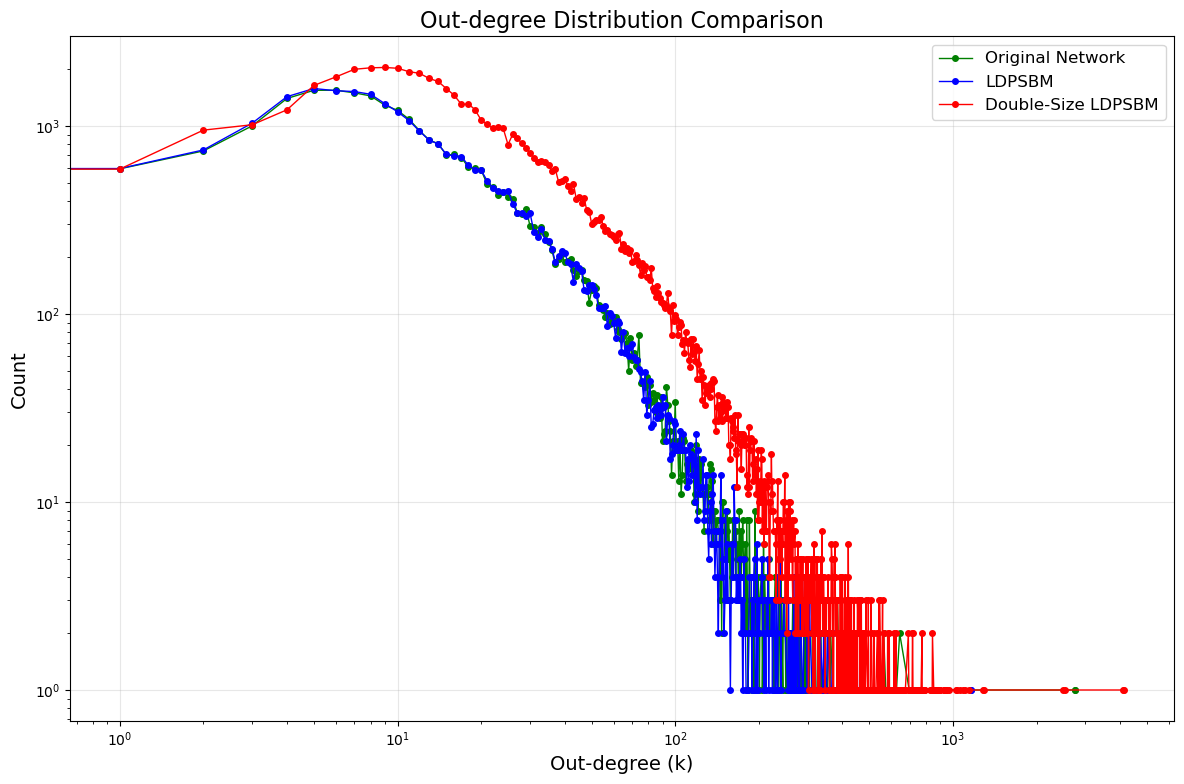

In [7]:
# Plot in-degree distribution comparison for all three networks
plt.figure(figsize=(12, 8))
plt.loglog(sorted(Counter(original_in_degrees).keys()), 
           [Counter(original_in_degrees)[k] for k in sorted(Counter(original_in_degrees).keys())], 
           'go-', markersize=4, linewidth=1, label='Original Network')
plt.loglog(sorted(Counter(ldpsbm_in_degrees).keys()), 
           [Counter(ldpsbm_in_degrees)[k] for k in sorted(Counter(ldpsbm_in_degrees).keys())], 
           'bo-', markersize=4, linewidth=1, label='LDPSBM')
plt.loglog(sorted(Counter(double_in_degrees).keys()), 
           [Counter(double_in_degrees)[k] for k in sorted(Counter(double_in_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Double-Size LDPSBM')
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot at 600dpi")

# Plot out-degree distribution comparison for all three networks
plt.figure(figsize=(4, 3))
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           '.', markersize=4, linewidth=1, label='Original',color='black')
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           '-, markersize=4, linewidth=1, label='SBM + Configuration')
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           '.', markersize=4, linewidth=1, label='SBM + COnfiguration, Double Brain Size')
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot at 600dpi")

NameError: name 'half_out_degrees' is not defined

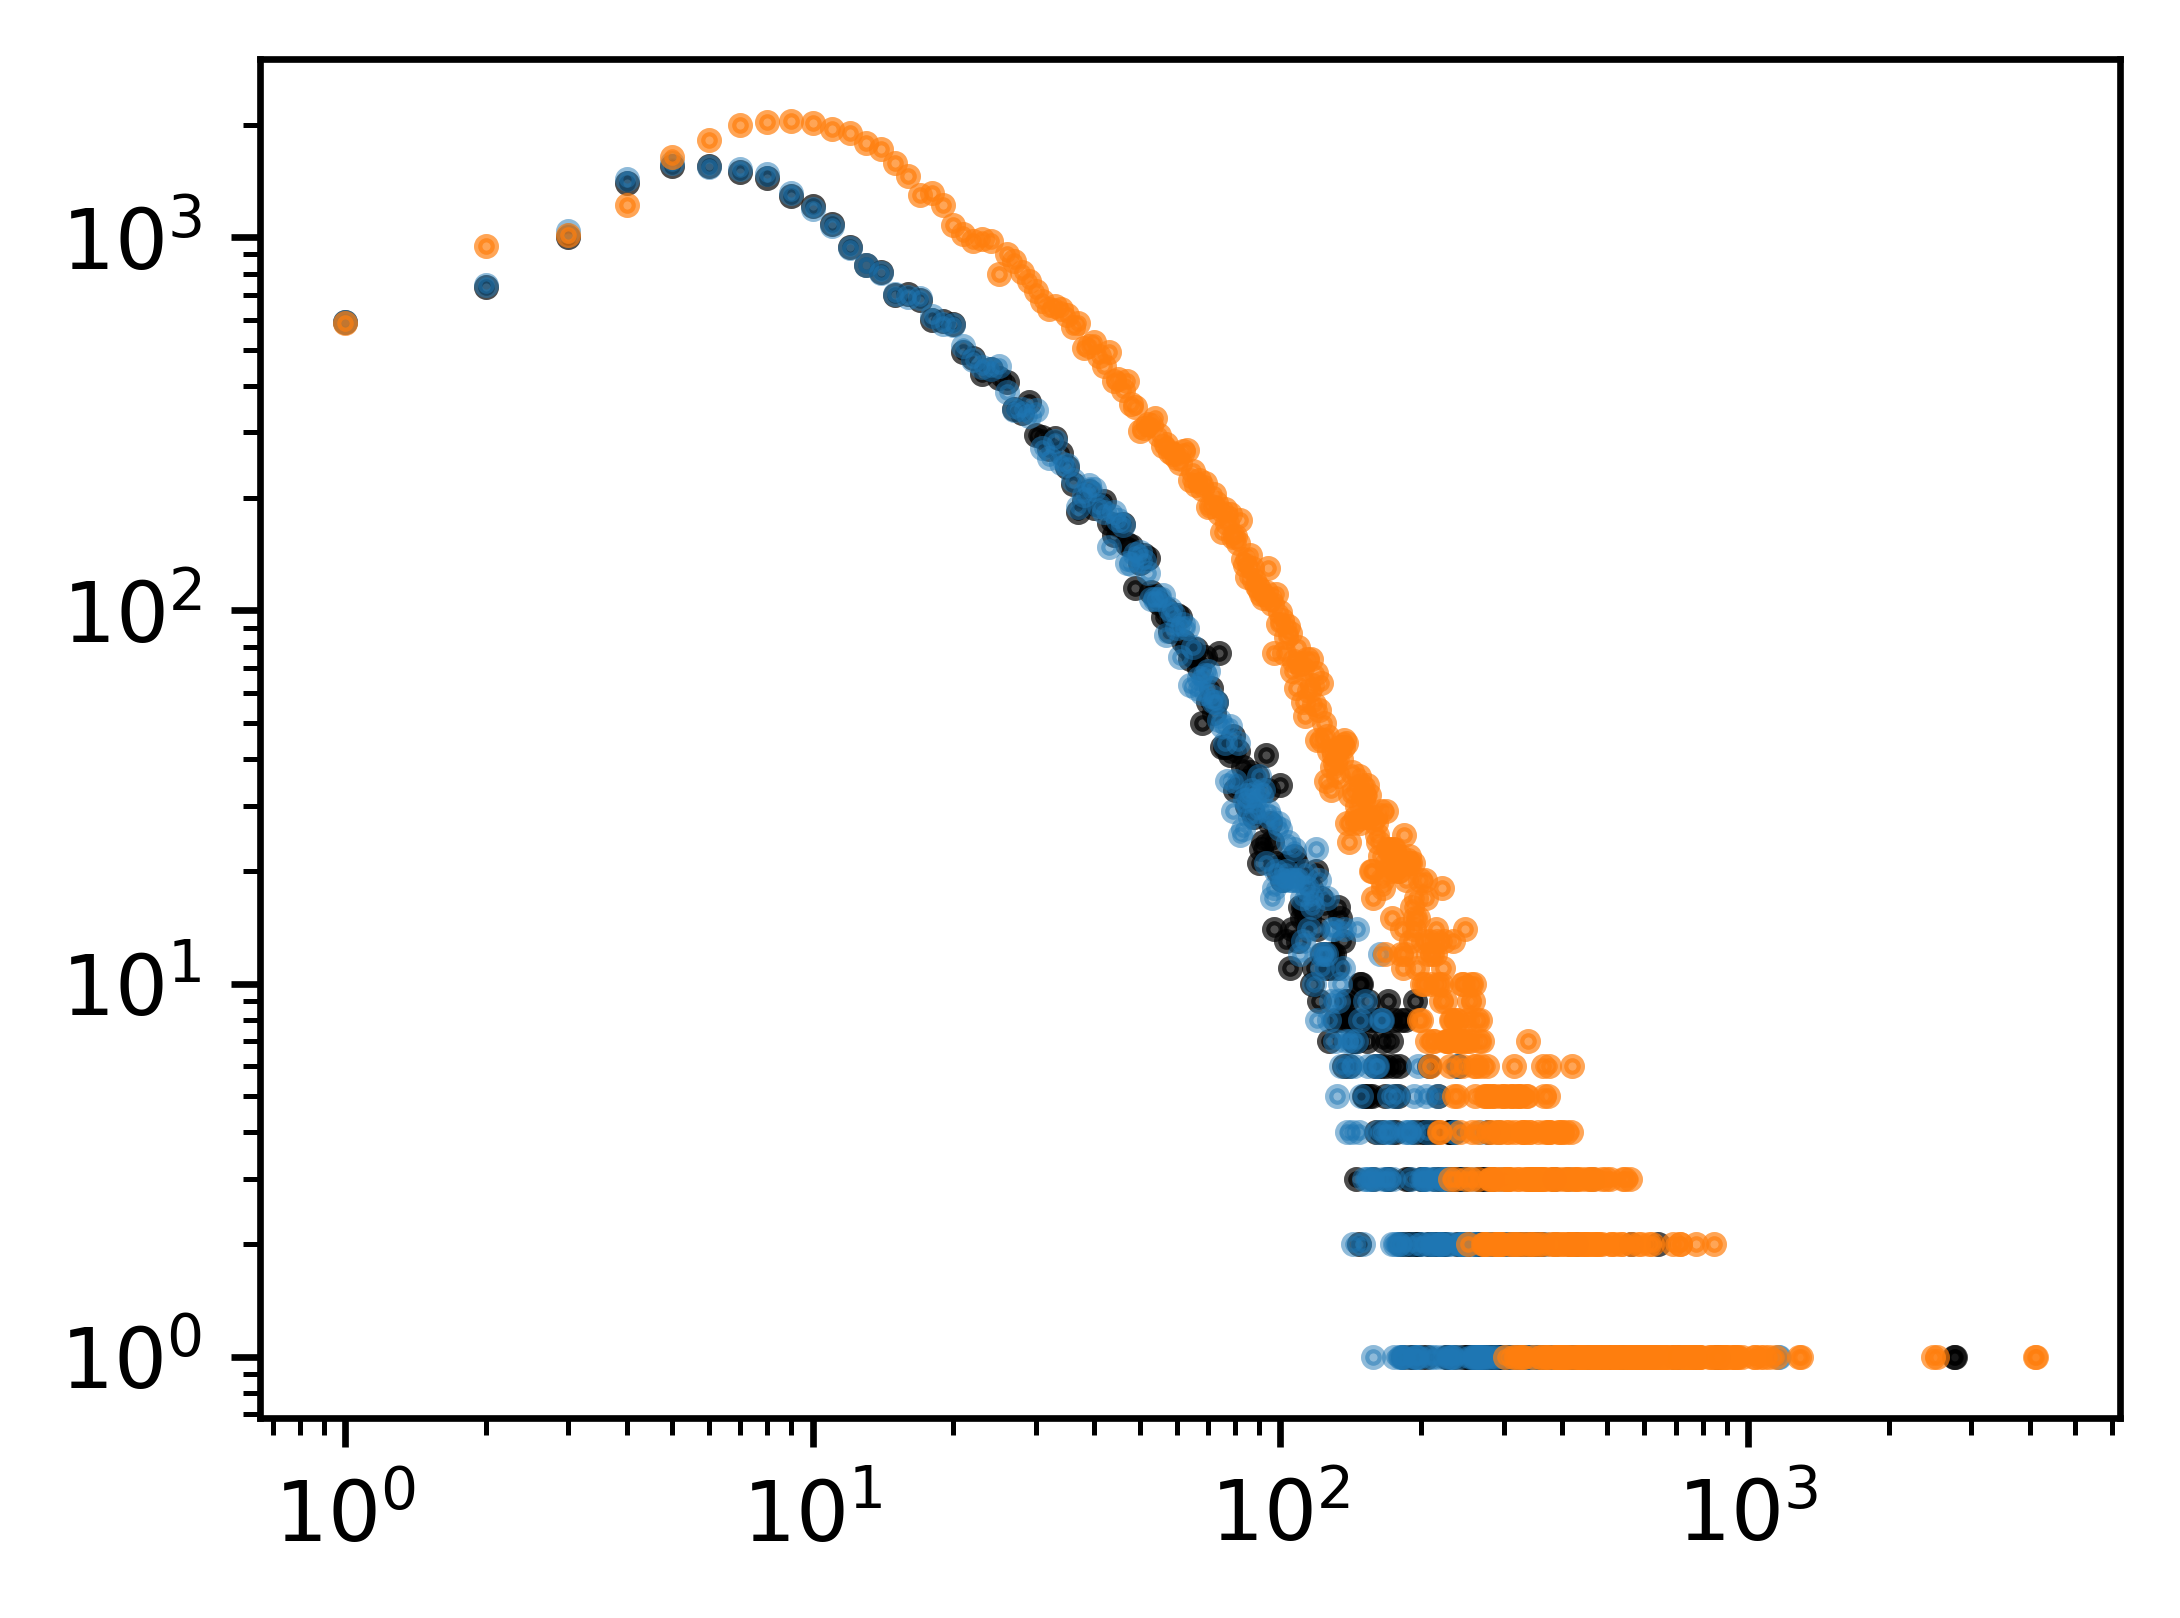

In [29]:
# Plot out-degree distribution comparison for all three networks
plt.figure(figsize=(4, 3),dpi=600)
plt.loglog(sorted(Counter(original_out_degrees).keys()), 
           [Counter(original_out_degrees)[k] for k in sorted(Counter(original_out_degrees).keys())], 
           '.', markersize=4, linewidth=1, label='Original',color='black',alpha=0.7)
plt.loglog(sorted(Counter(ldpsbm_out_degrees).keys()), 
           [Counter(ldpsbm_out_degrees)[k] for k in sorted(Counter(ldpsbm_out_degrees).keys())], 
           '.', markersize=4, linewidth=1, label='SBM + Configuration',alpha=0.5)
plt.loglog(sorted(Counter(double_out_degrees).keys()), 
           [Counter(double_out_degrees)[k] for k in sorted(Counter(double_out_degrees).keys())], 
           '.', markersize=4, linewidth=1, label='SBM + Configuration, (2x)',alpha=0.7)
plt.loglog(sorted(Counter(half_out_degrees).keys()), 
           [Counter(half_out_degrees)[k] for k in sorted(Counter(half_out_degrees).keys())], 
           'ro-', markersize=4, linewidth=1, label='Half-Size LDPSBM')

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.pdf')
print("Saved out-degree distribution comparison plot at 600dpi")

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import time
import random

# Load half size graph data
print("Loading half size graph...")
print("Reading CSV files...")
edges_df = pd.read_csv("half_size_ldpsbm.csv")
metadata_df = pd.read_csv("half_size_ldpsbm_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create directed graph
print("Creating directed graph...")
half = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    half.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

print(f"Added {half.number_of_nodes()} nodes to 1/2")

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    half.add_edge(edge['from'], edge['to'])

print(f"Added {half.number_of_edges()} edges to the graph")




Loading half size graph...
Reading CSV files...


NameError: name 'pd' is not defined

Starting network comparison analysis...
Loading original network data...
Loaded 849981 edges and 32272 nodes for original network
Creating original graph...
Original graph: 32272 nodes, 849981 edges
Loading normal size model data...
Loaded 812313 edges and 32272 nodes for normal size model
Creating normal size graph...
Normal size graph: 32272 nodes, 812313 edges
Loading half size model data...
Loaded 201983 edges and 16123 nodes for half size model
Creating half size graph...
Half size graph: 16123 nodes, 201983 edges
Loading double size model data...


/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


Loaded 2513640 edges and 64544 nodes for double size model
Creating double size graph...
Double size graph: 91674 nodes, 2513640 edges
Successfully loaded 4 graphs for comparison
Plotting in-degree distributions...
Saved in-degree distribution comparison plot
Plotting out-degree distributions...
Saved out-degree distribution comparison plot
Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot
Plotting cumulative out-degree distributions...
Saved cumulative out-degree distribution comparison plot
Calculating clustering coefficients...
Calculating clustering for Original network...
Sampled 1000 nodes for clustering calculation
Original network average clustering: 0.0420
Calculating clustering for Normal Size network...
Sampled 1000 nodes for clustering calculation
Normal Size network average clustering: 0.0209
Calculating clustering for Half Size network...
Sampled 1000 nodes for clustering calculation
Half Size network average clustering

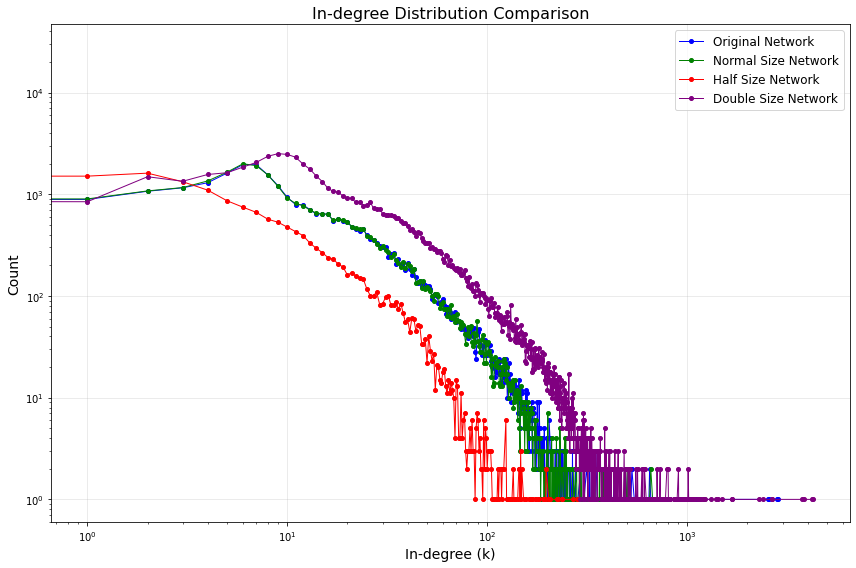

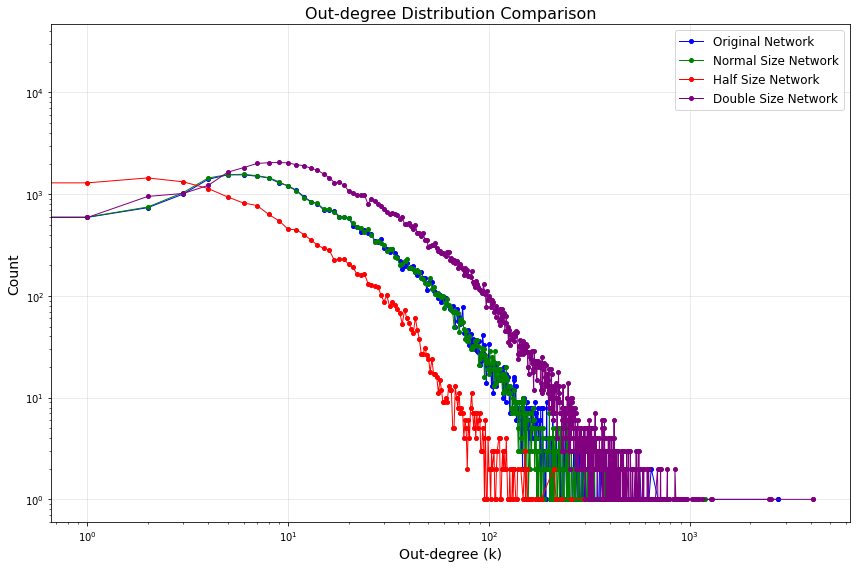

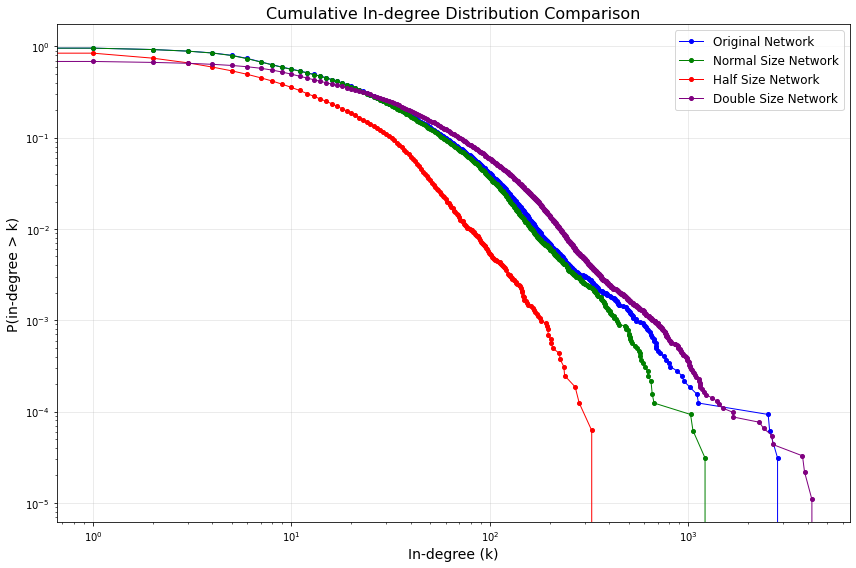

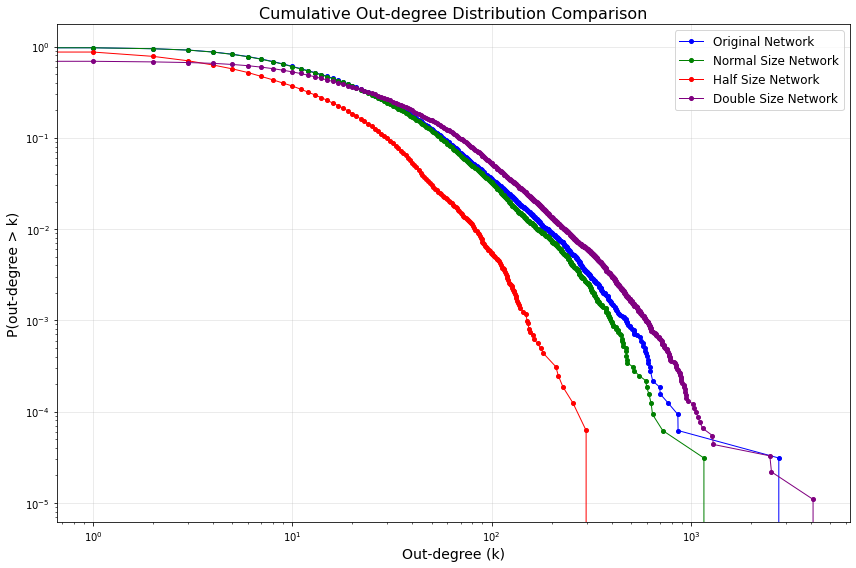

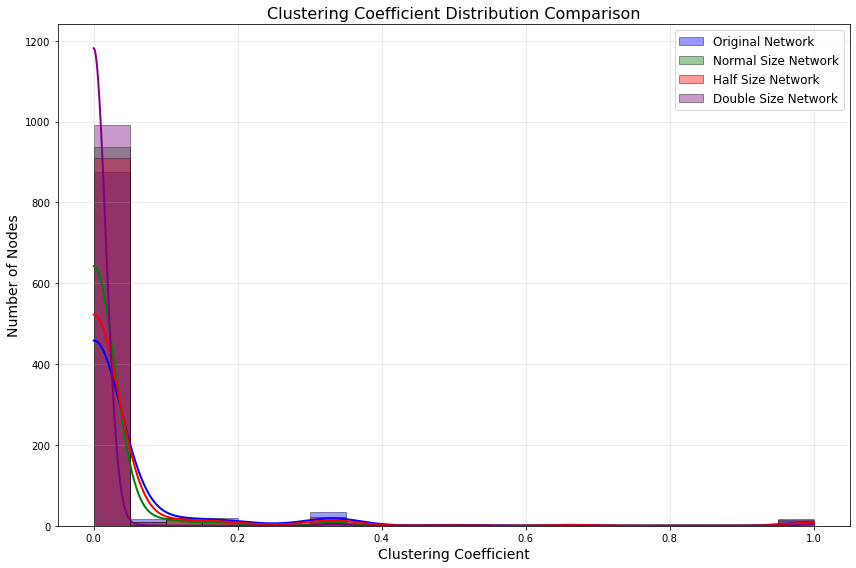

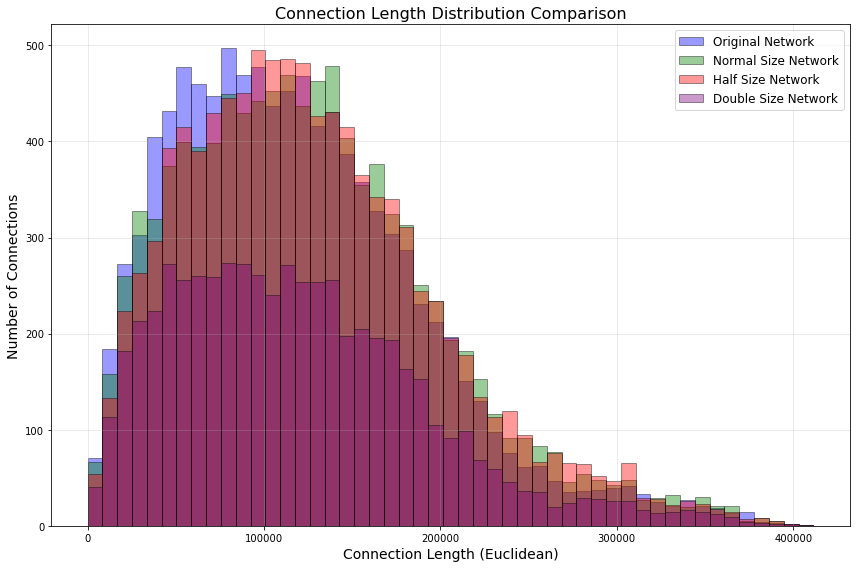

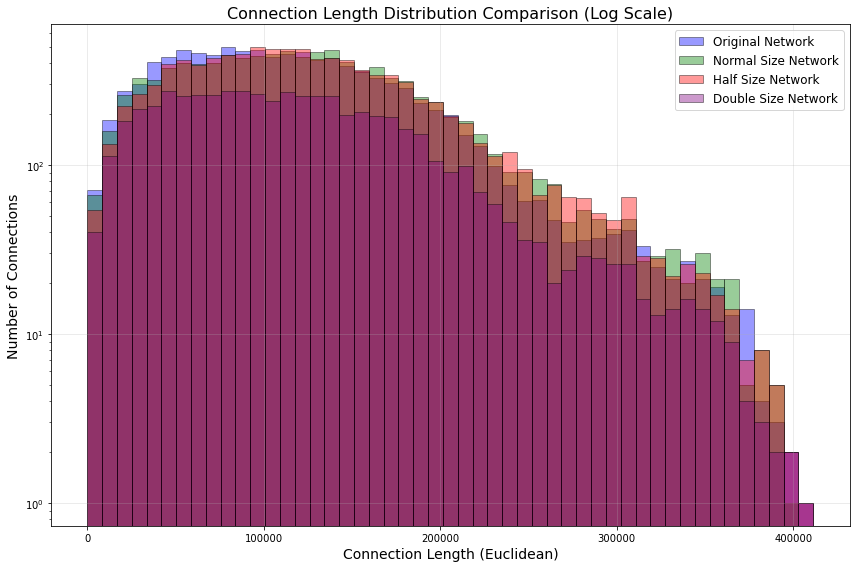

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde

print("Starting network comparison analysis...")

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Function to calculate Euclidean distance
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Load original network data
print("Loading original network data...")
try:
    edges_df = pd.read_csv("fly_edges.csv")
    metadata_df = pd.read_csv("fly_metadata.csv")
    print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes for original network")
    
    # Create original graph
    print("Creating original graph...")
    G_original = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in metadata_df.iterrows():
        node_id = node_data['node_id']
        G_original.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in edges_df.iterrows():
        G_original.add_edge(edge['from'], edge['to'])
    
    print(f"Original graph: {G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading original network: {e}")
    G_original = None

# Load normal size model
print("Loading normal size model data...")
try:
    normal_edges_df = pd.read_csv("normal_size_ldpsbm_edges.csv")
    normal_metadata_df = pd.read_csv("normal_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(normal_edges_df)} edges and {len(normal_metadata_df)} nodes for normal size model")
    
    # Create normal size graph
    print("Creating normal size graph...")
    G_normal = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in normal_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_normal.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in normal_edges_df.iterrows():
        G_normal.add_edge(edge['from'], edge['to'])
    
    print(f"Normal size graph: {G_normal.number_of_nodes()} nodes, {G_normal.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading normal size model: {e}")
    G_normal = None

# Load half size model
print("Loading half size model data...")
try:
    half_edges_df = pd.read_csv("half_size_ldpsbm_edges.csv")
    half_metadata_df = pd.read_csv("half_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(half_edges_df)} edges and {len(half_metadata_df)} nodes for half size model")
    
    # Create half size graph
    print("Creating half size graph...")
    G_half = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in half_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_half.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in half_edges_df.iterrows():
        G_half.add_edge(edge['from'], edge['to'])
    
    print(f"Half size graph: {G_half.number_of_nodes()} nodes, {G_half.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading half size model: {e}")
    G_half = None

# Load double size model
print("Loading double size model data...")
try:
    double_edges_df = pd.read_csv("double_size_ldpsbm_edges.csv")
    double_metadata_df = pd.read_csv("double_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(double_edges_df)} edges and {len(double_metadata_df)} nodes for double size model")
    
    # Create double size graph
    print("Creating double size graph...")
    G_double = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in double_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_double.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in double_edges_df.iterrows():
        G_double.add_edge(edge['from'], edge['to'])
    
    print(f"Double size graph: {G_double.number_of_nodes()} nodes, {G_double.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading double size model: {e}")
    G_double = None

# Create a list of valid graphs and their labels
graphs = []
labels = []

if G_original is not None:
    graphs.append(G_original)
    labels.append("Original")
if G_normal is not None:
    graphs.append(G_normal)
    labels.append("Normal Size")
if G_half is not None:
    graphs.append(G_half)
    labels.append("Half Size")
if G_double is not None:
    graphs.append(G_double)
    labels.append("Double Size")

print(f"Successfully loaded {len(graphs)} graphs for comparison")

if len(graphs) == 0:
    print("No valid graphs found. Please check the input files.")
    exit()

# Define colors for each graph
colors = ['blue', 'green', 'red', 'purple']
colors = colors[:len(graphs)]  # Slice to match number of graphs

# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot")

# Plot out-degree distributions
print("Plotting out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    plt.loglog(
        sorted(out_degree_counts.keys()),
        [out_degree_counts[k] for k in sorted(out_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot")

# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

# Plot cumulative out-degree distributions
print("Plotting cumulative out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    sorted_degrees = sorted(out_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot")

# Calculate and plot clustering coefficients
print("Calculating clustering coefficients...")
clustering_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating clustering for {label} network...")
    # Sample nodes for large networks to speed up calculation
    if G.number_of_nodes() > 1000:
        sample_nodes = random.sample(list(G.nodes()), 1000)
        subgraph = G.subgraph(sample_nodes)
        clustering = nx.clustering(subgraph.to_undirected())
        print(f"Sampled {len(sample_nodes)} nodes for clustering calculation")
    else:
        clustering = nx.clustering(G.to_undirected())
    
    clustering_data[label] = list(clustering.values())
    print(f"{label} network average clustering: {np.mean(list(clustering.values())):.4f}")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=0.4,
        color=colors[i],
        edgecolor='black',
        label=f"{label} Network"
    )
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i]
        )

plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot")

# Calculate and plot connection distances
print("Calculating connection distances...")
distance_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating distances for {label} network...")
    # Sample edges for large networks
    if G.number_of_edges() > 10000:
        sample_edges = random.sample(list(G.edges()), 10000)
        print(f"Sampled {len(sample_edges)} edges for distance calculation")
    else:
        sample_edges = G.edges()
    
    distances = []
    for edge in sample_edges:
        distance = calculate_euclidean_distance(G, edge)
        if distance is not None:
            distances.append(distance)
    
    distance_data[label] = distances
    print(f"{label} network: {len(distances)} distances calculated, avg = {np.mean(distances):.4f}")

# Plot connection distance distributions
print("Plotting connection distance distributions...")
plt.figure(figsize=(12, 8))

max_distance = max([max(distances) for distances in distance_data.values() if distances])
bins = np.linspace(0, max_distance, 50)

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label} Network"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot")

# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label} Network"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

# Generate a summary table
print("Generating network comparison summary...")
summary_data = {
    'Network': labels,
    'Nodes': [G.number_of_nodes() for G in graphs],
    'Edges': [G.number_of_edges() for G in graphs],
    'Avg In-Degree': [np.mean([d for _, d in G.in_degree()]) for G in graphs],
    'Avg Out-Degree': [np.mean([d for _, d in G.out_degree()]) for G in graphs],
    'Max In-Degree': [max([d for _, d in G.in_degree()]) for G in graphs],
    'Max Out-Degree': [max([d for _, d in G.out_degree()]) for G in graphs],
    'Avg Clustering': [np.mean(clustering_data[label]) for label in labels],
    'Avg Connection Length': [np.mean(distance_data[label]) if distance_data[label] else np.nan for label in labels],
}

summary_df = pd.DataFrame(summary_data)
print("\nNetwork Comparison Summary:")
print(summary_df)

# Save summary to CSV
summary_df.to_csv('network_comparison_summary.csv', index=False)
print("Saved network comparison summary to CSV")

print("Network comparison analysis complete!")

Starting network comparison analysis...
Loading original network data...
Loaded 849981 edges and 32272 nodes for original network
Creating original graph...
Original graph: 32272 nodes, 849981 edges
Loading normal size model data...
Loaded 812313 edges and 32272 nodes for normal size model
Creating normal size graph...
Normal size graph: 32272 nodes, 812313 edges
Loading half size model data...
Loaded 201983 edges and 16123 nodes for half size model
Creating half size graph...
Half size graph: 16123 nodes, 201983 edges
Loading double size model data...


/Users/oliver/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


Loaded 2513640 edges and 64544 nodes for double size model
Creating double size graph...
Double size graph: 91674 nodes, 2513640 edges
Successfully loaded 4 graphs for comparison
Plotting in-degree distributions...
Saved in-degree distribution comparison plot
Plotting out-degree distributions...
Saved out-degree distribution comparison plot
Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot
Plotting cumulative out-degree distributions...
Saved cumulative out-degree distribution comparison plot
Calculating directed clustering coefficients...
Calculating directed clustering for Original network...
Sampled 1000 nodes for clustering calculation
Original network average directed clustering: 0.0287
Calculating directed clustering for Normal Size network...
Sampled 1000 nodes for clustering calculation
Normal Size network average directed clustering: 0.0140
Calculating directed clustering for Half Size network...
Sampled 1000 nodes for clust

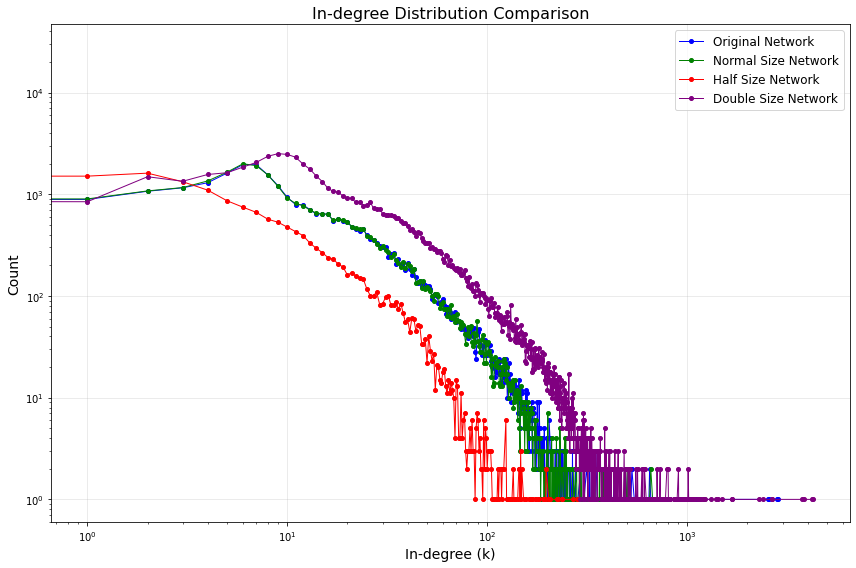

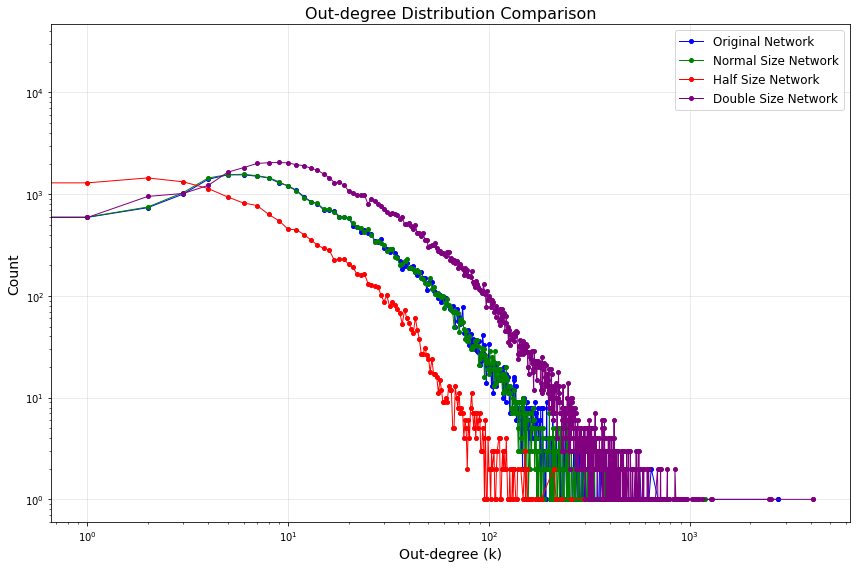

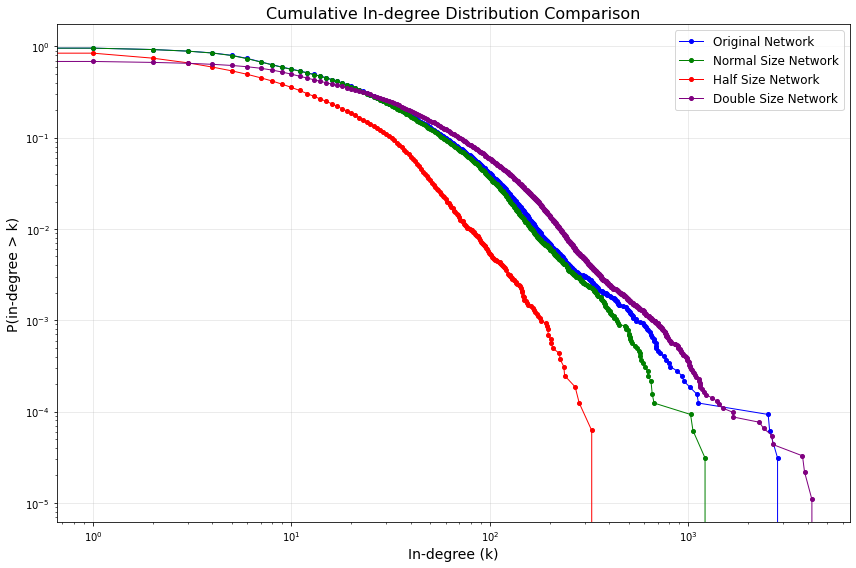

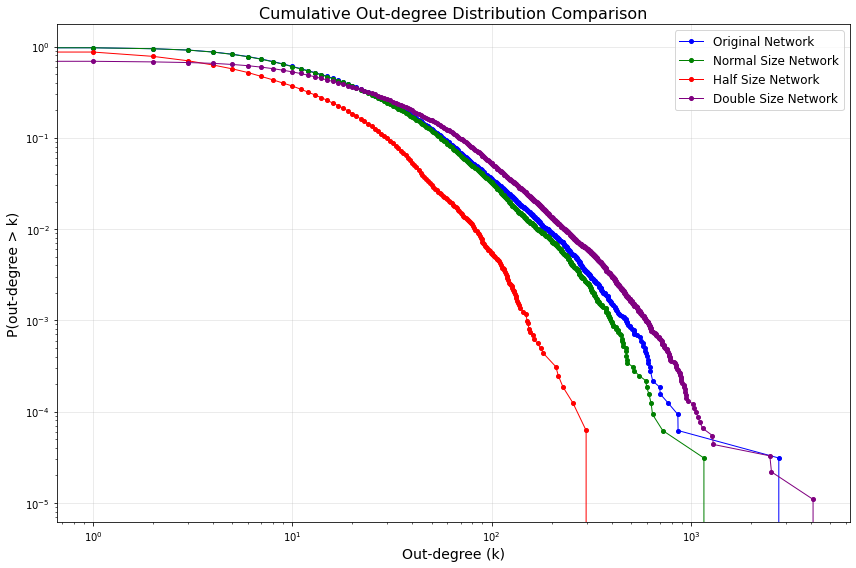

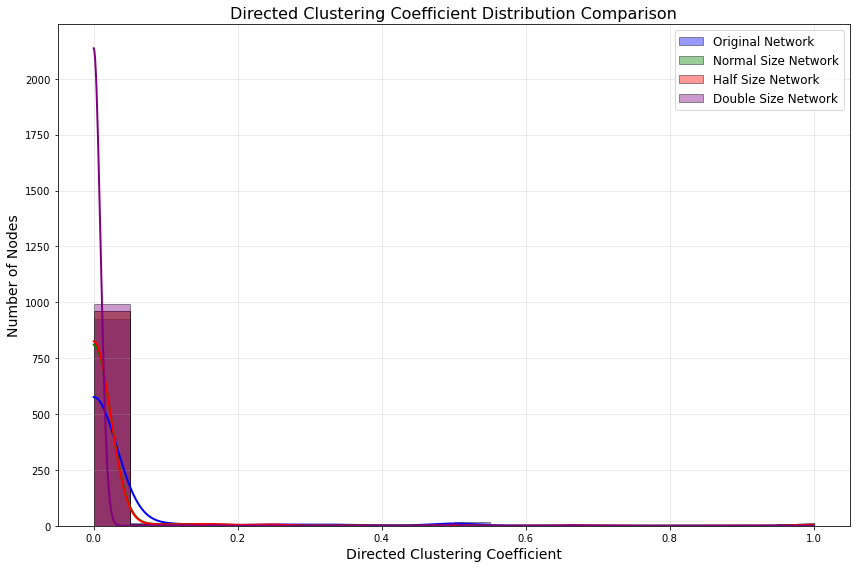

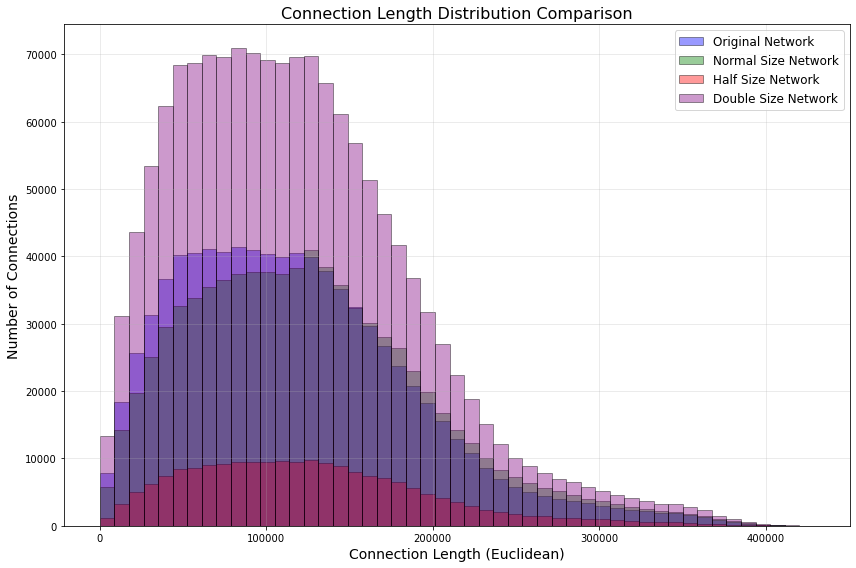

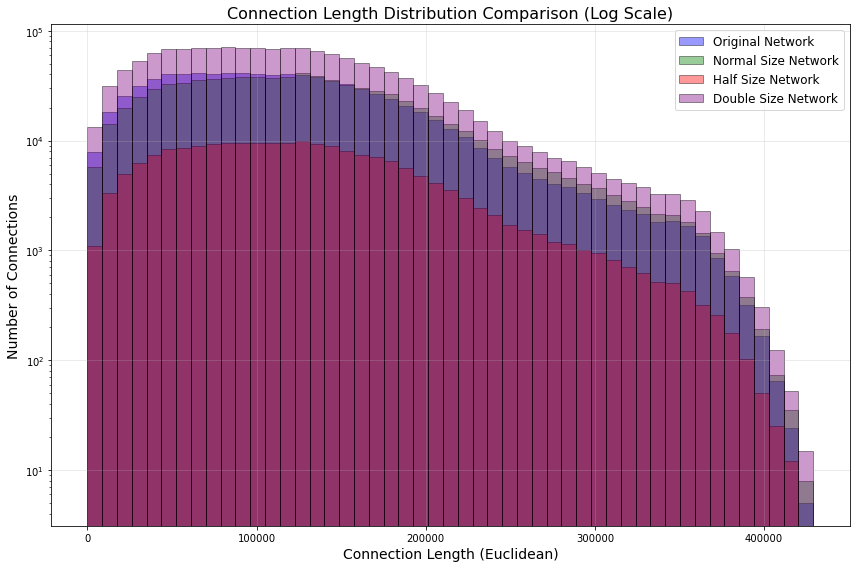

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict
import os
import random
from scipy.stats import gaussian_kde

print("Starting network comparison analysis...")

# Create output directory if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Created 'plots' directory")

# Function to calculate Euclidean distance
def calculate_euclidean_distance(graph, edge):
    u, v = edge
    try:
        u_coords = (graph.nodes[u]['x'], graph.nodes[u]['y'], graph.nodes[u]['z'])
        v_coords = (graph.nodes[v]['x'], graph.nodes[v]['y'], graph.nodes[v]['z'])
        return np.sqrt(sum((a - b) ** 2 for a, b in zip(u_coords, v_coords)))
    except KeyError:
        return None

# Load original network data
print("Loading original network data...")
try:
    edges_df = pd.read_csv("fly_edges.csv")
    metadata_df = pd.read_csv("fly_metadata.csv")
    print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes for original network")
    
    # Create original graph
    print("Creating original graph...")
    G_original = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in metadata_df.iterrows():
        node_id = node_data['node_id']
        G_original.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in edges_df.iterrows():
        G_original.add_edge(edge['from'], edge['to'])
    
    print(f"Original graph: {G_original.number_of_nodes()} nodes, {G_original.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading original network: {e}")
    G_original = None

# Load normal size model
print("Loading normal size model data...")
try:
    normal_edges_df = pd.read_csv("normal_size_ldpsbm_edges.csv")
    normal_metadata_df = pd.read_csv("normal_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(normal_edges_df)} edges and {len(normal_metadata_df)} nodes for normal size model")
    
    # Create normal size graph
    print("Creating normal size graph...")
    G_normal = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in normal_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_normal.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in normal_edges_df.iterrows():
        G_normal.add_edge(edge['from'], edge['to'])
    
    print(f"Normal size graph: {G_normal.number_of_nodes()} nodes, {G_normal.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading normal size model: {e}")
    G_normal = None

# Load half size model
print("Loading half size model data...")
try:
    half_edges_df = pd.read_csv("half_size_ldpsbm_edges.csv")
    half_metadata_df = pd.read_csv("half_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(half_edges_df)} edges and {len(half_metadata_df)} nodes for half size model")
    
    # Create half size graph
    print("Creating half size graph...")
    G_half = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in half_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_half.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in half_edges_df.iterrows():
        G_half.add_edge(edge['from'], edge['to'])
    
    print(f"Half size graph: {G_half.number_of_nodes()} nodes, {G_half.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading half size model: {e}")
    G_half = None

# Load double size model
print("Loading double size model data...")
try:
    double_edges_df = pd.read_csv("double_size_ldpsbm_edges.csv")
    double_metadata_df = pd.read_csv("double_size_ldpsbm_metadata.csv")
    print(f"Loaded {len(double_edges_df)} edges and {len(double_metadata_df)} nodes for double size model")
    
    # Create double size graph
    print("Creating double size graph...")
    G_double = nx.DiGraph()
    
    # Add nodes with metadata
    for _, node_data in double_metadata_df.iterrows():
        node_id = node_data['node_id']
        G_double.add_node(
            node_id,
            x=node_data['x'],
            y=node_data['y'],
            z=node_data['z'],
            module=node_data['module'],
            root_id=node_data['root_id']
        )
    
    # Add edges
    for _, edge in double_edges_df.iterrows():
        G_double.add_edge(edge['from'], edge['to'])
    
    print(f"Double size graph: {G_double.number_of_nodes()} nodes, {G_double.number_of_edges()} edges")
except Exception as e:
    print(f"Error loading double size model: {e}")
    G_double = None

# Create a list of valid graphs and their labels
graphs = []
labels = []

if G_original is not None:
    graphs.append(G_original)
    labels.append("Original")
if G_normal is not None:
    graphs.append(G_normal)
    labels.append("Normal Size")
if G_half is not None:
    graphs.append(G_half)
    labels.append("Half Size")
if G_double is not None:
    graphs.append(G_double)
    labels.append("Double Size")

print(f"Successfully loaded {len(graphs)} graphs for comparison")

if len(graphs) == 0:
    print("No valid graphs found. Please check the input files.")
    exit()

# Define colors for each graph
colors = ['blue', 'green', 'red', 'purple']
colors = colors[:len(graphs)]  # Slice to match number of graphs

# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.png', dpi=600)
print("Saved in-degree distribution comparison plot")

# Plot out-degree distributions
print("Plotting out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    plt.loglog(
        sorted(out_degree_counts.keys()),
        [out_degree_counts[k] for k in sorted(out_degree_counts.keys())],
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.png', dpi=600)
print("Saved out-degree distribution comparison plot")

# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.png', dpi=600)
print("Saved cumulative in-degree distribution comparison plot")

# Plot cumulative out-degree distributions
print("Plotting cumulative out-degree distributions...")
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    sorted_degrees = sorted(out_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label} Network"
    )

plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('P(out-degree > k)', fontsize=14)
plt.title('Cumulative Out-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_out_degree.png', dpi=600)
print("Saved cumulative out-degree distribution comparison plot")

# Define directed clustering coefficient function
def directed_clustering_coefficient(G):
    """Calculate directed clustering coefficient for each node in the graph."""
    clustering = {}
    
    for node in G.nodes():
        # Get predecessors and successors
        preds = set(G.predecessors(node))
        succs = set(G.successors(node))
        
        # Remove self-loops
        if node in preds:
            preds.remove(node)
        if node in succs:
            succs.remove(node)
        
        # Calculate possible triangles
        possible_triangles = len(preds) * len(succs)
        
        # If no possible triangles, clustering is 0 or undefined (we'll use 0)
        if possible_triangles == 0:
            clustering[node] = 0
            continue
        
        # Count actual triangles
        actual_triangles = 0
        for pred in preds:
            for succ in succs:
                if G.has_edge(pred, succ):
                    actual_triangles += 1
        
        # Calculate clustering coefficient
        clustering[node] = actual_triangles / possible_triangles
    
    return clustering

# Calculate and plot clustering coefficients
print("Calculating directed clustering coefficients...")
clustering_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating directed clustering for {label} network...")
    # Sample nodes for large networks to speed up calculation
    if G.number_of_nodes() > 1000:
        sample_nodes = random.sample(list(G.nodes()), 1000)
        subgraph = G.subgraph(sample_nodes)
        clustering = directed_clustering_coefficient(subgraph)
        print(f"Sampled {len(sample_nodes)} nodes for clustering calculation")
    else:
        clustering = directed_clustering_coefficient(G)
    
    clustering_data[label] = list(clustering.values())
    print(f"{label} network average directed clustering: {np.mean(list(clustering.values())):.4f}")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=0.4,
        color=colors[i],
        edgecolor='black',
        label=f"{label} Network"
    )
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i]
        )

plt.xlabel('Directed Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Directed Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_directed_clustering_coefficient.png', dpi=600)
print("Saved directed clustering coefficient distribution comparison plot")

# Calculate and plot connection distances
print("Calculating connection distances...")
distance_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating distances for {label} network...")
    # Use all edges for the distance calculation as requested
    print(f"Processing all {G.number_of_edges()} edges for distance calculation")
    
    distances = []
    for edge in G.edges():
        distance = calculate_euclidean_distance(G, edge)
        if distance is not None:
            distances.append(distance)
    
    distance_data[label] = distances
    print(f"{label} network: {len(distances)} distances calculated, avg = {np.mean(distances):.4f}")

# Plot connection distance distributions
print("Plotting connection distance distributions...")
plt.figure(figsize=(12, 8))

max_distance = max([max(distances) for distances in distance_data.values() if distances])
bins = np.linspace(0, max_distance, 50)

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label} Network"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot")

# Plot connection distance distributions with log scale
print("Plotting connection distance distributions with log scale...")
plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=0.4,
            color=colors[i],
            edgecolor='black',
            label=f"{label} Network"
        )

plt.xlabel('Connection Length (Euclidean)', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.yscale('log')
plt.title('Connection Length Distribution Comparison (Log Scale)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length_log.png', dpi=600)
print("Saved log-scale connection length distribution comparison plot")

# Generate a summary table
print("Generating network comparison summary...")
summary_data = {
    'Network': labels,
    'Nodes': [G.number_of_nodes() for G in graphs],
    'Edges': [G.number_of_edges() for G in graphs],
    'Avg In-Degree': [np.mean([d for _, d in G.in_degree()]) for G in graphs],
    'Avg Out-Degree': [np.mean([d for _, d in G.out_degree()]) for G in graphs],
    'Max In-Degree': [max([d for _, d in G.in_degree()]) for G in graphs],
    'Max Out-Degree': [max([d for _, d in G.out_degree()]) for G in graphs],
    'Avg Directed Clustering': [np.mean(clustering_data[label]) for label in labels],
    'Avg Connection Length': [np.mean(distance_data[label]) if distance_data[label] else np.nan for label in labels],
    'Min Connection Length': [min(distance_data[label]) if distance_data[label] else np.nan for label in labels],
    'Max Connection Length': [max(distance_data[label]) if distance_data[label] else np.nan for label in labels],
}

summary_df = pd.DataFrame(summary_data)
print("\nNetwork Comparison Summary:")
print(summary_df)

# Save summary to CSV
summary_df.to_csv('network_comparison_summary.csv', index=False)
print("Saved network comparison summary to CSV")

print("Network comparison analysis complete!")

In [15]:
# Create a list of valid graphs and their labels
graphs = []
labels = []
lines = []
if G_original is not None:
    graphs.append(G_original)
    labels.append("Original Network")
if G_normal is not None:
    graphs.append(G_normal)
    labels.append("Config-SBM")
if G_half is not None:
    graphs.append(G_half)
    labels.append("Config-SBM (Scale x1/2)")
if G_double is not None:
    graphs.append(G_double)
    labels.append("Config-SBM (Scale x2)")
print(f"Successfully loaded {len(graphs)} graphs for comparison")
if len(graphs) == 0:
    print("No valid graphs found. Please check the input files.")
    exit()
# Define colors for each graph
colors = ['black', 'red', 'green', 'blue']
colors = colors[:len(graphs)]  # Slice to match number of graphs
# Plot in-degree distributions

Successfully loaded 4 graphs for comparison


Plotting in-degree distributions...
Saved in-degree distribution comparison plot


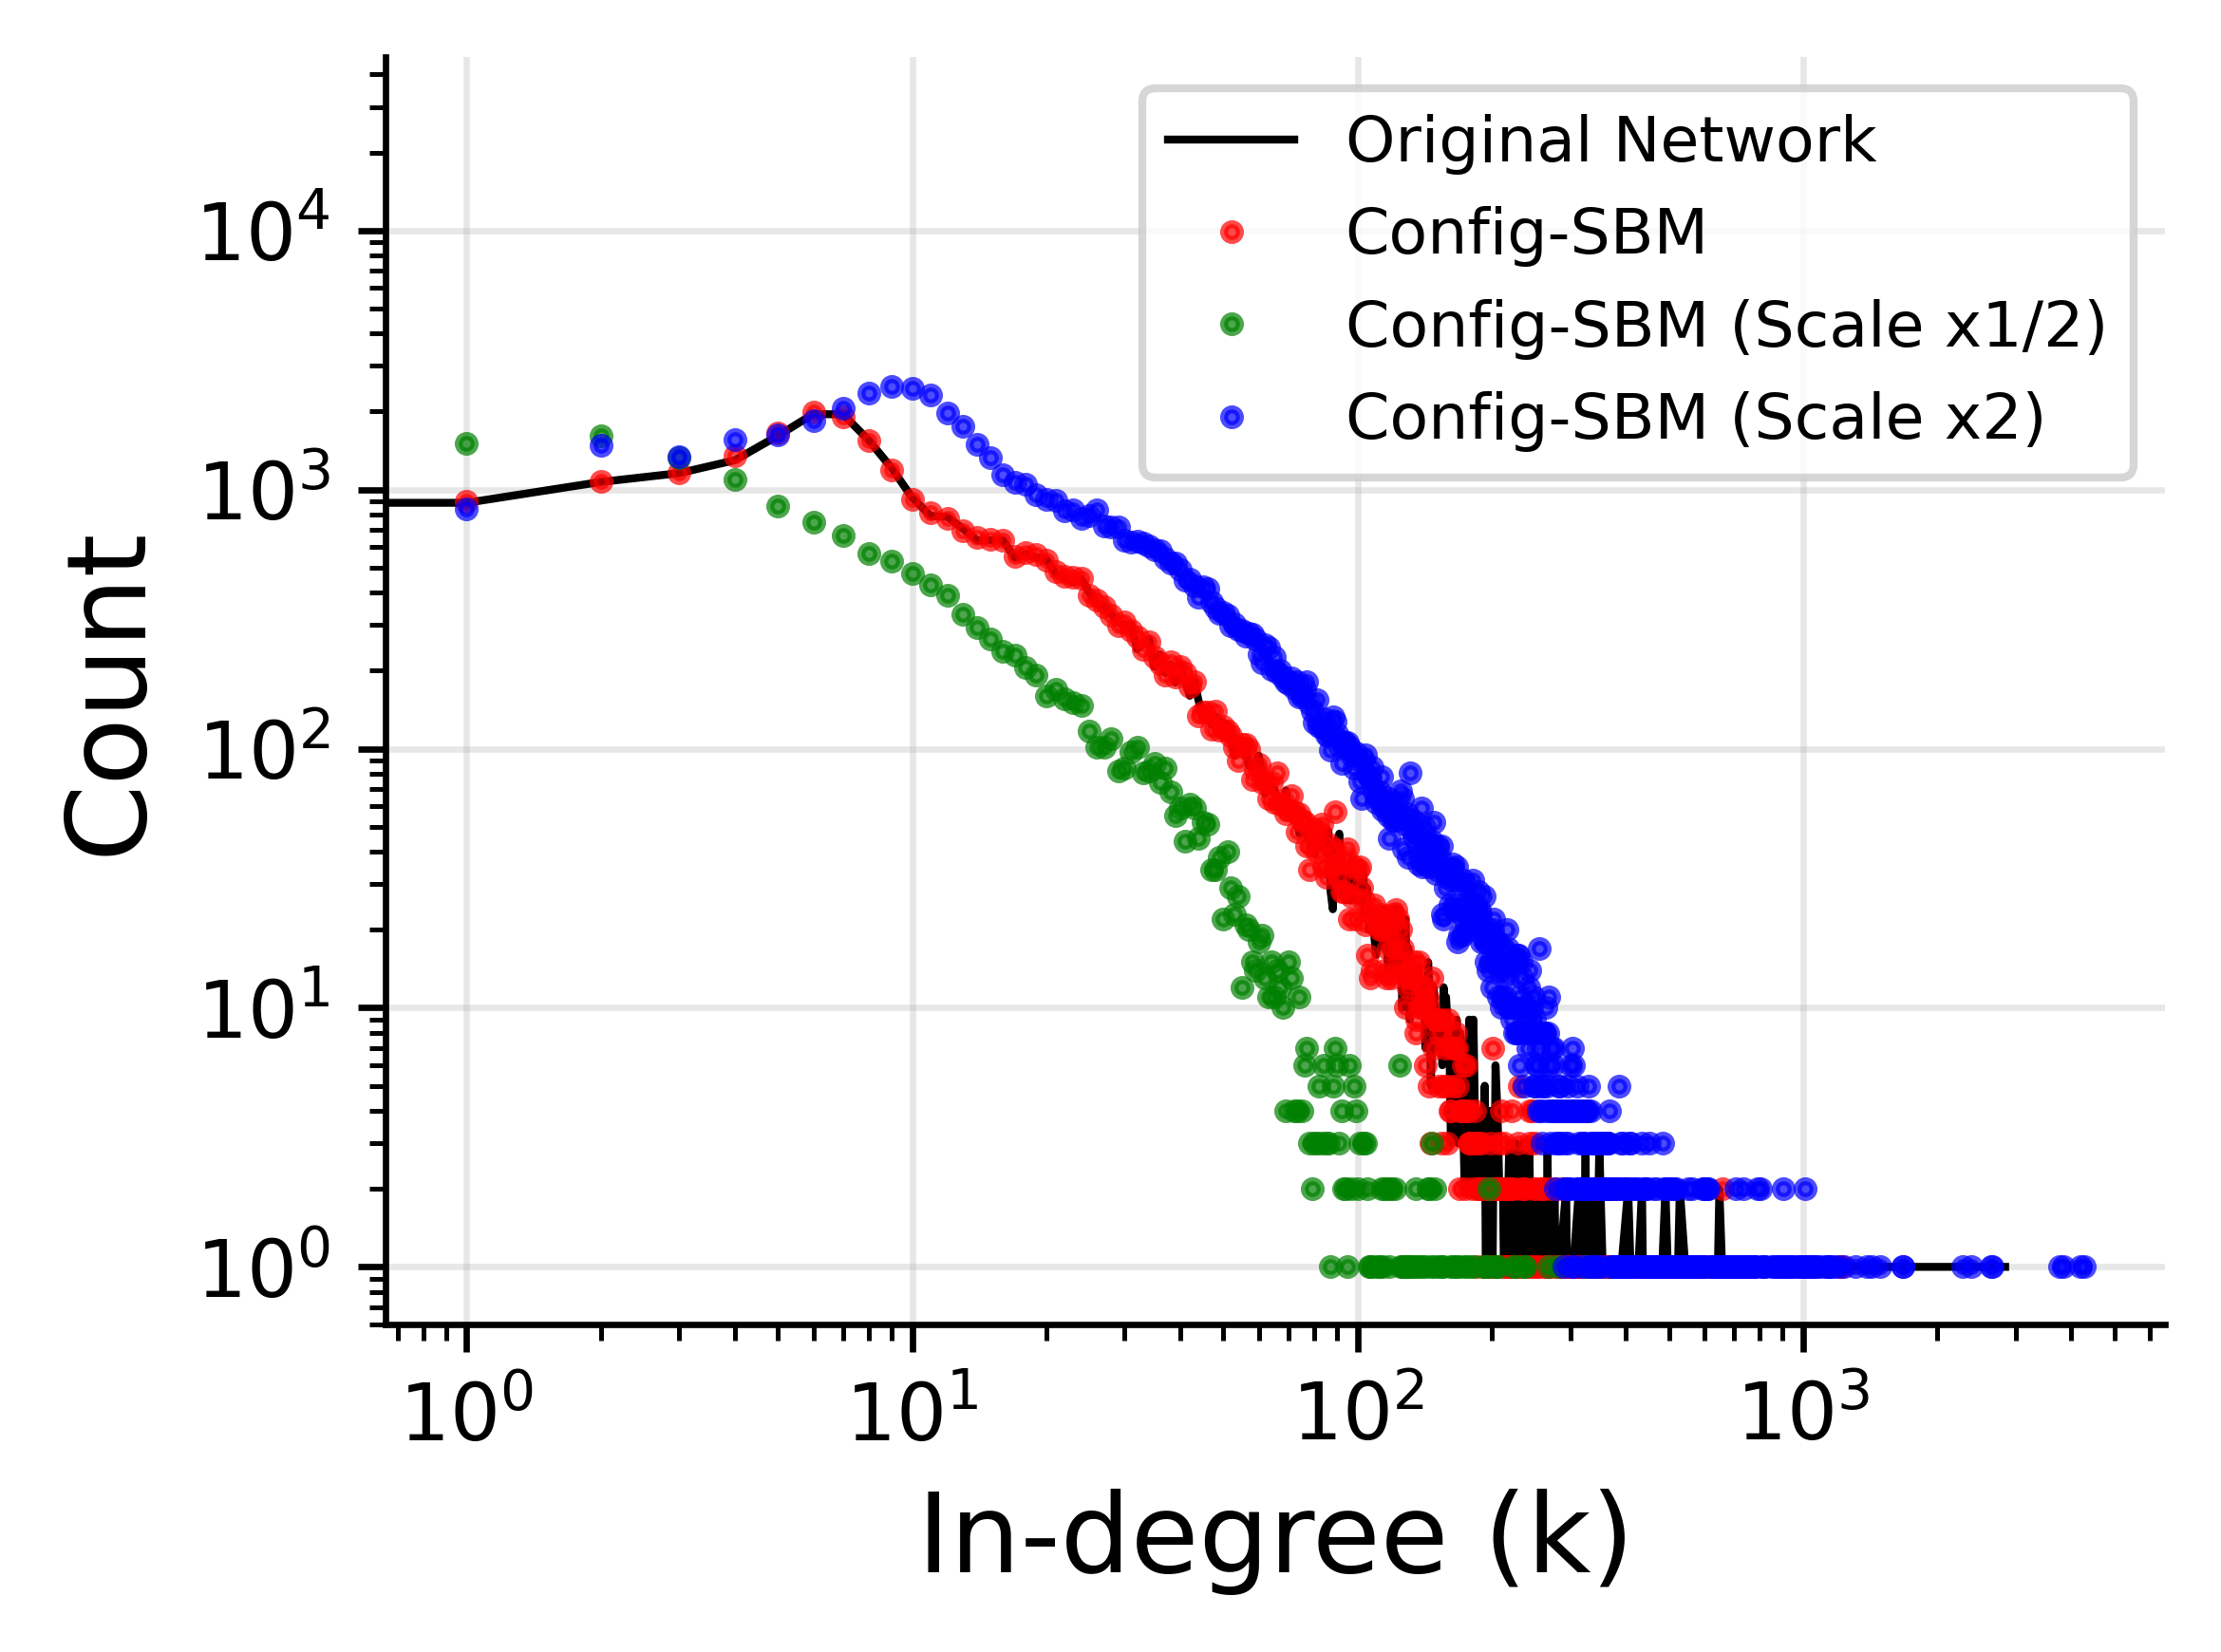

In [4]:
# Plot in-degree distributions
print("Plotting in-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)
for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    
    # Set linewidth to 1 for original network only, 0 for others
    lw = 1 if label == "Original Network" else 0
    ms = 0 if label == "Original Network" else 4
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        sorted(in_degree_counts.keys()),
        [in_degree_counts[k] for k in sorted(in_degree_counts.keys())],
        marker='.',
        markersize=ms,
        linewidth=lw,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )
plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('In-degree Distribution Comparison', fontsize=16)
# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/comparison_in_degree_distribution.pdf')
print("Saved in-degree distribution comparison plot")

Plotting out-degree distributions...
Saved out-degree distribution comparison plot


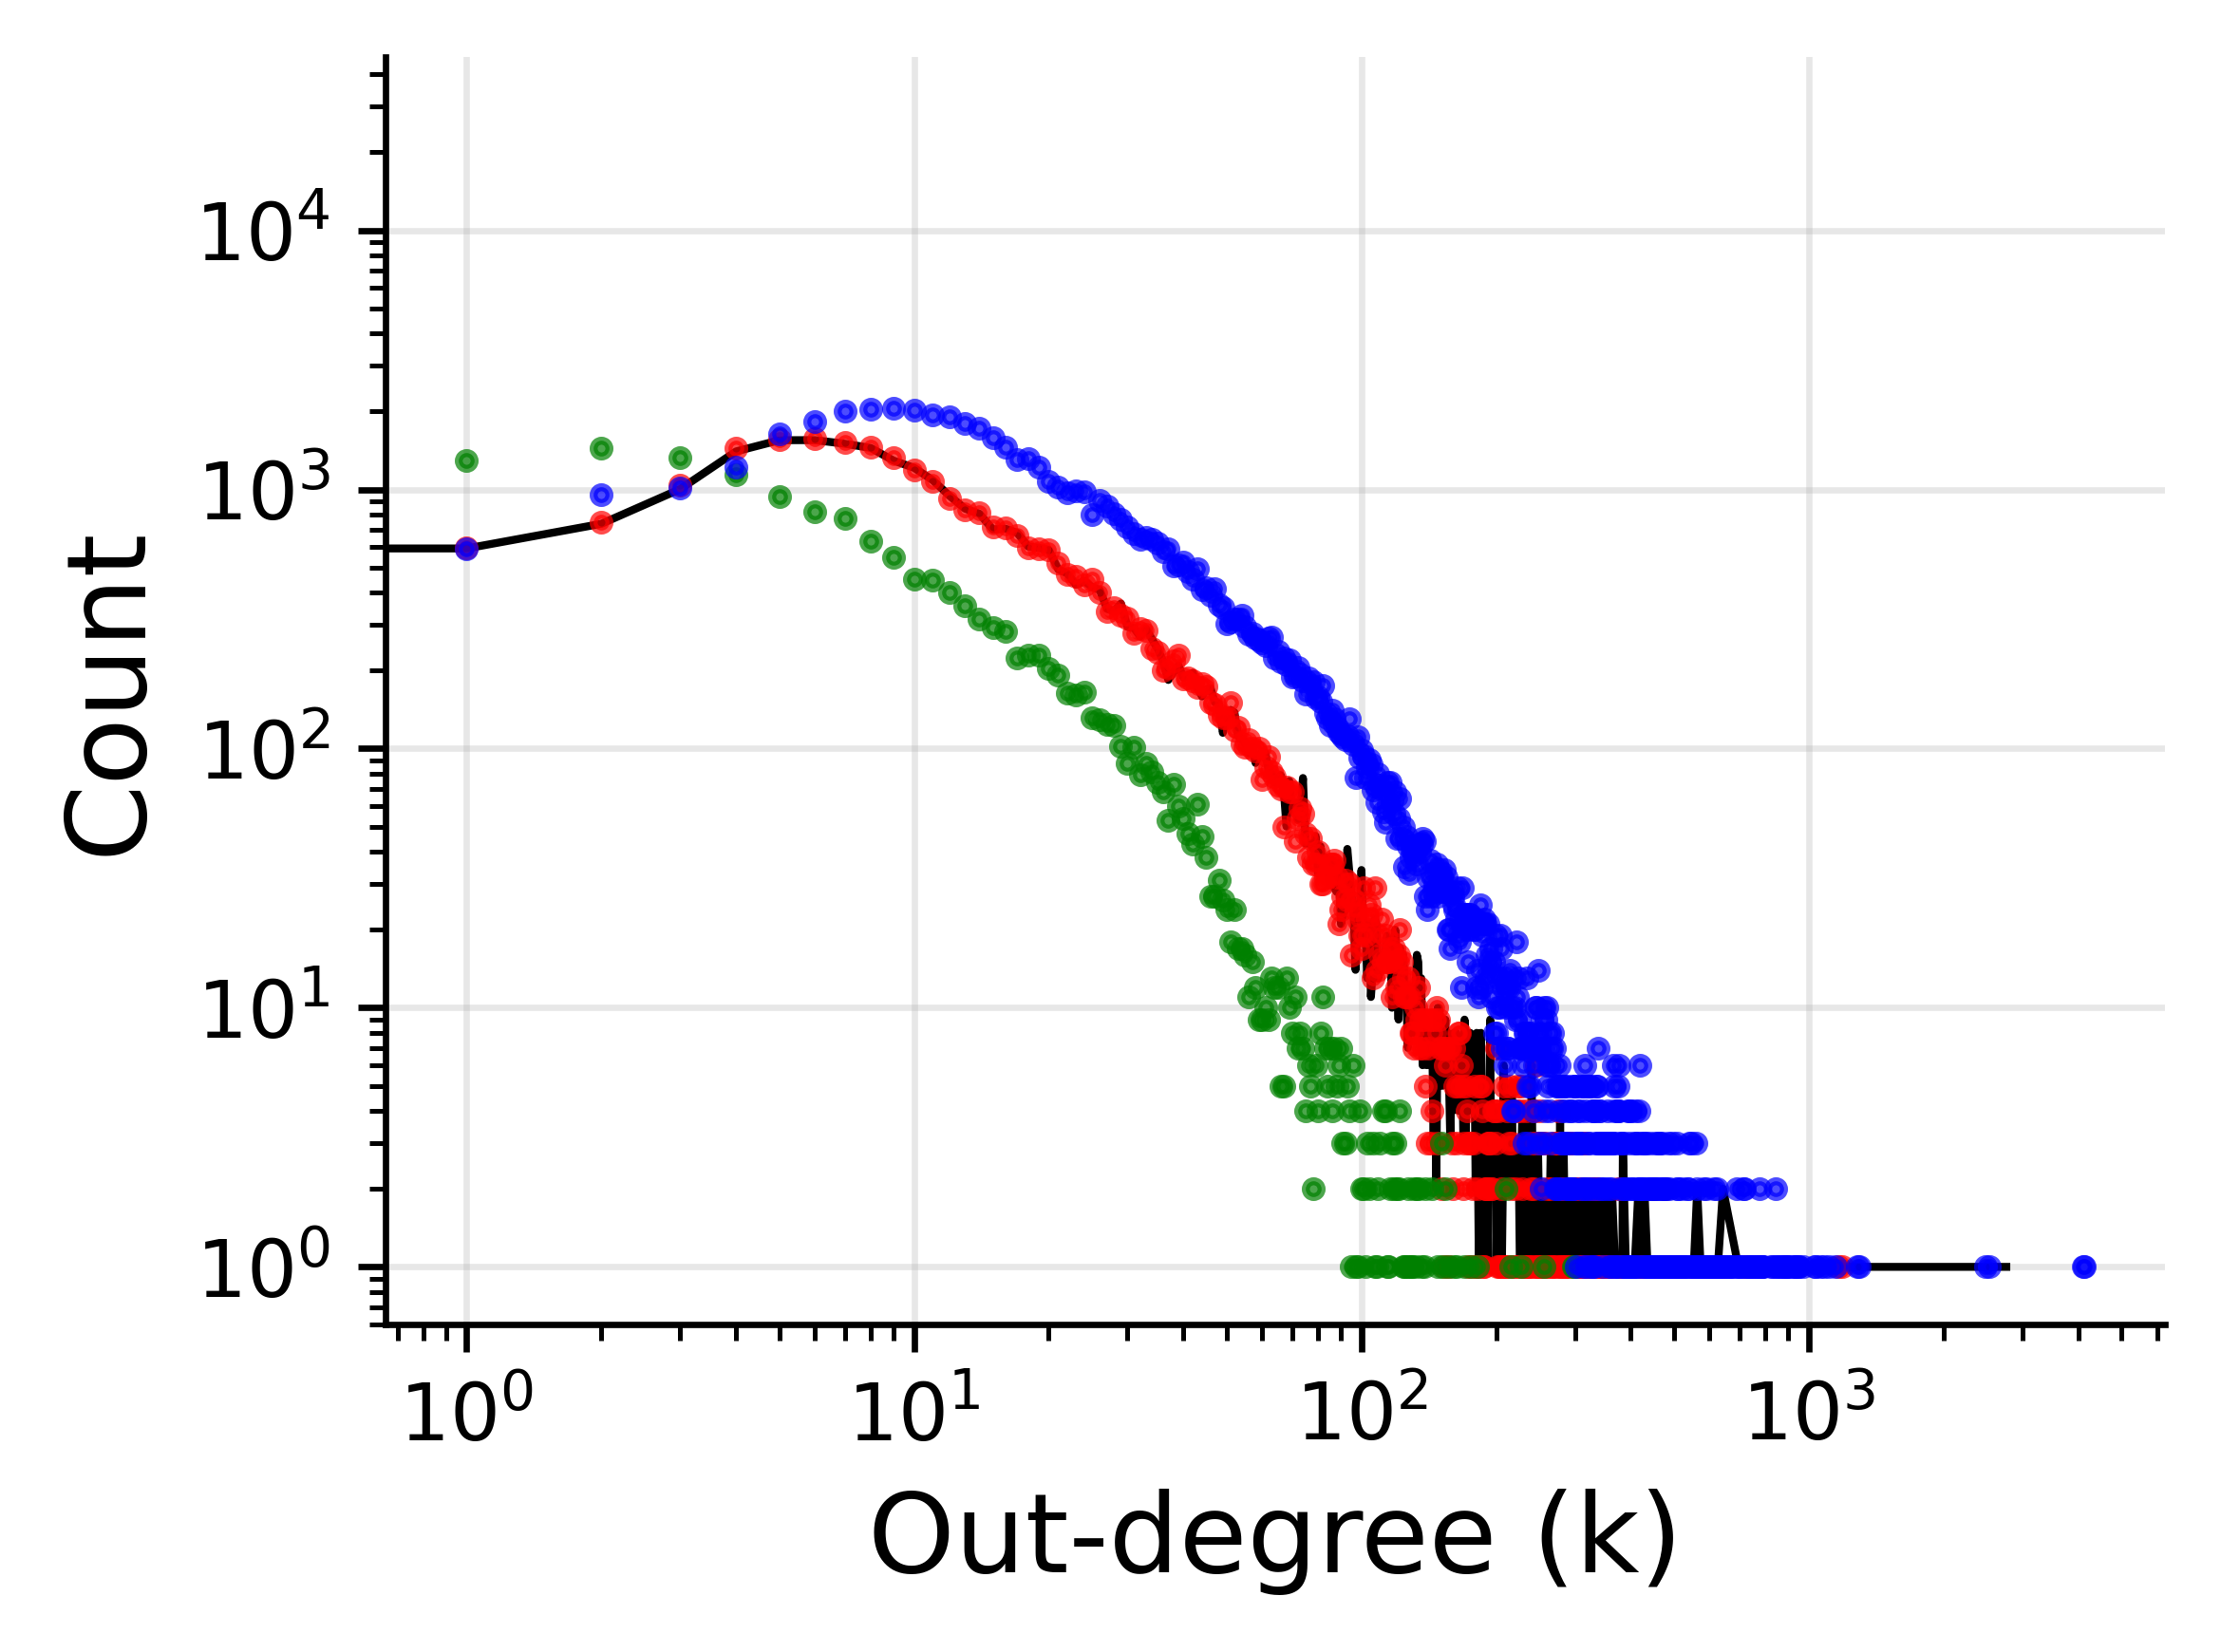

In [7]:
# Plot in-degree distributions
print("Plotting out-degree distributions...")
plt.figure(figsize=(4, 3),dpi=600)
for i, (G, label) in enumerate(zip(graphs, labels)):
    out_degrees = [d for n, d in G.out_degree()]
    out_degree_counts = Counter(out_degrees)
    
    # Set linewidth to 1 for original network only, 0 for others
    lw = 1 if label == "Original Network" else 0
    ms = 0 if label == "Original Network" else 4
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        sorted(out_degree_counts.keys()),
        [out_degree_counts[k] for k in sorted(out_degree_counts.keys())],
        marker='.',
        markersize=ms,
        linewidth=lw,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )
plt.grid(True, alpha=0.3)
plt.xlabel('Out-degree (k)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('In-degree Distribution Comparison', fontsize=16)
# plt.legend(fontsize=7)
# Remove the top and right spines for a cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/comparison_out_degree_distribution.pdf')
print("Saved out-degree distribution comparison plot")

Plotting cumulative in-degree distributions...
Saved cumulative in-degree distribution comparison plot


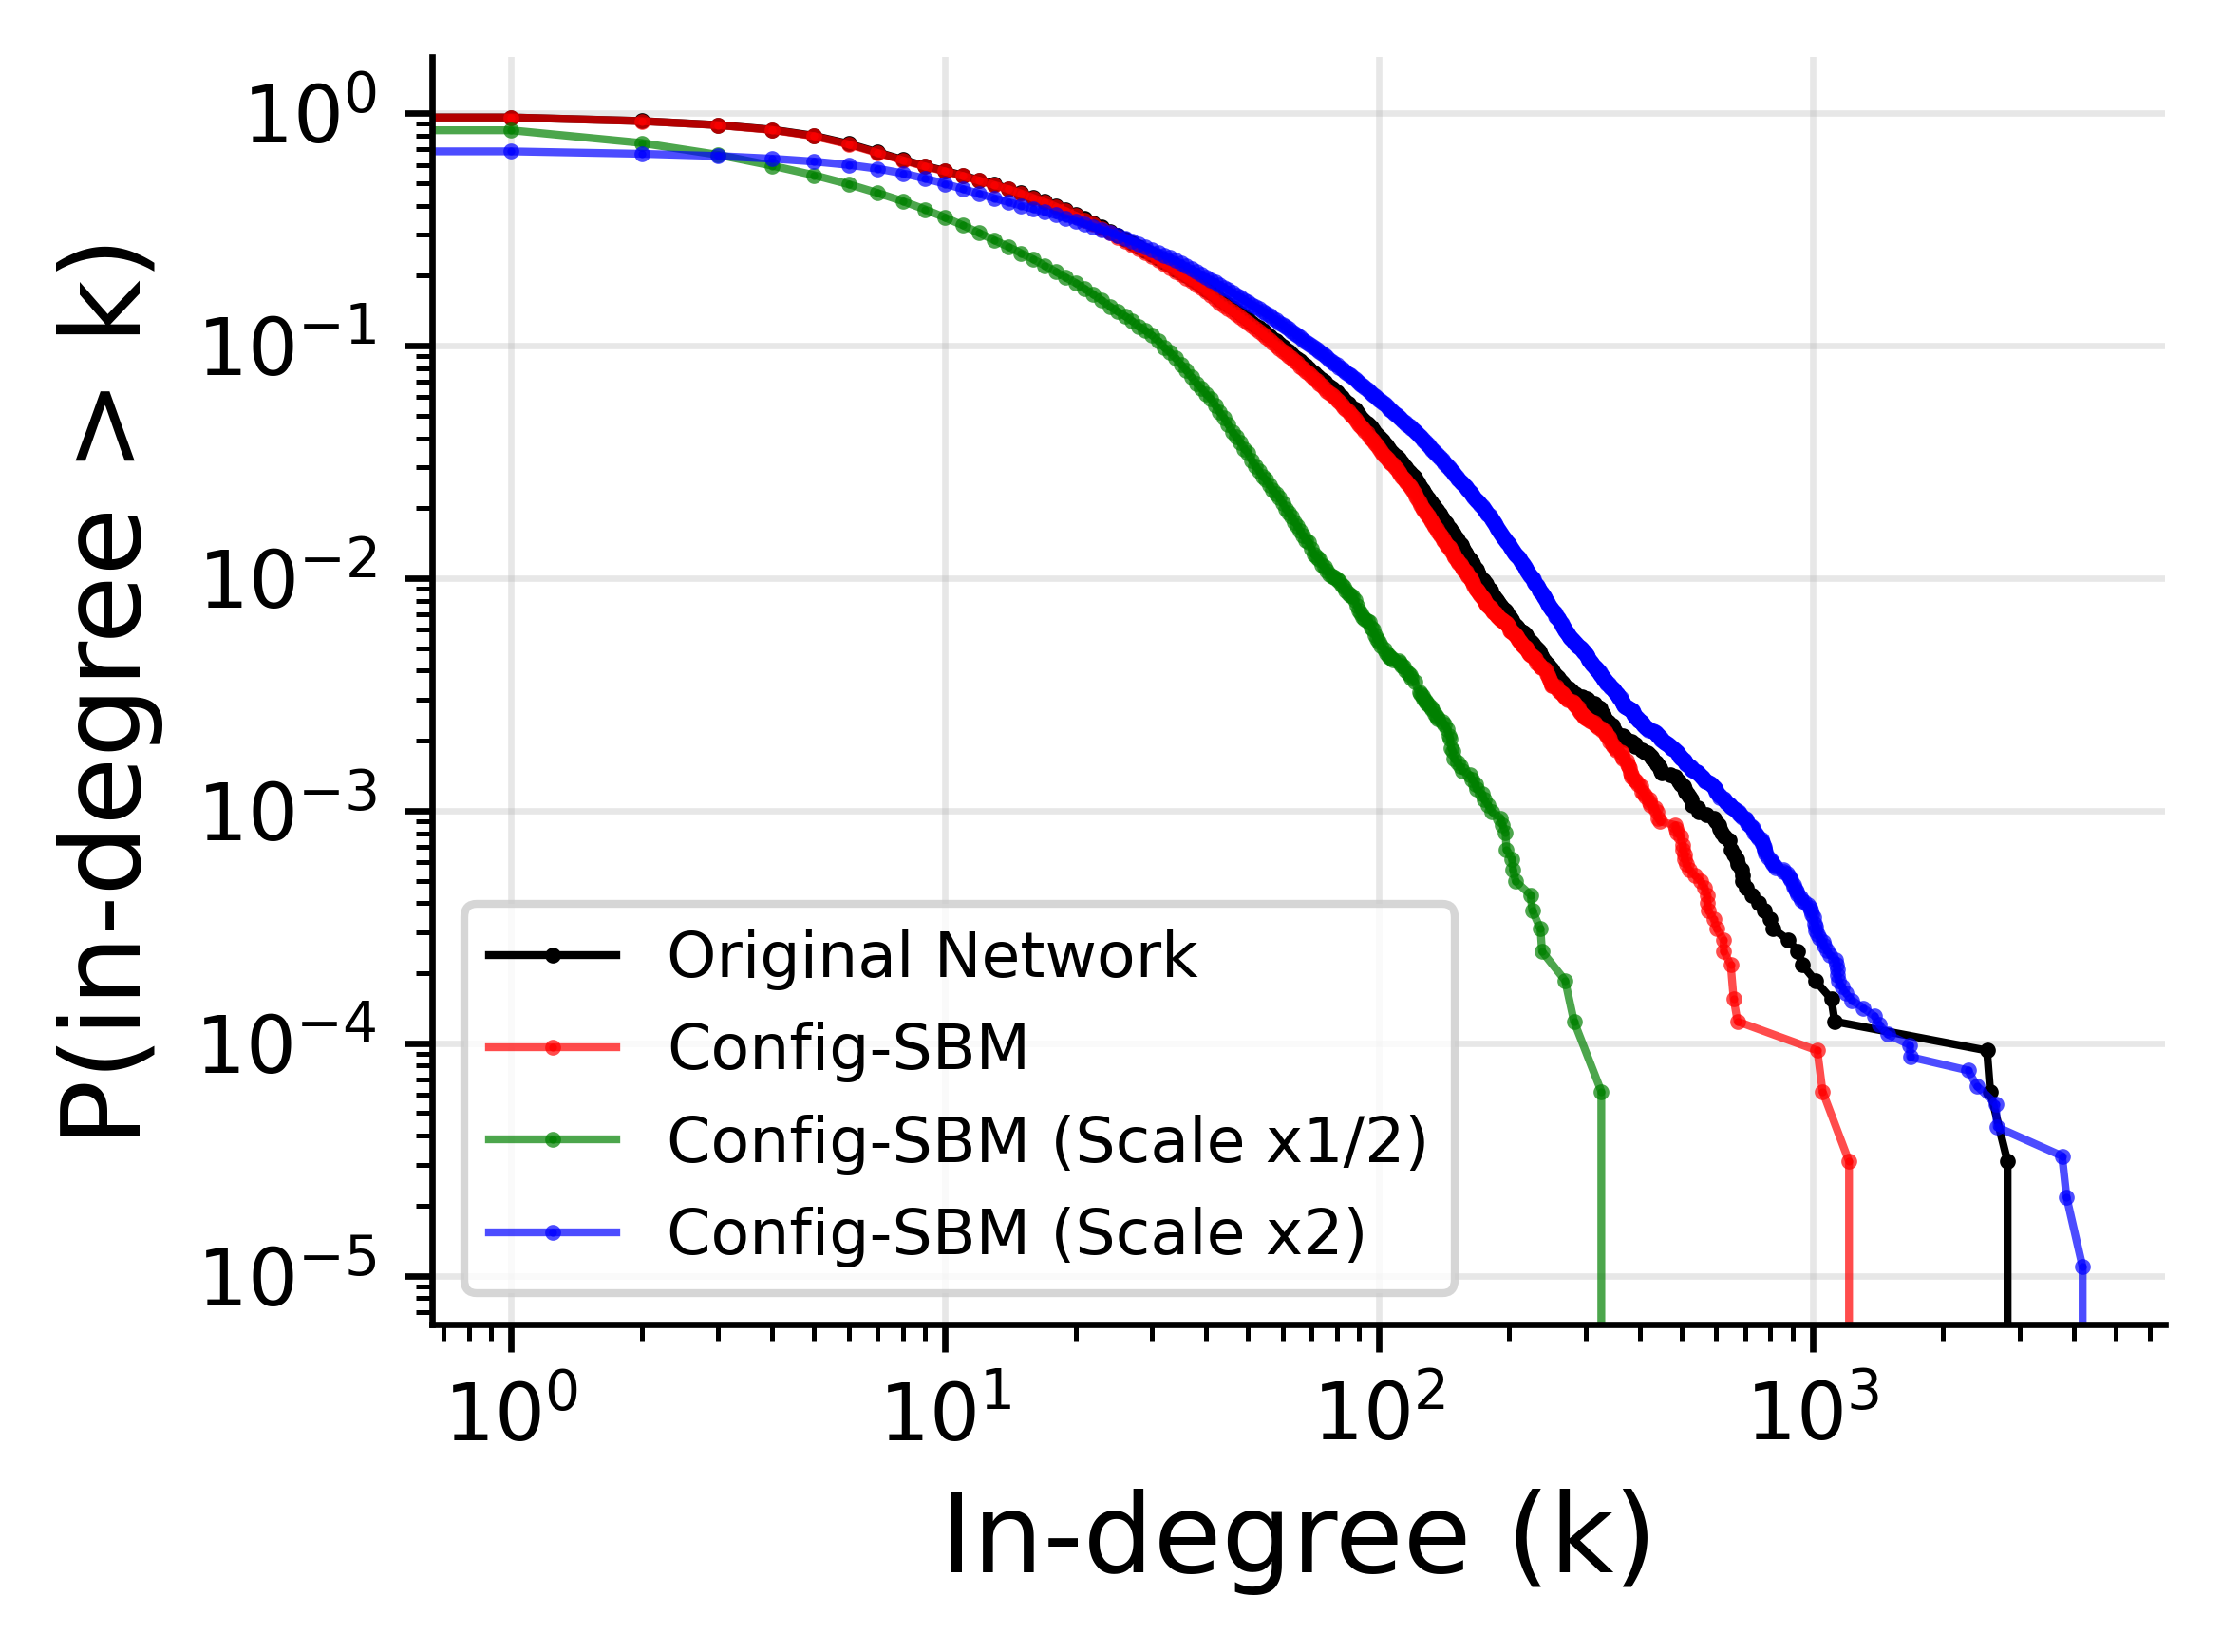

In [10]:
# Plot cumulative in-degree distributions
print("Plotting cumulative in-degree distributions...")
plt.figure(figsize=(4,3),dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=1,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
plt.xlabel('In-degree (k)', fontsize=14)
plt.ylabel('P(in-degree > k)', fontsize=14)
# plt.title('Cumulative In-degree Distribution Comparison', fontsize=16)
plt.legend(fontsize=8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree.pdf')
print("Saved cumulative in-degree distribution comparison plot")

Plotting cumulative in-degree distributions tail (focused on high in-degrees)...
Saved cumulative in-degree distribution tail plot


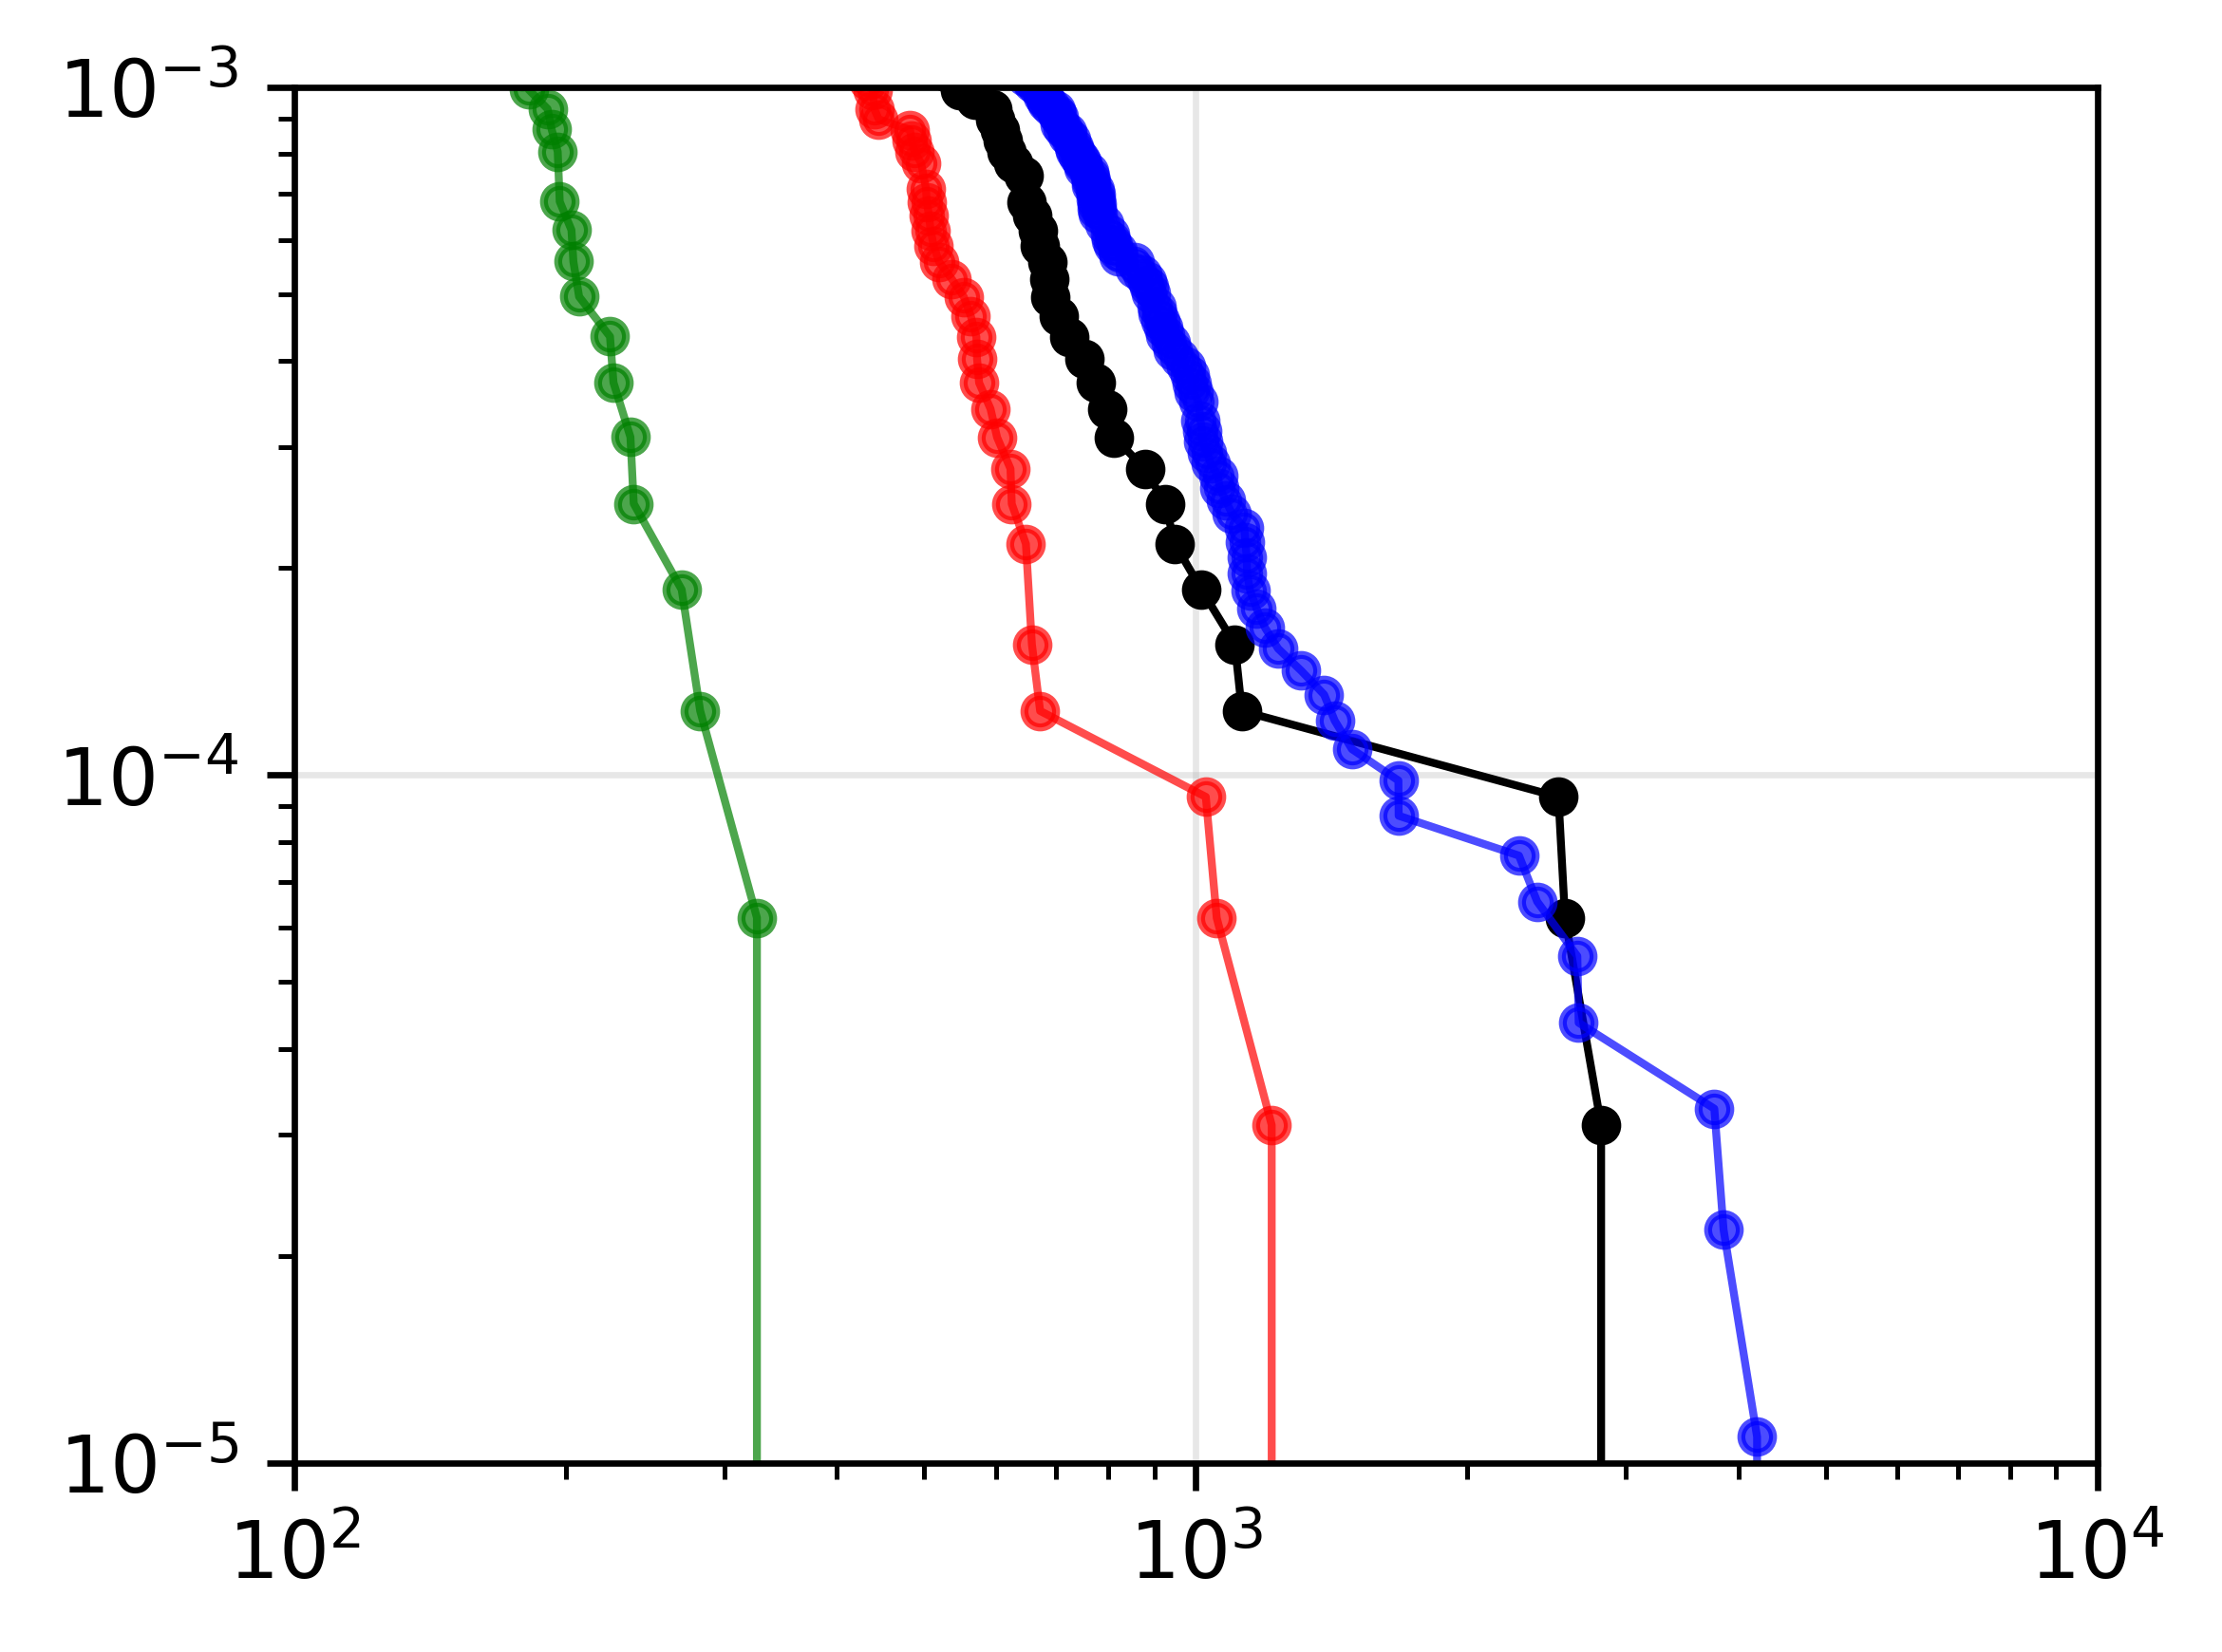

In [9]:
# Plot cumulative in-degree distributions (tail focus)
print("Plotting cumulative in-degree distributions tail (focused on high in-degrees)...")
plt.figure(figsize=(4,3), dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
# plt.xlabel('In-degree (k)', fontsize=14)
# plt.ylabel('P(in-degree > k)', fontsize=14)
plt.xlim(1e2, 1e4)   # Focus on high in-degrees
plt.ylim(1e-5, 1e-3) # Focus on the tail probabilities
# plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree_tail.pdf')
print("Saved cumulative in-degree distribution tail plot")


Plotting cumulative in-degree distributions head (focused on low in-degrees)...
Saved cumulative in-degree distribution head plot


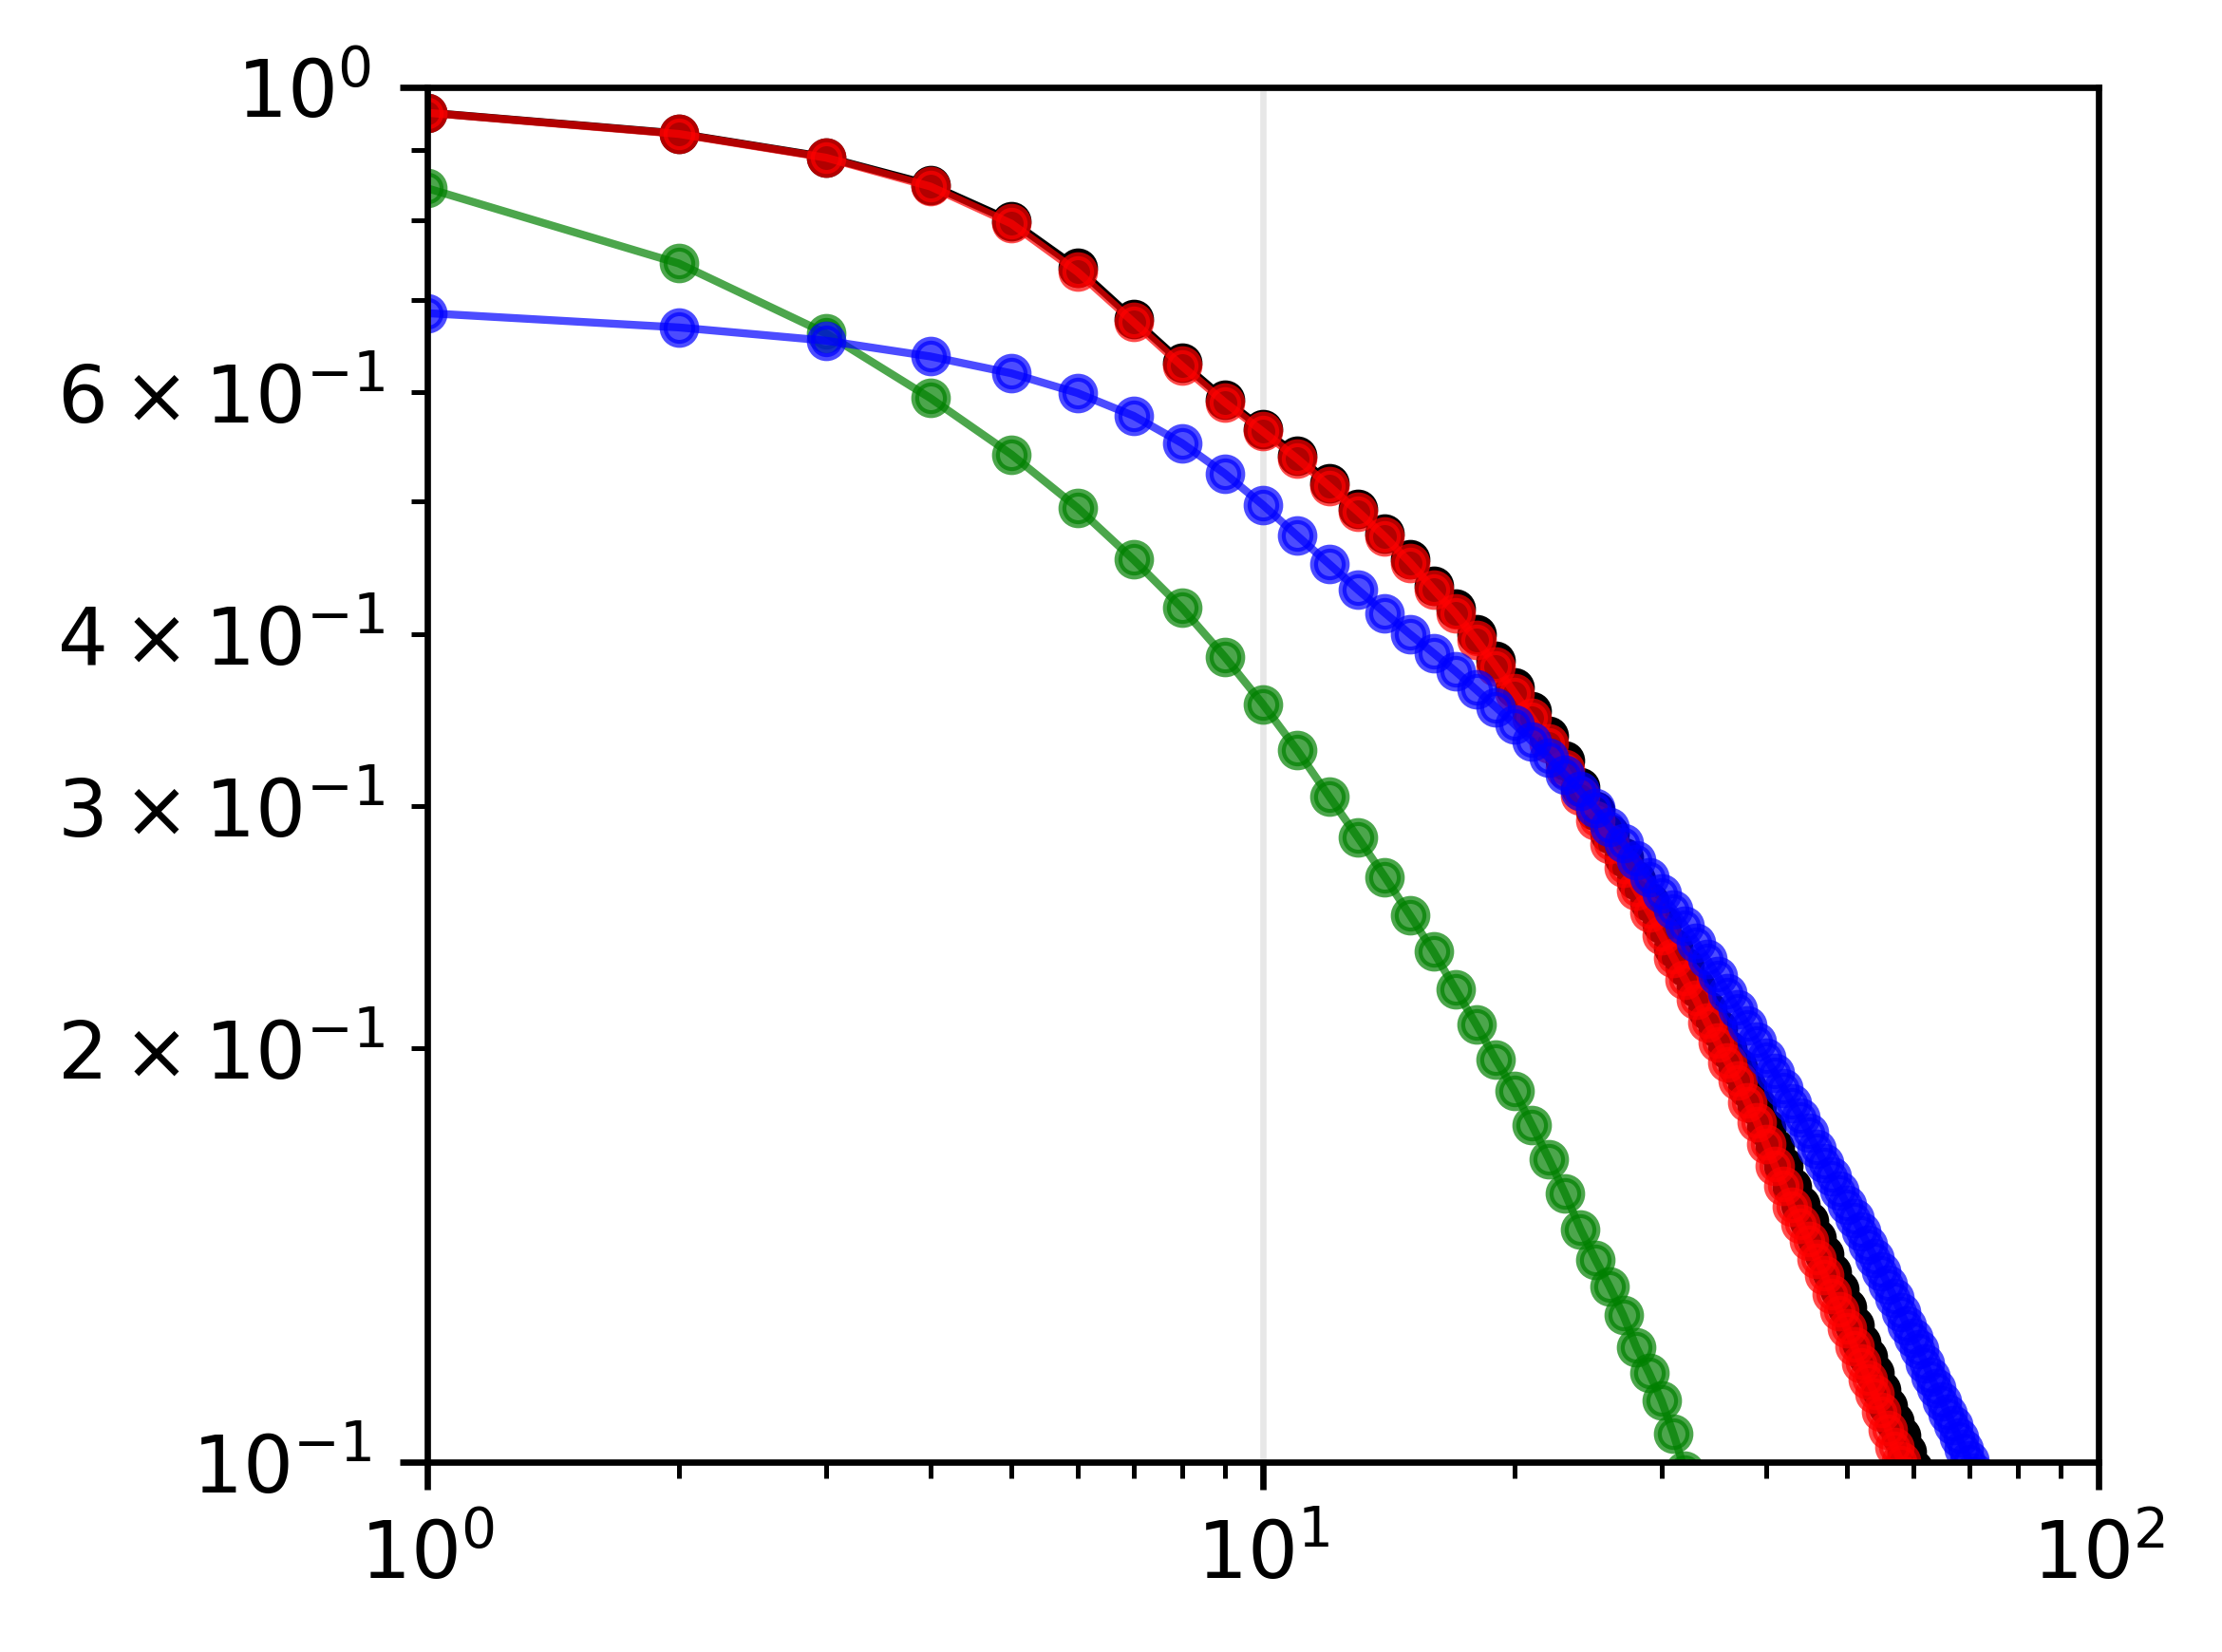

In [10]:
# Plot cumulative in-degree distributions (tail focus)
print("Plotting cumulative in-degree distributions head (focused on low in-degrees)...")
plt.figure(figsize=(4,3), dpi=600)

for i, (G, label) in enumerate(zip(graphs, labels)):
    in_degrees = [d for n, d in G.in_degree()]
    in_degree_counts = Counter(in_degrees)
    sorted_degrees = sorted(in_degree_counts.items())
    
    x_vals = [k for k, _ in sorted_degrees]
    y_vals = []
    count_so_far = 0
    total_nodes = G.number_of_nodes()
    
    for _, count in sorted_degrees:
        count_so_far += count
        y_vals.append(1 - count_so_far / total_nodes)  # P(degree > k)
    
    alp = 1 if label == "Original Network" else 0.7
    
    plt.loglog(
        x_vals,
        y_vals,
        marker='o',
        markersize=4,
        linewidth=1,
        color=colors[i],
        label=f"{label}",
        alpha=alp
    )

plt.grid(True, alpha=0.3)
# plt.xlabel('In-degree (k)', fontsize=14)
# plt.ylabel('P(in-degree > k)', fontsize=14)
plt.xlim(1e0, 1e2)   # Focus on high in-degrees
plt.ylim(1e-1,1e-0) # Focus on the tail probabilities
# plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/comparison_cumulative_in_degree_head.pdf')
print("Saved cumulative in-degree distribution head plot")


Calculating clustering coefficients...
Calculating clustering for Original Network network...
Using NetworkX's clustering function
Clustering calculation results:
  Number of nodes with clustering values: 32272
  Min clustering value: 0.0000
  Max clustering value: 1.0000
  Mean clustering value: 0.1583
Original Network network average clustering: 0.1583
Calculating clustering for Config-SBM network...
Using NetworkX's clustering function
Clustering calculation results:
  Number of nodes with clustering values: 32272
  Min clustering value: 0.0000
  Max clustering value: 1.0000
  Mean clustering value: 0.0673
Config-SBM network average clustering: 0.0673
Calculating clustering for Config-SBM (Scale x1/2) network...
Using NetworkX's clustering function
Clustering calculation results:
  Number of nodes with clustering values: 16123
  Min clustering value: 0.0000
  Max clustering value: 1.0000
  Mean clustering value: 0.0479
Config-SBM (Scale x1/2) network average clustering: 0.0479
Calcu

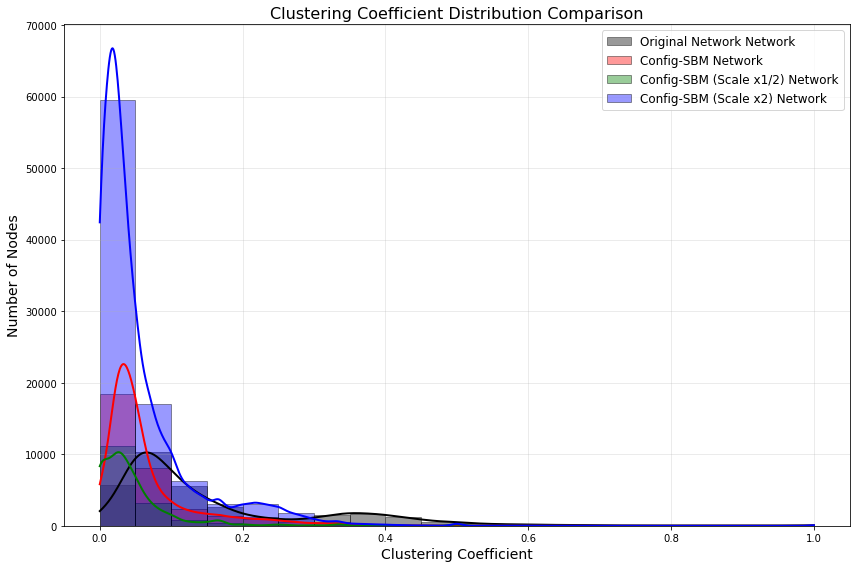

In [9]:
# Calculate and plot clustering coefficients
print("Calculating clustering coefficients...")
clustering_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating clustering for {label} network...")
    
    # Use NetworkX's built-in transitivity calculation
    print(f"Using NetworkX's clustering function")
    
    # Convert to undirected for standard clustering coefficient
    undirected_G = G.copy()
    
#     # Sample nodes for large networks to speed up calculation
#     if undirected_G.number_of_nodes() > 1000:
#         sample_nodes = random.sample(list(undirected_G.nodes()), 1000)
#         subgraph = undirected_G.subgraph(sample_nodes)
#         print(f"Sampled {len(sample_nodes)} nodes for clustering calculation")
#     else:
#         subgraph = undirected_G
    subgraph = undirected_G
    
    # Compute local clustering for each node
    clustering = nx.clustering(subgraph)
    
    # Debug info
    print(f"Clustering calculation results:")
    print(f"  Number of nodes with clustering values: {len(clustering)}")
    print(f"  Min clustering value: {min(clustering.values()):.4f}")
    print(f"  Max clustering value: {max(clustering.values()):.4f}")
    print(f"  Mean clustering value: {np.mean(list(clustering.values())):.4f}")
    
    clustering_data[label] = list(clustering.values())
    print(f"{label} network average clustering: {np.mean(list(clustering.values())):.4f}")

# Plot clustering coefficient distributions
print("Plotting clustering coefficient distributions...")
plt.figure(figsize=(12, 8))
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1

for i, label in enumerate(labels):
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=0.4,
        color=colors[i],
        edgecolor='black',
        label=f"{label} Network"
    )
    
    # Add kernel density estimation if there are enough values
    if len(values) > 10:
        kde = gaussian_kde(values)
        x_vals = np.linspace(0, 1, 1000)
        plt.plot(
            x_vals,
            kde(x_vals) * len(values) * (bins[1] - bins[0]),
            linewidth=2,
            color=colors[i]
        )

plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.title('Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_clustering_coefficient.png', dpi=600)
print("Saved clustering coefficient distribution comparison plot")

Plotting clustering coefficient distributions with log scale...
Saved clustering coefficient distribution comparison plot with log scale


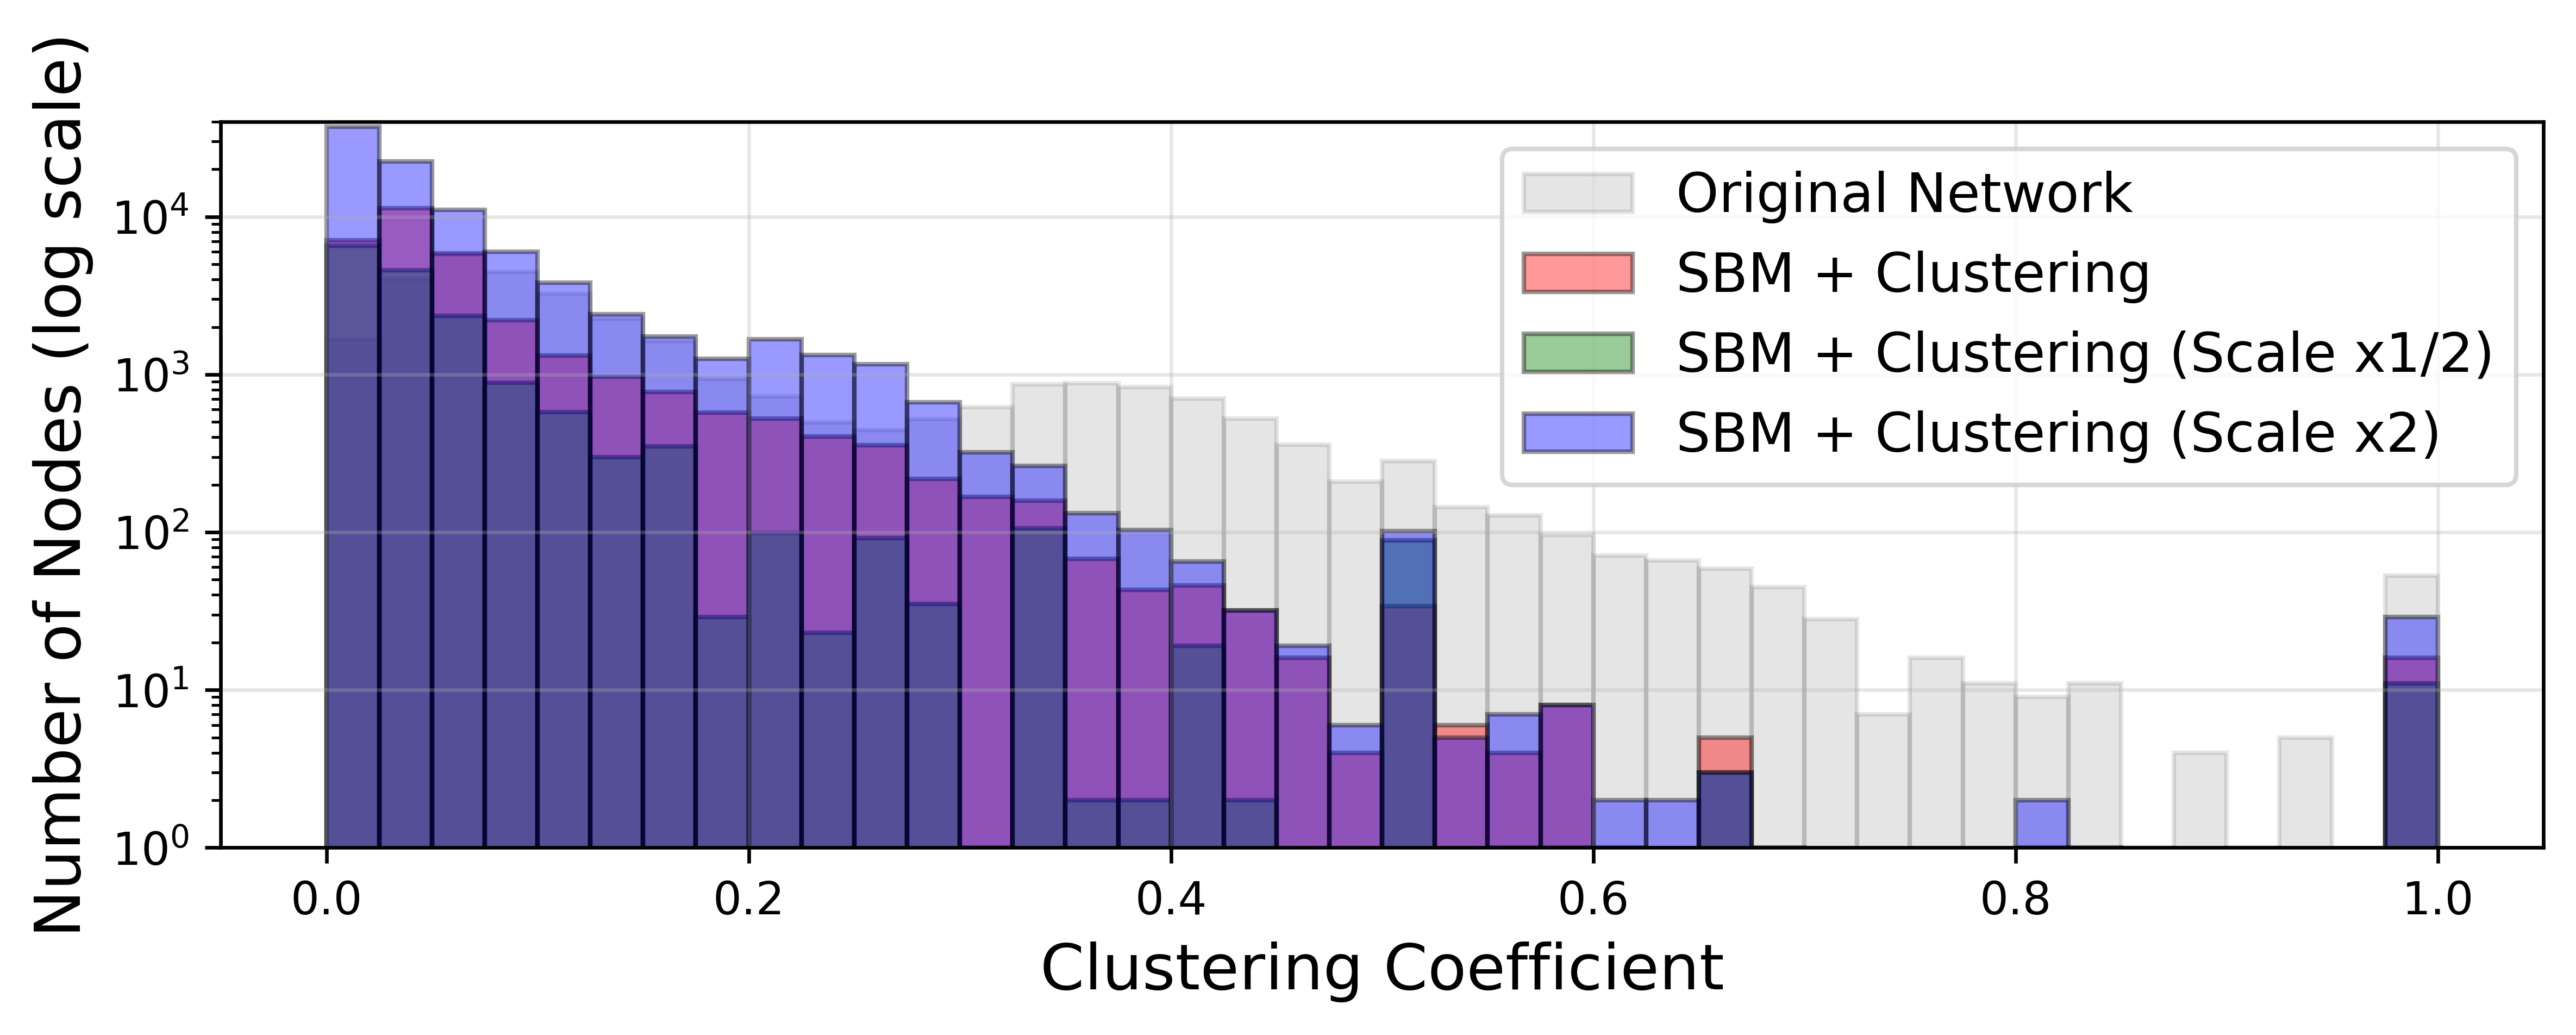

In [12]:
# Plot clustering coefficient distributions with log scale
print("Plotting clustering coefficient distributions with log scale...")
plt.figure(figsize=(8, 3), dpi=600)
bins = np.linspace(0, 1, 41)  # 40 bins from 0 to 1
for i, label in enumerate(labels):
    
    # Set linewidth to 1 for original network only, 0 for others
    alp = 0.1 if label == "Original Network" else 0.4
    
    values = clustering_data[label]
    plt.hist(
        values,
        bins=bins,
        alpha=alp,
        color=colors[i],
        edgecolor='black',
        label=f"{label}"
    )
#     # Add kernel density estimation if there are enough values
#     if len(values) > 10:
#         kde = gaussian_kde(values,bw_method=0.5)
#         x_vals = np.linspace(0, 1, 1000)
#         plt.plot(
#             x_vals,
#             kde(x_vals) * len(values) * (bins[1] - bins[0]),
#             linewidth=2,
#             color=colors[i]
#         )
plt.xlabel('Clustering Coefficient', fontsize=14)
plt.ylabel('Number of Nodes (log scale)', fontsize=14)
# plt.title('Clustering Coefficient Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylim(bottom=1, top=40000)

plt.tight_layout()
plt.savefig('plots/comparison_clustering_coefficient_.png')
print("Saved clustering coefficient distribution comparison plot with log scale")

Plotting clustering coefficient distributions with log scale...
Saved clustering coefficient distribution comparison plot with log scale


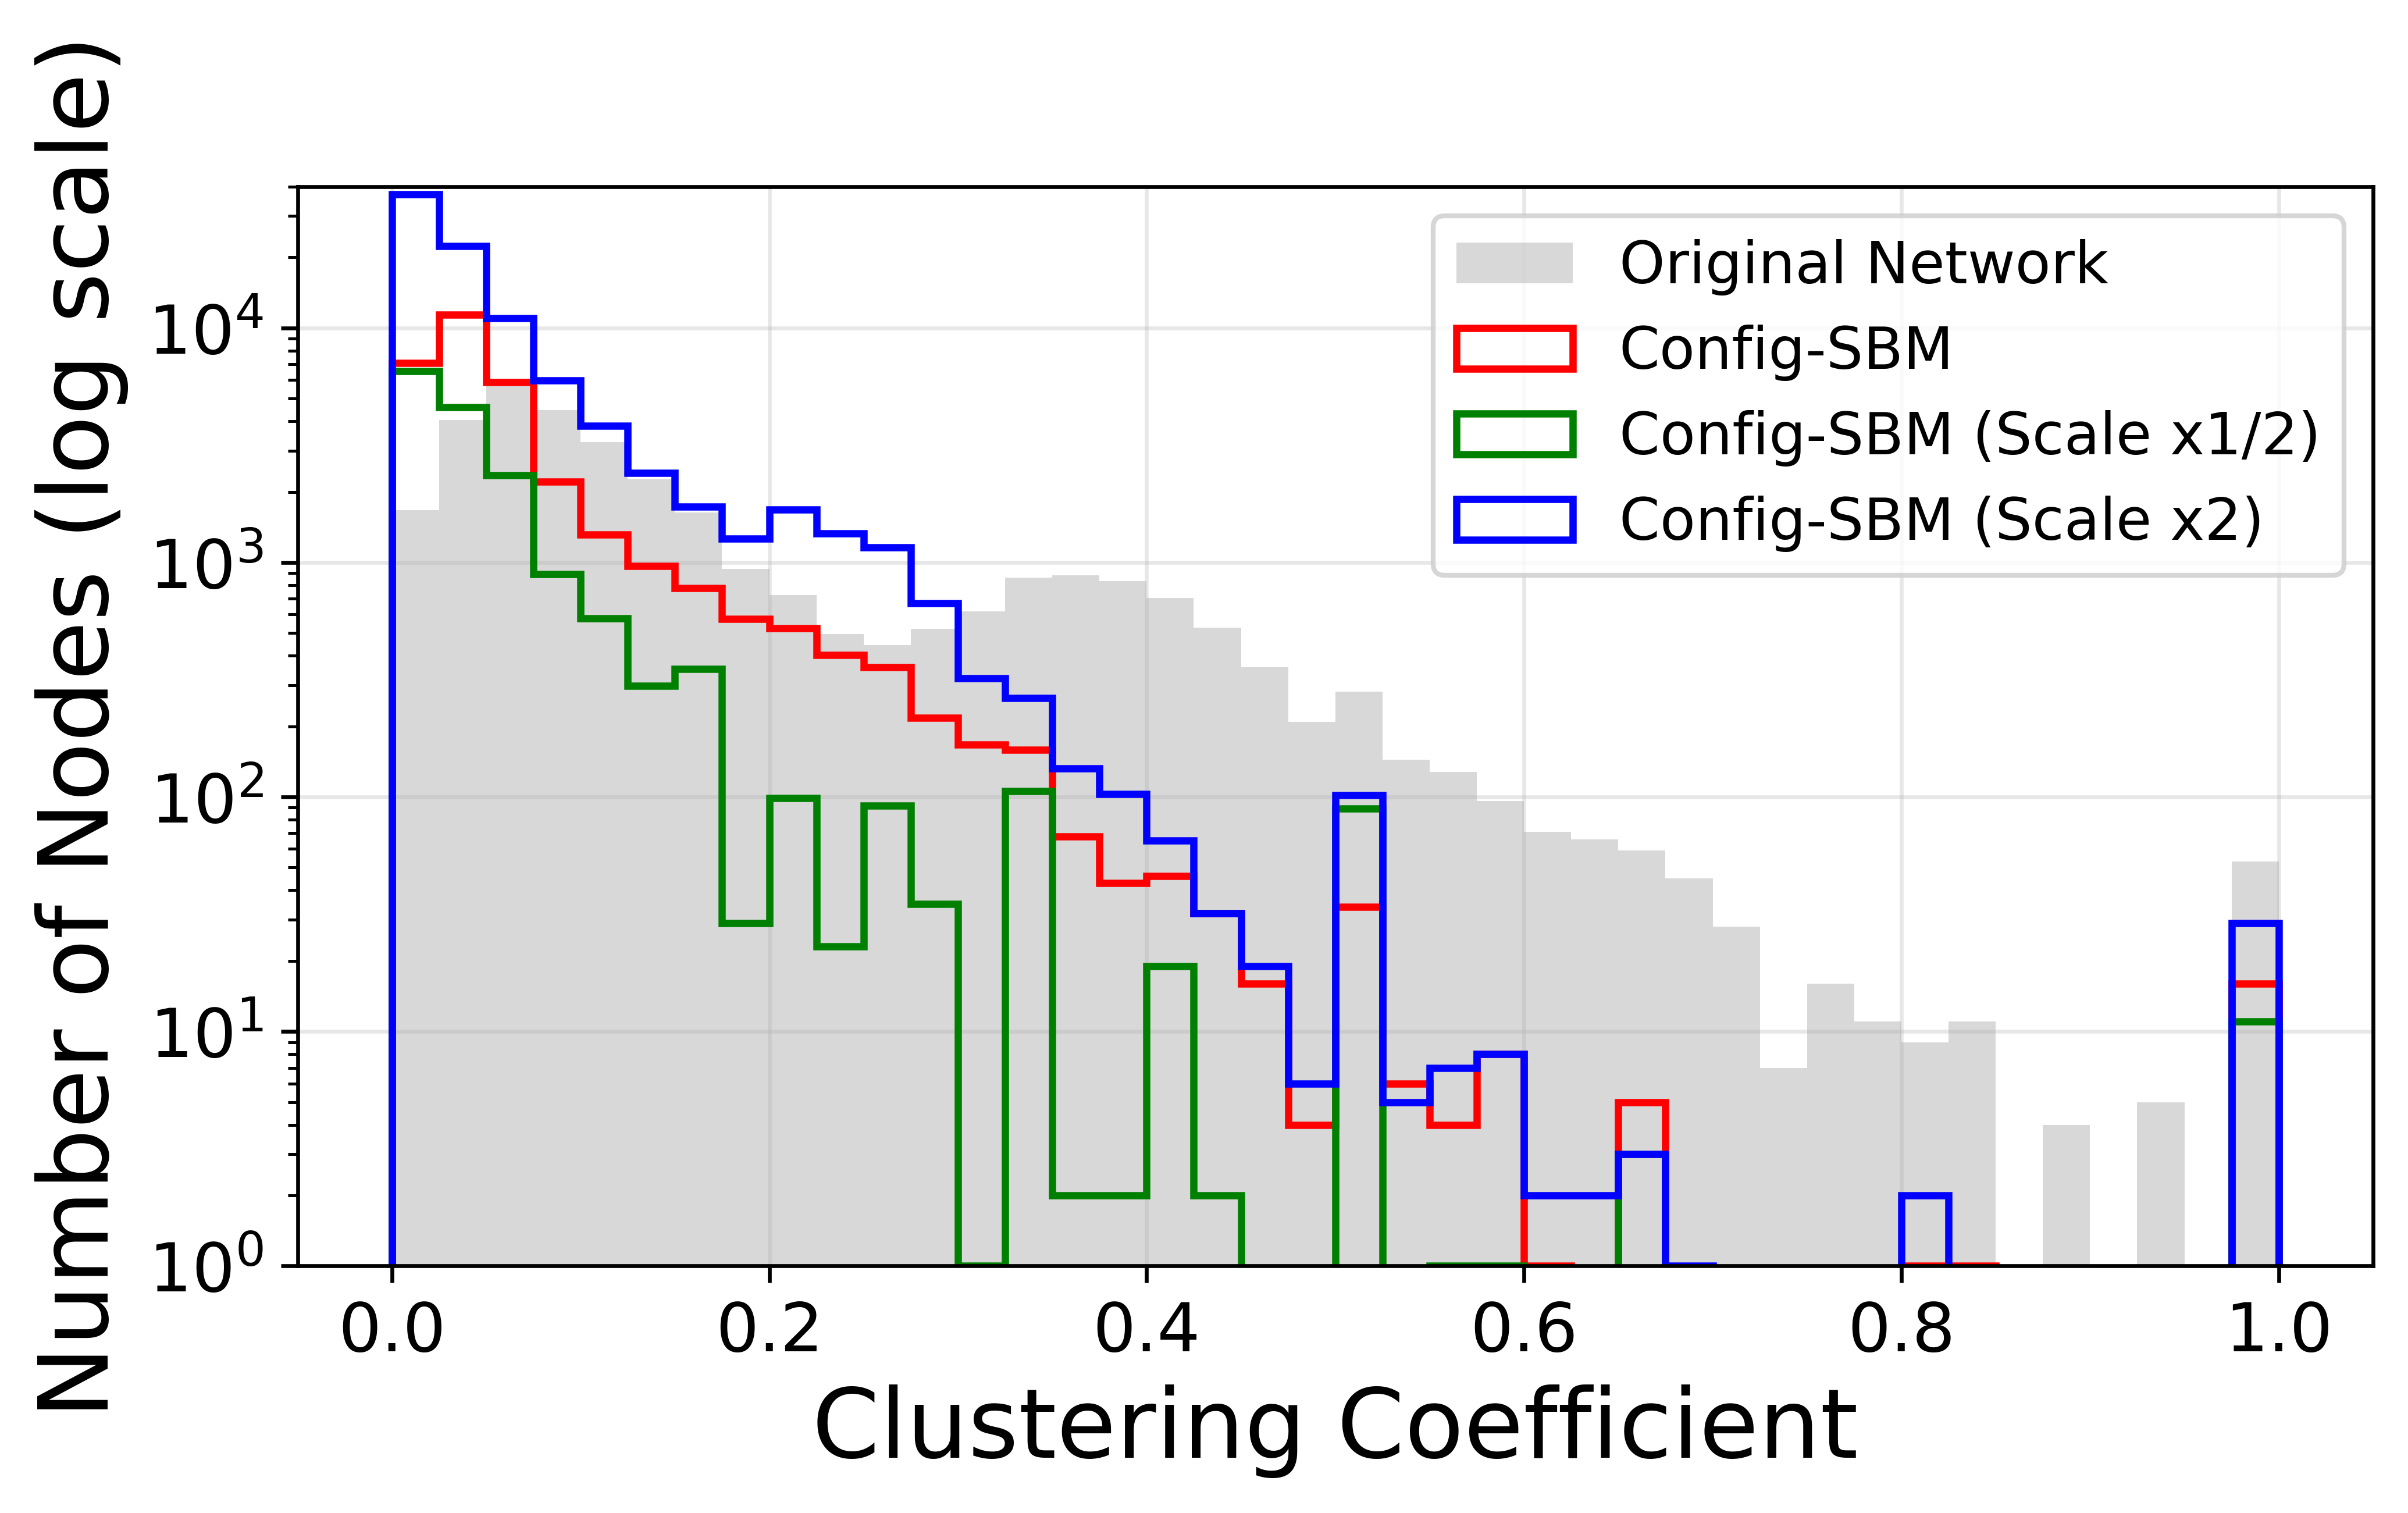

In [11]:
# Plot clustering coefficient distributions with log scale using step histograms
print("Plotting clustering coefficient distributions with log scale...")
plt.figure(figsize=(7, 4), dpi=600)
bins = np.linspace(0, 1, 41)  # 40 bins from 0 to 1

# First plot Original Network as filled histogram with grey color and opacity 0.3
original_index = labels.index("Original Network")
original_values = clustering_data["Original Network"]
plt.hist(
    original_values,
    bins=bins,
    alpha=0.3,
    color='grey',
    label=f"{labels[original_index]}",
    histtype="bar",
    linewidth=1.5
)


# Then plot the rest as step histograms
for i, label in enumerate(labels):
    if label != "Original Network":  # Skip the Original Network since we already plotted it
        values = clustering_data[label]
        plt.hist(
            values,
            bins=bins,
            alpha=1,
            color=colors[i],
            label=f"{label}",
            histtype="step",
            linewidth=1.5
        )

plt.xlabel('Clustering Coefficient', fontsize=20)
plt.ylabel('Number of Nodes (log scale)', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.ylim(bottom=1, top=40000)

plt.tight_layout()
plt.savefig('plots/comparison_clustering_coefficient_.pdf')
print("Saved clustering coefficient distribution comparison plot with log scale")


In [17]:
# Calculate and plot connection distances
print("Calculating connection distances...")
distance_data = {}

for G, label in zip(graphs, labels):
    print(f"Calculating distances for {label} network...")
    # Use all edges for the distance calculation as requested
    print(f"Processing all {G.number_of_edges()} edges for distance calculation")
    
    distances = []
    for edge in G.edges():
        distance = calculate_euclidean_distance(G, edge)
        if distance is not None:
            distances.append(distance)
    
    distance_data[label] = distances
    print(f"{label} network: {len(distances)} distances calculated, avg = {np.mean(distances):.4f}")



Calculating connection distances...
Calculating distances for Original Network network...
Processing all 849981 edges for distance calculation
Original Network network: 849981 distances calculated, avg = 118124.9203
Calculating distances for Config-SBM network...
Processing all 812313 edges for distance calculation
Config-SBM network: 812313 distances calculated, avg = 126819.8412
Calculating distances for Config-SBM (Scale x1/2) network...
Processing all 201983 edges for distance calculation
Config-SBM (Scale x1/2) network: 201983 distances calculated, avg = 126408.6733
Calculating distances for Config-SBM (Scale x2) network...
Processing all 2513640 edges for distance calculation
Config-SBM (Scale x2) network: 1465064 distances calculated, avg = 118823.6728


Plotting connection distance distributions...
Saved connection length distribution comparison plot


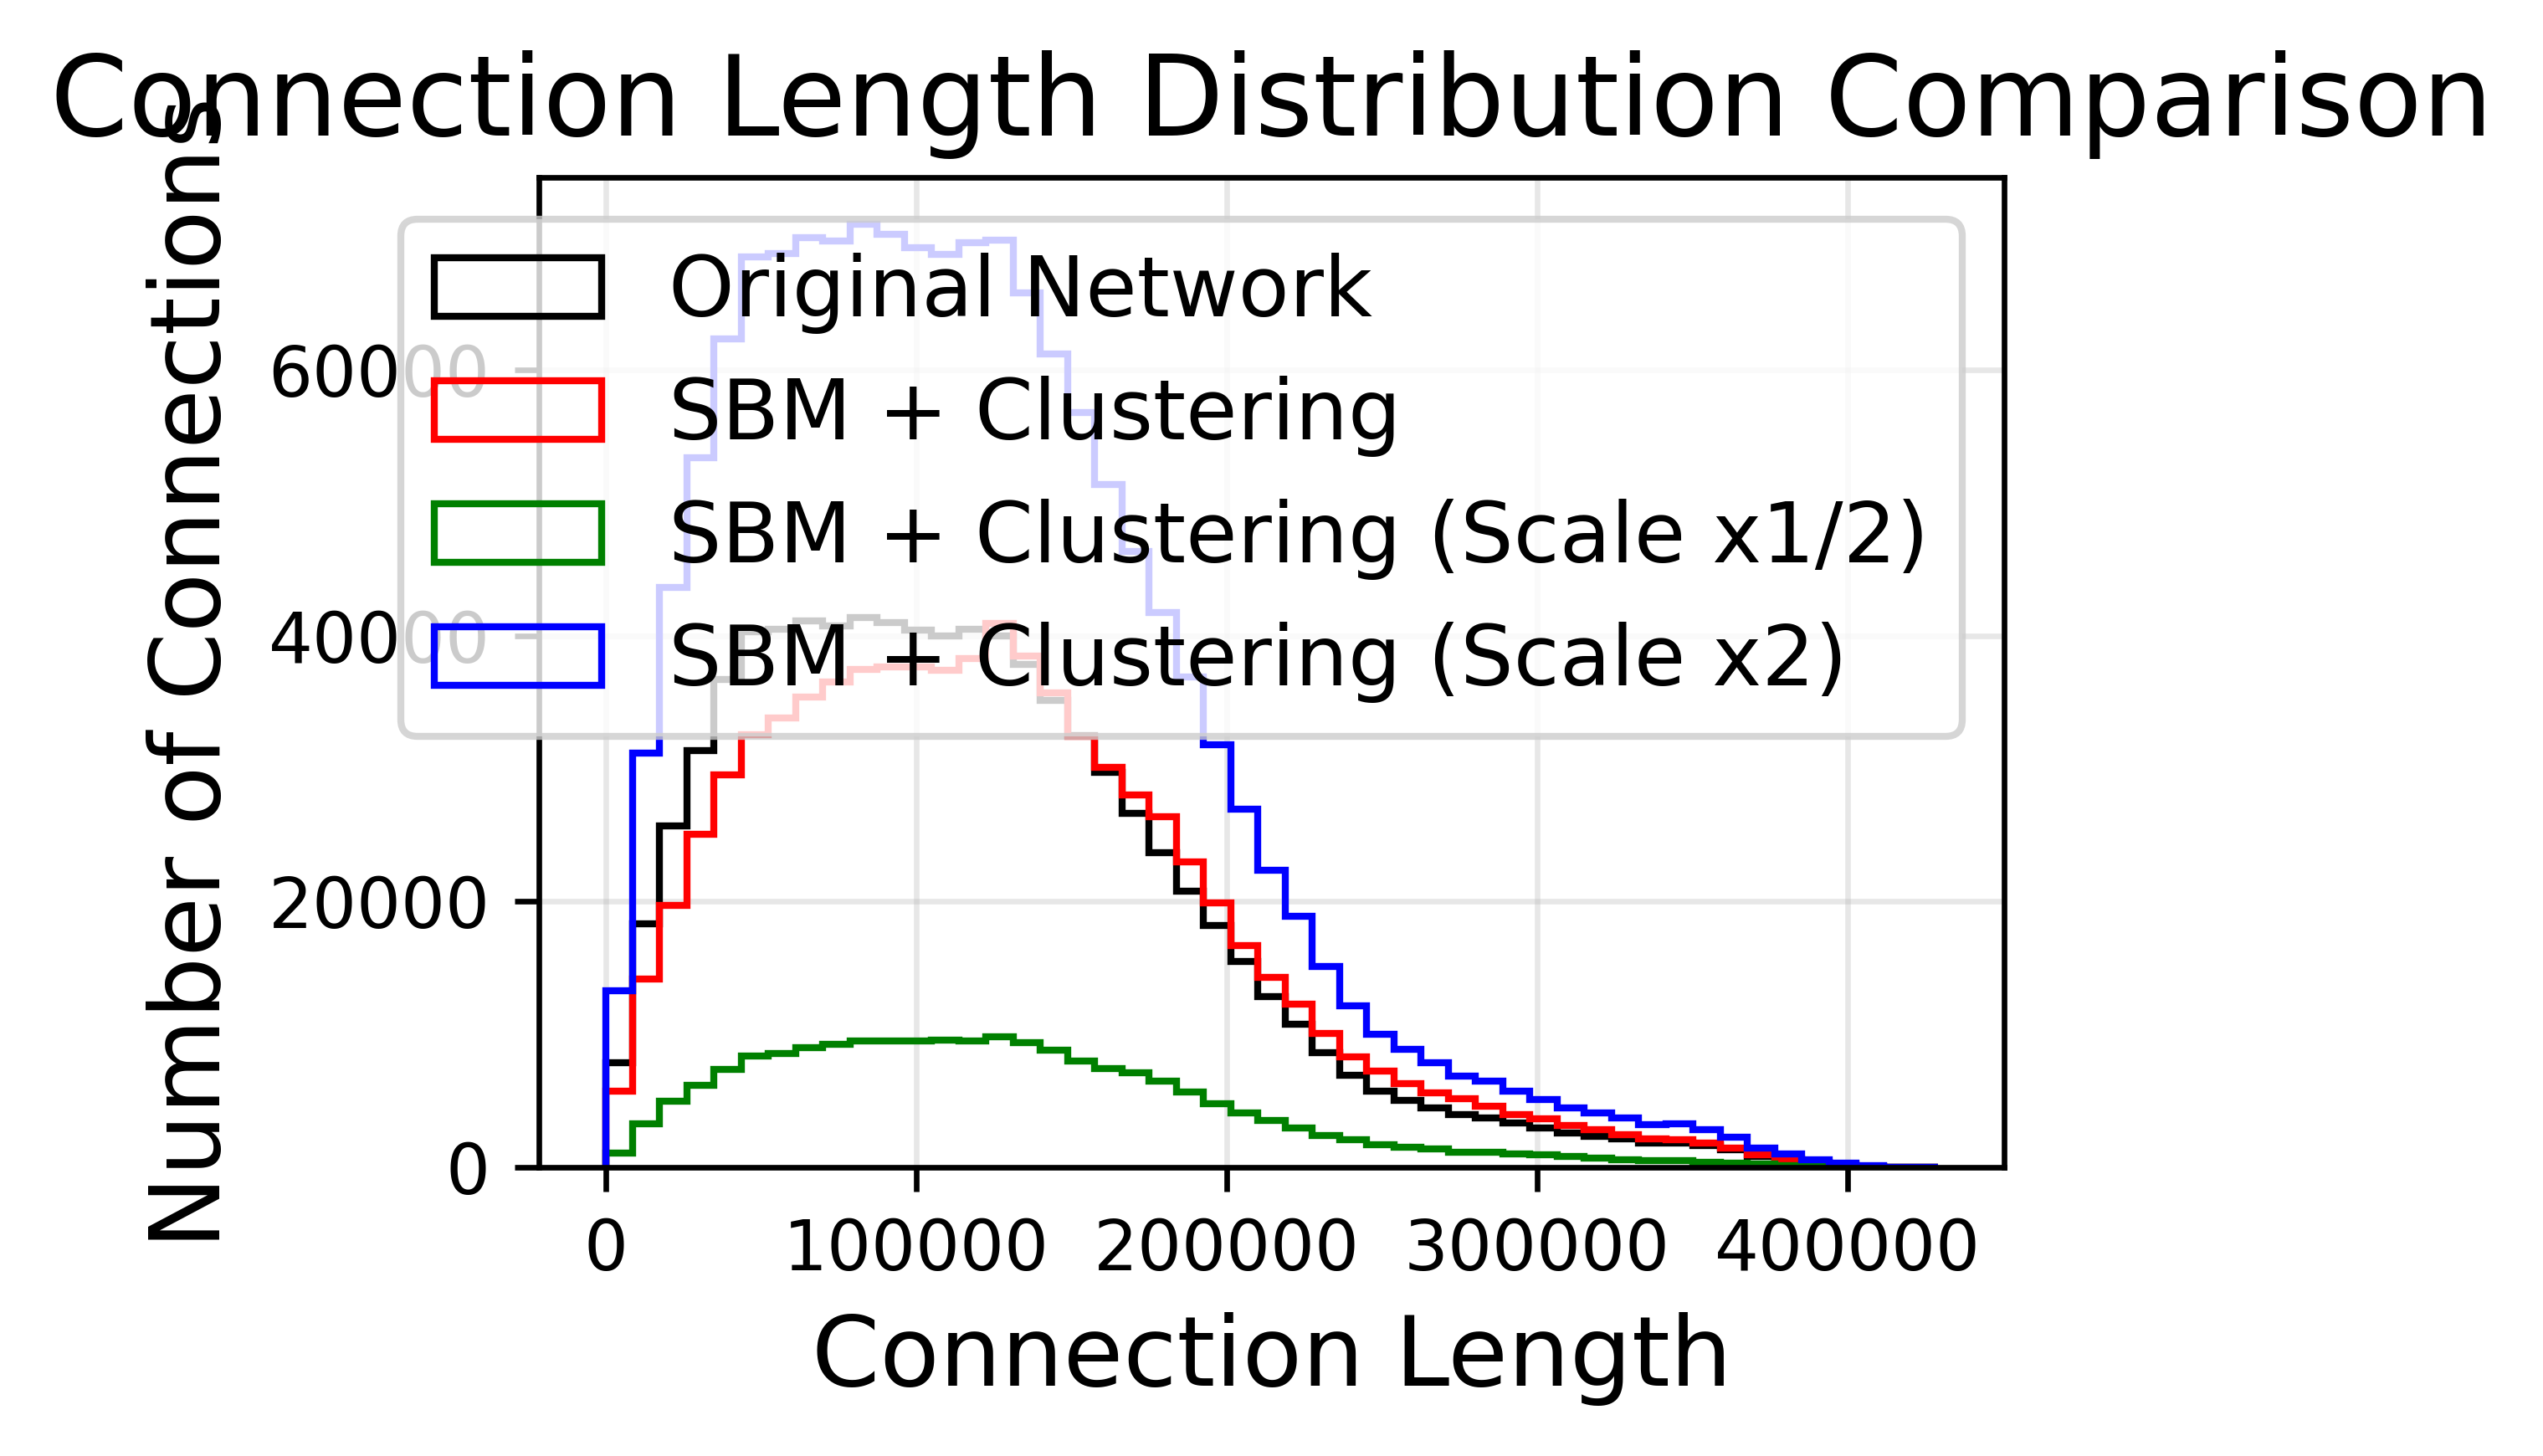

In [15]:
# Plot connection distance distributions
print("Plotting connection distance distributions...")
plt.figure(figsize=(4, 3),dpi=600)

max_distance = max([max(distances) for distances in distance_data.values() if distances])
bins = np.linspace(0, max_distance, 50)

for i, label in enumerate(labels):
    distances = distance_data[label]
    if distances:
        plt.hist(
            distances,
            bins=bins,
            alpha=1,
            histtype="step",
            color=colors[i],
            edgecolor=colors[i],
            label=f"{label}"
        )

plt.xlabel('Connection Length', fontsize=14)
plt.ylabel('Number of Connections', fontsize=14)
plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length.png', dpi=600)
print("Saved connection length distribution comparison plot")


Plotting connection distance distributions in micrometers...
Saved connection length distribution comparison plot


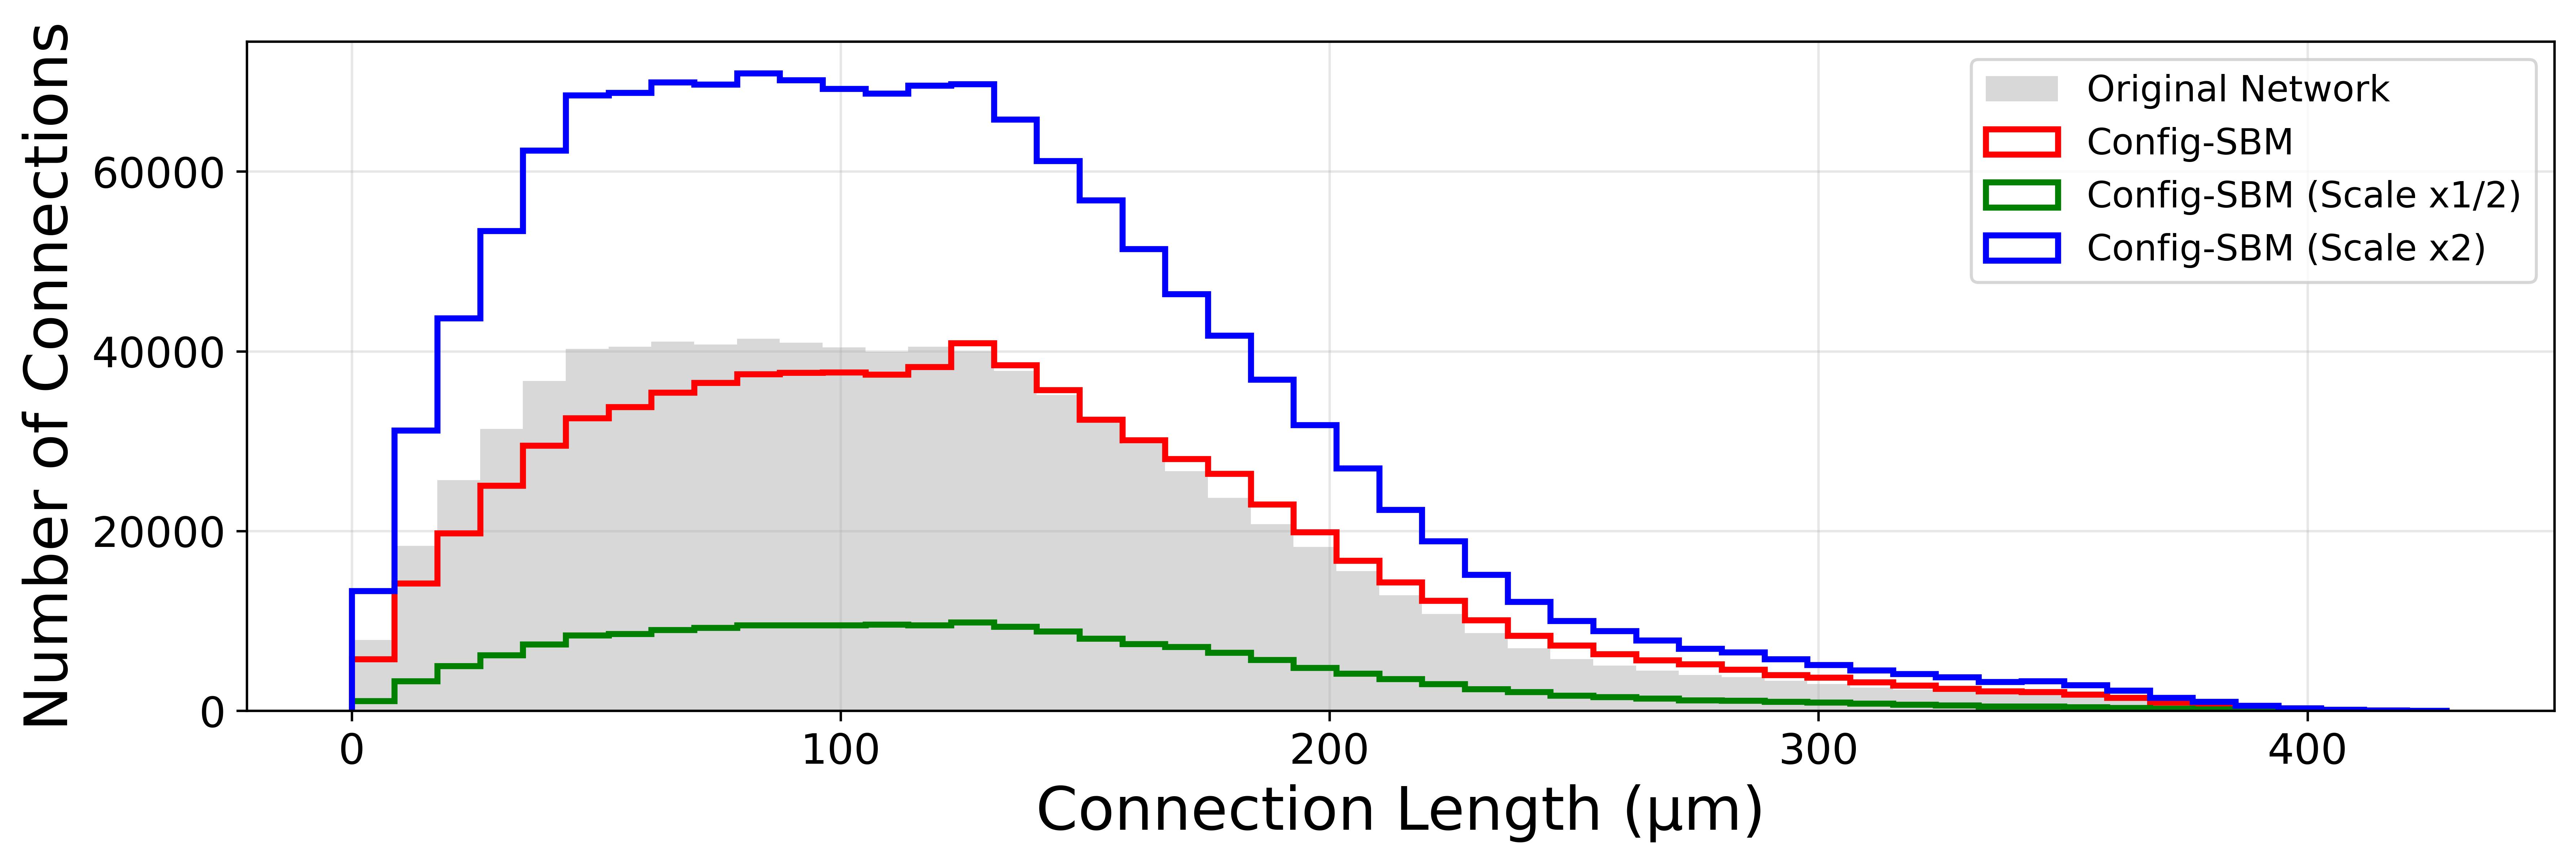

In [19]:
# Plot connection distance distributions (converted from nm to µm)
print("Plotting connection distance distributions in micrometers...")
plt.figure(figsize=(12, 4), dpi=600)

# Calculate the maximum distance in nanometers, then convert to micrometers
max_distance_nm = max([max(distances) for distances in distance_data.values() if distances])
max_distance_um = max_distance_nm / 1000.0

# Create bins in micrometers
bins = np.linspace(0, max_distance_um, 50)

# First plot Original Network as filled histogram with grey color and opacity 0.3
original_index = labels.index("Original Network")
original_disances = distance_data["Original Network"]
original_disances_um = [d / 1000.0 for d in original_disances]

plt.hist(
    original_disances_um,
    bins=bins,
    alpha=0.3,
    color='grey',
    label=f"{labels[original_index]}",
    histtype="bar",
    linewidth=1.5
)


for i, label in enumerate(labels):
    if label != "Original Network":  # Skip the Original Network since we already plotted it
        distances = distance_data[label]
        if distances:
            # Convert the distances from nanometers to micrometers
            distances_um = [d / 1000.0 for d in distances]
            plt.hist(
                distances_um,
                bins=bins,
                alpha=1,
                histtype="step",
                color=colors[i],
                edgecolor=colors[i],
                label=f"{label}",
                linewidth=2
            )

plt.xlabel('Connection Length (µm)', fontsize=20)
plt.ylabel('Number of Connections', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size

# plt.title('Connection Length Distribution Comparison', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/comparison_connection_length.pdf', dpi=600)
print("Saved connection length distribution comparison plot")


Plotting clustering coefficient distributions...


ValueError: x and y must be the same size

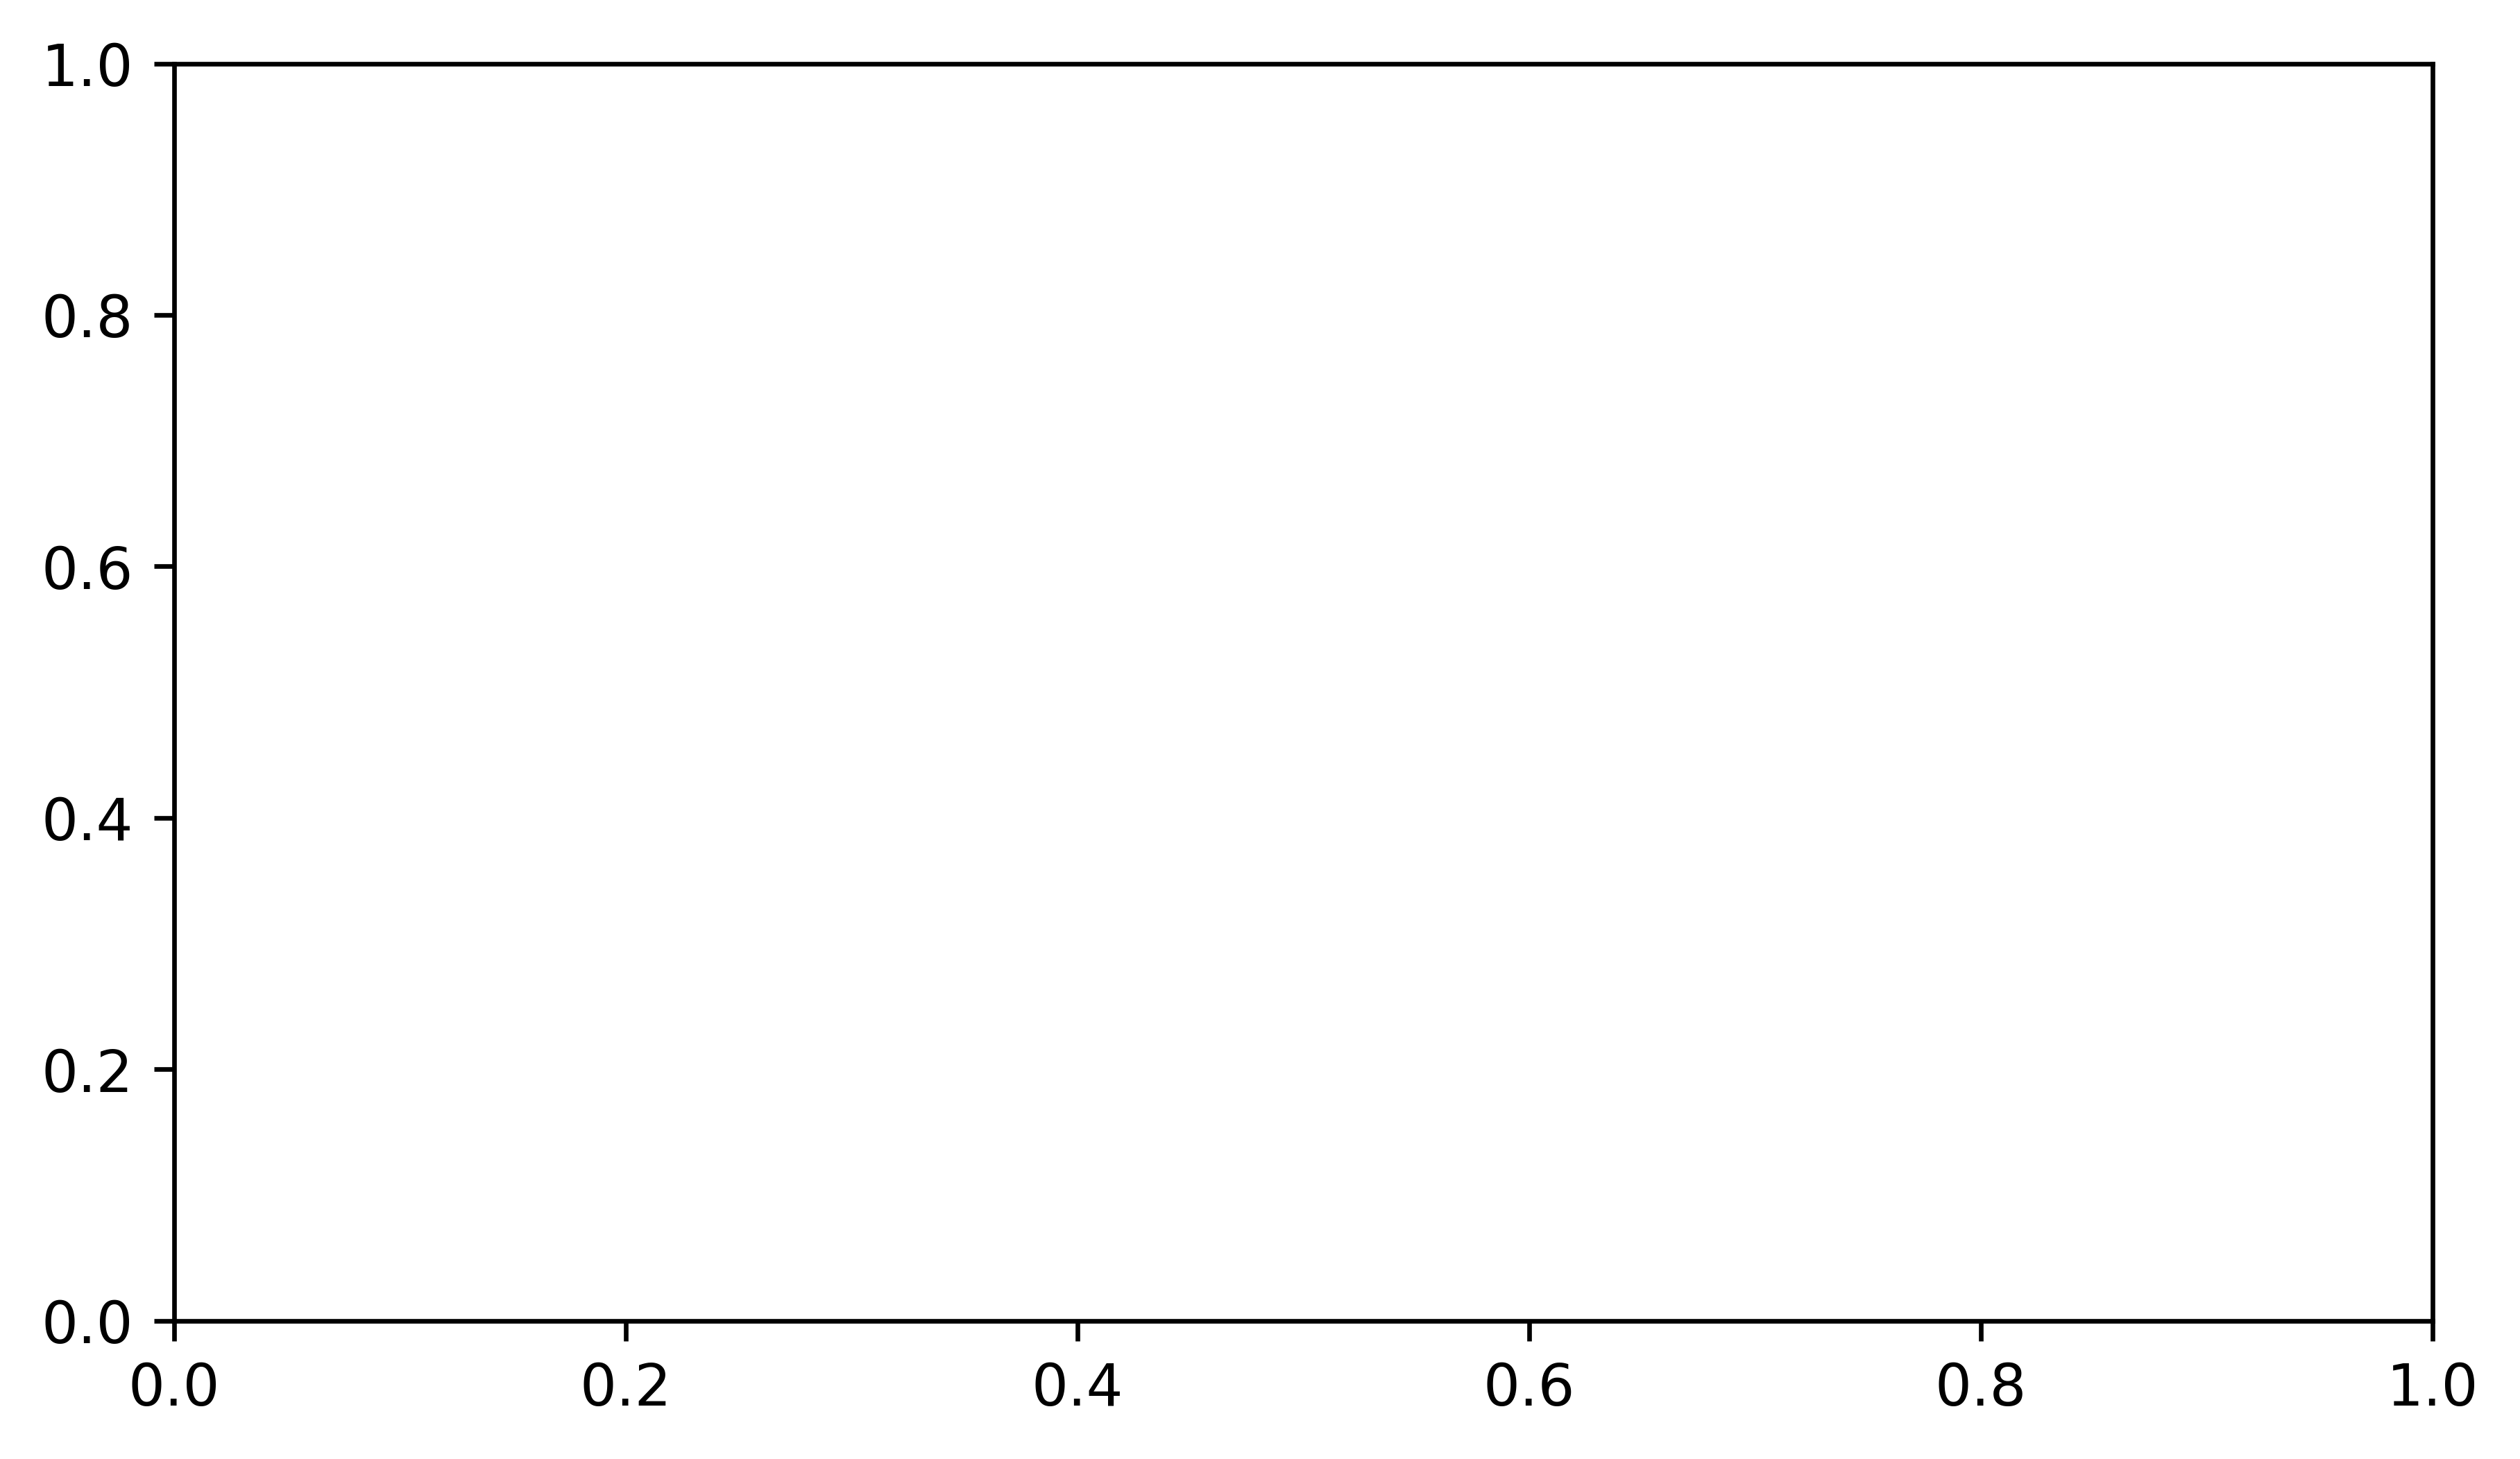

Creating combined scatter plot of degree vs clustering coefficient...
Saved combined degree vs clustering scatter plot


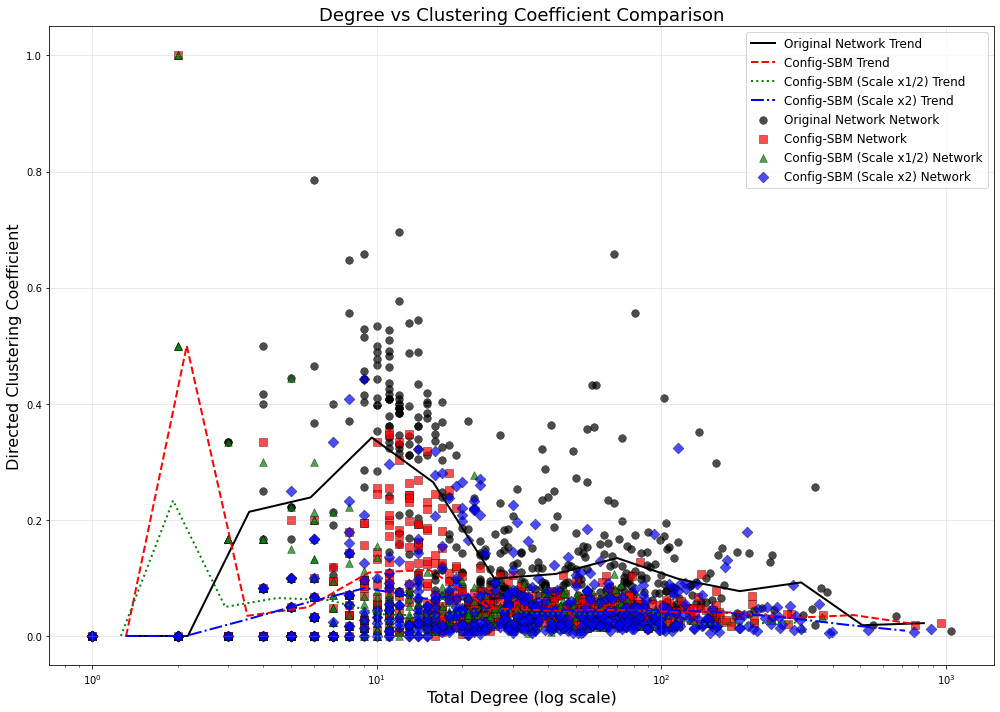

In [24]:
# Create a combined scatter plot with different colors and shapes for each network
print("Creating combined scatter plot of degree vs clustering coefficient...")

plt.figure(figsize=(14, 10))

# Define markers for each network to differentiate them
markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

for i, (G, label) in enumerate(zip(graphs, labels)):
    # Calculate total degree for each node
    total_degrees = {node: G.in_degree(node) + G.out_degree(node) for node in G.nodes()}
    
    # Calculate directed clustering for this graph if not already done
    if label not in clustering_data or len(clustering_data[label]) == 0:
        if G.number_of_nodes() > 1000:
            sample_nodes = random.sample(list(G.nodes()), 1000)
            subgraph = G.subgraph(sample_nodes)
            clustering = directed_clustering_coefficient(subgraph)
        else:
            clustering = directed_clustering_coefficient(G)
        clustering_data[label] = clustering
    else:
        clustering = clustering_data[label]
    
    # Get degrees and clustering coefficients
    degrees = []
    cc_values = []
    
    # Sample nodes to avoid overcrowding
    sample_size = min(500, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), sample_size)
    
    for node in sample_nodes:
        if isinstance(clustering, dict) and node in clustering:
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node])
        elif isinstance(clustering, list) and len(clustering) == G.number_of_nodes():
            node_idx = list(G.nodes()).index(node)
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node_idx])
    
    # Create scatter plot with different marker for each network
    plt.scatter(
        degrees, 
        cc_values, 
        alpha=0.7, 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=60,  # Marker size
        edgecolor='black',
        linewidth=0.5,
        label=f"{label} Network"
    )
    
    # Add trend line using binned statistics
    from scipy.stats import binned_statistic
    
    if len(degrees) > 10:  # Only create trend line if we have enough data points
        # Create logarithmic bins
        bins = np.logspace(np.log10(max(1, min(degrees))), np.log10(max(degrees)), 15)
        bin_means, bin_edges, _ = binned_statistic(degrees, cc_values, statistic='mean', bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Remove NaN values that might appear in some bins
        valid_idx = ~np.isnan(bin_means)
        bin_centers = bin_centers[valid_idx]
        bin_means = bin_means[valid_idx]
        
        # Plot trend line with same color but different line style for each network
        line_styles = ['-', '--', ':', '-.']
        plt.plot(
            bin_centers, 
            bin_means, 
            color=colors[i], 
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2, 
            label=f"{label} Trend"
        )

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=16)
plt.ylabel('Directed Clustering Coefficient', fontsize=16)
plt.title('Degree vs Clustering Coefficient Comparison', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('plots/combined_degree_vs_clustering.png', dpi=600)
print("Saved combined degree vs clustering scatter plot")

Creating improved scatter plot of degree vs clustering coefficient...


No handles with labels found to put in legend.
No handles with labels found to put in legend.


Saved improved degree vs clustering visualization


KeyError: 29512

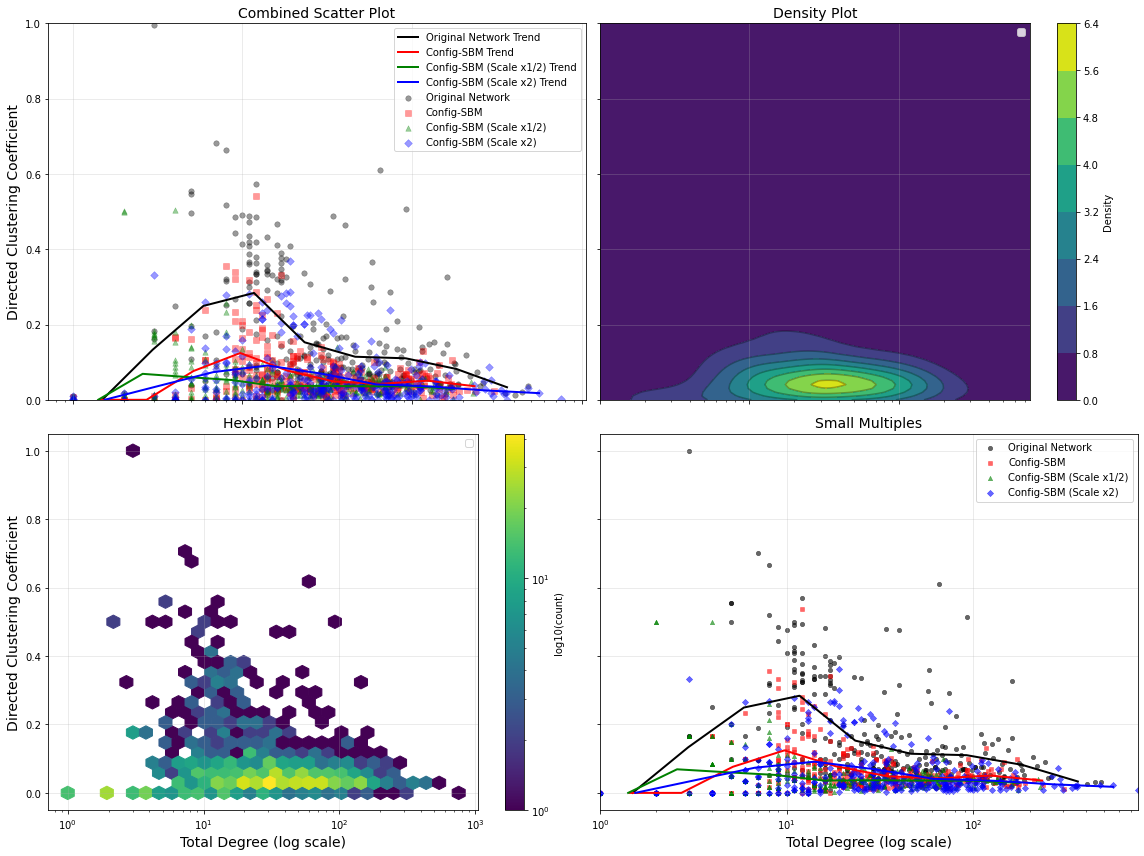

<Figure size 864x576 with 0 Axes>

In [27]:
# Create an improved combined scatter plot with better visibility for overlapping points
print("Creating improved scatter plot of degree vs clustering coefficient...")

import matplotlib.cm as cm
from scipy.stats import gaussian_kde

# Create subplots - 2x2 grid for individual plots and density plot
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='row')
axs = axs.flatten()

# Main subplot for combined scatter with smaller alpha and markers
ax_combined = axs[0]

# Individual scatter subplots
ax_density = axs[1]  # For 2D density plot
ax_hexbin = axs[2]   # For hexbin plot
ax_individual = axs[3]  # For small multiples

# Define markers for each network to differentiate them
markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

# Store all data for density plot
all_degrees = []
all_cc_values = []
all_networks = []

# Create the individual plots first
for i, (G, label) in enumerate(zip(graphs, labels)):
    # Calculate total degree for each node
    total_degrees = {node: G.in_degree(node) + G.out_degree(node) for node in G.nodes()}
    
    # Calculate directed clustering for this graph if not already done
    if label not in clustering_data or len(clustering_data[label]) == 0:
        if G.number_of_nodes() > 1000:
            sample_nodes = random.sample(list(G.nodes()), 1000)
            subgraph = G.subgraph(sample_nodes)
            clustering = directed_clustering_coefficient(subgraph)
        else:
            clustering = directed_clustering_coefficient(G)
        clustering_data[label] = clustering
    else:
        clustering = clustering_data[label]
    
    # Get degrees and clustering coefficients
    degrees = []
    cc_values = []
    
    # Sample nodes to avoid overcrowding
    sample_size = min(300, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), sample_size)
    
    for node in sample_nodes:
        if isinstance(clustering, dict) and node in clustering:
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node])
        elif isinstance(clustering, list) and len(clustering) == G.number_of_nodes():
            node_idx = list(G.nodes()).index(node)
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node_idx])
    
    # Store data for density plot (ensuring all degrees are positive)
    positive_indices = [j for j, d in enumerate(degrees) if d > 0]
    all_degrees.extend([degrees[j] for j in positive_indices])
    all_cc_values.extend([cc_values[j] for j in positive_indices])
    all_networks.extend([i] * len(positive_indices))
    
    # Add jitter to reduce exact overlaps
    jitter = np.random.normal(0, 0.01, len(cc_values))
    cc_values_jittered = [max(0, min(1, v + j)) for v, j in zip(cc_values, jitter)]
    
    # Plot on the combined scatter (first subplot)
    ax_combined.scatter(
        degrees, 
        cc_values_jittered, 
        alpha=0.4,  # More transparent 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=30,  # Smaller marker size
        linewidth=0.5,
        label=f"{label}"
    )
    
    # Plot on the individual small multiples (last subplot)
    ax_individual.scatter(
        degrees, 
        cc_values, 
        alpha=0.6, 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=20,
        linewidth=0.5,
        label=f"{label}"
    )
    
    # Add trend line using binned statistics
    from scipy.stats import binned_statistic
    
    if len(degrees) > 10:  # Only create trend line if we have enough data points
        # Filter out non-positive degrees for logarithmic binning
        pos_degrees = [d for d in degrees if d > 0]
        if len(pos_degrees) > 10:  # Only create trend line if we have enough positive values
            # Create logarithmic bins
            bins = np.logspace(np.log10(min(pos_degrees)), np.log10(max(pos_degrees)), 10)
            
            # Filter paired data
            pos_indices = [j for j, d in enumerate(degrees) if d > 0]
            filtered_degrees = [degrees[j] for j in pos_indices]
            filtered_cc = [cc_values[j] for j in pos_indices]
            
            bin_means, bin_edges, _ = binned_statistic(filtered_degrees, filtered_cc, statistic='mean', bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Remove NaN values that might appear in some bins
            valid_idx = ~np.isnan(bin_means)
            bin_centers = bin_centers[valid_idx]
            bin_means = bin_means[valid_idx]
            
            # Plot trend line on both plots
            ax_combined.plot(
                bin_centers, 
                bin_means, 
                color=colors[i], 
                linewidth=2, 
                label=f"{label} Trend"
            )
            
            ax_individual.plot(
                bin_centers, 
                bin_means, 
                color=colors[i], 
                linewidth=2
            )

# Create hexbin plot (third subplot) - make sure to filter out non-positive values
if all_degrees:
    # Filter out any remaining non-positive values
    positive_indices = [i for i, d in enumerate(all_degrees) if d > 0]
    hex_degrees = [all_degrees[i] for i in positive_indices]
    hex_cc_values = [all_cc_values[i] for i in positive_indices]
    
    if len(hex_degrees) > 10:  # Only create hexbin if we have enough data points
        try:
            hb = ax_hexbin.hexbin(
                hex_degrees, 
                hex_cc_values, 
                gridsize=30, 
                bins='log',
                xscale='log',
                cmap='viridis',
                mincnt=1
            )
            fig.colorbar(hb, ax=ax_hexbin, label='log10(count)')
        except Exception as e:
            print(f"Warning: Error creating hexbin plot: {e}")
            # Fallback to scatter plot
            ax_hexbin.scatter(hex_degrees, hex_cc_values, alpha=0.3, c='gray', s=10)
            
    # Add network-specific trend lines to hexbin plot
    for i, (G, label) in enumerate(zip(graphs, labels)):
        degrees = []
        cc_values = []
        
        for node in G.nodes():
            if isinstance(clustering_data[label], dict) and node in clustering_data[label]:
                deg = total_degrees[node]
                if deg > 0:  # Filter out non-positive values
                    degrees.append(deg)
                    cc_values.append(clustering_data[label][node])
        
        if len(degrees) > 10:
            bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 10)
            bin_means, bin_edges, _ = binned_statistic(degrees, cc_values, statistic='mean', bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            valid_idx = ~np.isnan(bin_means)
            ax_hexbin.plot(
                bin_centers[valid_idx], 
                bin_means[valid_idx], 
                color=colors[i], 
                linewidth=3, 
                label=f"{label}"
            )

# Create 2D density plot (second subplot)
if len(all_degrees) > 10:
    # Convert to numpy arrays for KDE
    x = np.array(all_degrees)
    y = np.array(all_cc_values)
    
    # Create a logarithmic grid for density estimation (ensuring all values are positive)
    xi = np.logspace(np.log10(min(x)), np.log10(max(x)), 100)
    yi = np.linspace(0, 1, 100)
    
    # Create meshgrid
    Xi, Yi = np.meshgrid(xi, yi)
    
    try:
        # Calculate KDE with logarithmic x values
        x_log = np.log10(x)
        positions = np.vstack([np.log10(Xi).ravel(), Yi.ravel()])
        kernel = gaussian_kde(np.vstack([x_log, y]))
        Z = np.reshape(kernel(positions).T, Xi.shape)
        
        # Plot density
        cfset = ax_density.contourf(Xi, Yi, Z, cmap='viridis')
        cset = ax_density.contour(Xi, Yi, Z, colors='k', alpha=0.3)
        fig.colorbar(cfset, ax=ax_density, label='Density')
        
        # Add trend lines for each network
        for i, (G, label) in enumerate(zip(graphs, labels)):
            degrees = []
            cc_values = []
            
            for node in G.nodes():
                if isinstance(clustering_data[label], dict) and node in clustering_data[label]:
                    deg = total_degrees[node]
                    if deg > 0:
                        degrees.append(deg)
                        cc_values.append(clustering_data[label][node])
            
            if len(degrees) > 10:
                bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 10)
                bin_means, bin_edges, _ = binned_statistic(degrees, cc_values, statistic='mean', bins=bins)
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                valid_idx = ~np.isnan(bin_means)
                ax_density.plot(
                    bin_centers[valid_idx], 
                    bin_means[valid_idx], 
                    color=colors[i], 
                    linewidth=3, 
                    label=f"{label}"
                )
    except Exception as e:
        print(f"Warning: Could not create density plot: {e}")
        # Fallback to scatter plot if density estimation fails
        for i, (G, label) in enumerate(zip(graphs, labels)):
            degrees = []
            cc_values = []
            
            for node in G.nodes():
                if isinstance(clustering_data[label], dict) and node in clustering_data[label]:
                    deg = total_degrees[node]
                    if deg > 0:
                        degrees.append(deg)
                        cc_values.append(clustering_data[label][node])
            
            ax_density.scatter(
                degrees, 
                cc_values, 
                alpha=0.3, 
                color=colors[i], 
                s=10,
                label=f"{label}"
            )

# Set log scale and labels for all subplots
for ax in axs:
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

# Set subplot titles
ax_combined.set_title('Combined Scatter Plot', fontsize=14)
ax_density.set_title('Density Plot', fontsize=14)
ax_hexbin.set_title('Hexbin Plot', fontsize=14)
ax_individual.set_title('Small Multiples', fontsize=14)

# Set x and y labels only on the bottom and left subplots
axs[2].set_xlabel('Total Degree (log scale)', fontsize=14)
axs[3].set_xlabel('Total Degree (log scale)', fontsize=14)
axs[0].set_ylabel('Directed Clustering Coefficient', fontsize=14)
axs[2].set_ylabel('Directed Clustering Coefficient', fontsize=14)

# Add legends to appropriate subplots
ax_combined.legend(fontsize=10, loc='best')
ax_hexbin.legend(fontsize=10, loc='best')
ax_individual.legend(fontsize=10, loc='best')
ax_density.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig('plots/improved_degree_vs_clustering.png', dpi=600)
print("Saved improved degree vs clustering visualization")

# Also create a single, simplified but clearer scatter plot
plt.figure(figsize=(12, 8))

for i, (G, label) in enumerate(zip(graphs, labels)):
    degrees = []
    cc_values = []
    
    # Sample fewer points per network
    sample_size = min(200, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), sample_size)
    
    for node in sample_nodes:
        if isinstance(clustering_data[label], dict) and node in clustering_data[label]:
            deg = total_degrees[node]
            if deg > 0:  # Filter out non-positive degrees
                degrees.append(deg)
                cc_values.append(clustering_data[label][node])
        elif isinstance(clustering_data[label], list) and len(clustering_data[label]) == G.number_of_nodes():
            node_idx = list(G.nodes()).index(node)
            deg = total_degrees[node]
            if deg > 0:  # Filter out non-positive degrees
                degrees.append(deg)
                cc_values.append(clustering_data[label][node_idx])
    
    # Add mild jitter to clustering values to reduce exact overlaps
    jitter = np.random.normal(0, 0.005, len(cc_values))
    cc_values_jittered = [max(0, min(1, v + j)) for v, j in zip(cc_values, jitter)]
    
    # Use different marker sizes based on network to help differentiation
    sizes = [40, 35, 30, 25]
    
    plt.scatter(
        degrees, 
        cc_values_jittered, 
        alpha=0.6, 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=sizes[i % len(sizes)],
        edgecolor='white',
        linewidth=0.5,
        label=f"{label}"
    )
    
    # Add trend line with clearer visibility
    if len(degrees) > 10:
        bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 8)
        bin_means, bin_edges, _ = binned_statistic(degrees, cc_values, statistic='mean', bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        valid_idx = ~np.isnan(bin_means)
        plt.plot(
            bin_centers[valid_idx], 
            bin_means[valid_idx], 
            color=colors[i], 
            linewidth=3, 
            label=f"{label} Trend"
        )

plt.xscale('log')
plt.xlabel('Total Degree (log scale)', fontsize=16)
plt.ylabel('Directed Clustering Coefficient', fontsize=16)
plt.title('Degree vs Clustering Coefficient by Network Type', fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('plots/simplified_degree_vs_clustering.png', dpi=600)
print("Saved simplified degree vs clustering scatter plot")

Creating scatter plot of degree vs clustering coefficient...
Saved degree vs clustering visualization at 600dpi


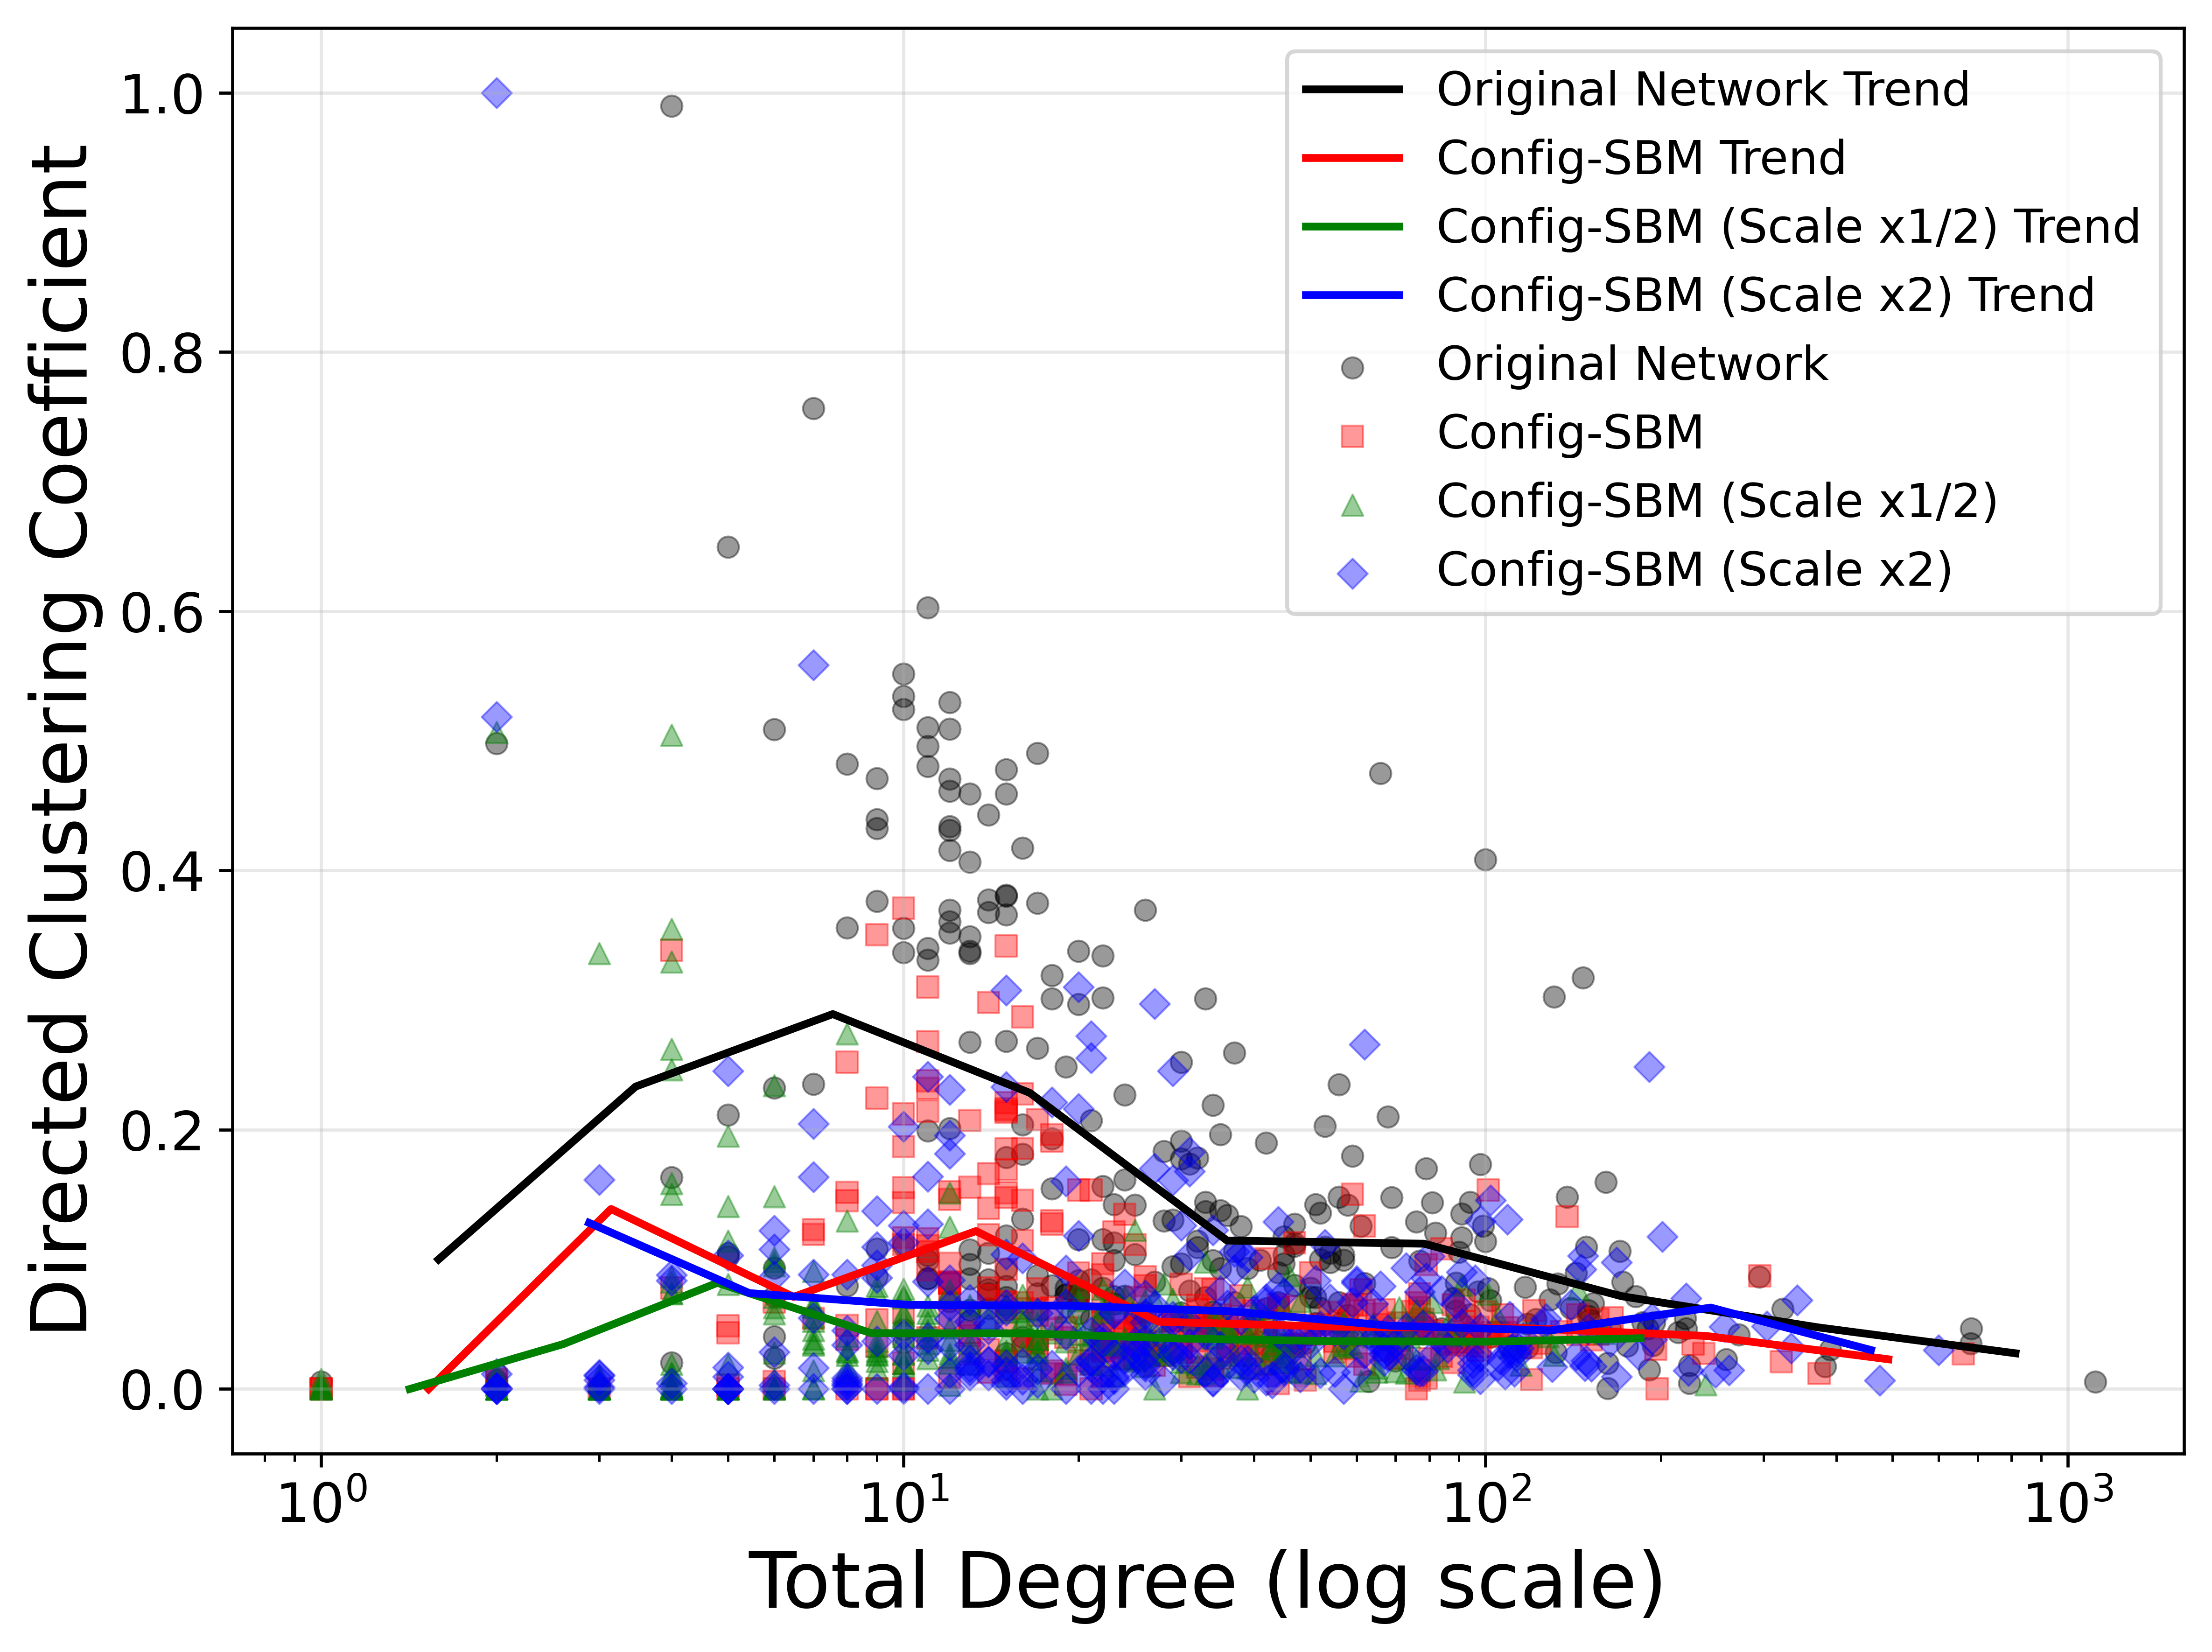

In [31]:
# Create a combined scatter plot of degree vs clustering coefficient
print("Creating scatter plot of degree vs clustering coefficient...")

import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import binned_statistic

# Create figure for combined scatter plot
plt.figure(figsize=(8, 6),dpi=600)

# Define markers for each network to differentiate them
markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

for i, (G, label) in enumerate(zip(graphs, labels)):
    # Calculate total degree for each node
    total_degrees = {node: G.in_degree(node) + G.out_degree(node) for node in G.nodes()}
    
    # Calculate directed clustering for this graph if not already done
    if label not in clustering_data or len(clustering_data[label]) == 0:
        if G.number_of_nodes() > 1000:
            sample_nodes = random.sample(list(G.nodes()), 1000)
            subgraph = G.subgraph(sample_nodes)
            clustering = directed_clustering_coefficient(subgraph)
        else:
            clustering = directed_clustering_coefficient(G)
        clustering_data[label] = clustering
    else:
        clustering = clustering_data[label]
    
    # Get degrees and clustering coefficients
    degrees = []
    cc_values = []
    
    # Sample nodes to avoid overcrowding
    sample_size = min(300, G.number_of_nodes())
    sample_nodes = random.sample(list(G.nodes()), sample_size)
    
    for node in sample_nodes:
        if isinstance(clustering, dict) and node in clustering:
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node])
        elif isinstance(clustering, list) and len(clustering) == G.number_of_nodes():
            node_idx = list(G.nodes()).index(node)
            degrees.append(total_degrees[node])
            cc_values.append(clustering[node_idx])
    
    # Add jitter to reduce exact overlaps
    jitter = np.random.normal(0, 0.01, len(cc_values))
    cc_values_jittered = [max(0, min(1, v + j)) for v, j in zip(cc_values, jitter)]
    
    # Plot the scatter plot
    plt.scatter(
        degrees, 
        cc_values_jittered, 
        alpha=0.4,  # More transparent 
        color=colors[i], 
        marker=markers[i % len(markers)],
        s=30,  # Smaller marker size
        linewidth=0.5,
        label=f"{label}"
    )
    
    # Add trend line using binned statistics
    if len(degrees) > 10:  # Only create trend line if we have enough data points
        # Filter out non-positive degrees for logarithmic binning
        pos_degrees = [d for d in degrees if d > 0]
        if len(pos_degrees) > 10:  # Only create trend line if we have enough positive values
            # Create logarithmic bins
            bins = np.logspace(np.log10(min(pos_degrees)), np.log10(max(pos_degrees)), 10)
            
            # Filter paired data
            pos_indices = [j for j, d in enumerate(degrees) if d > 0]
            filtered_degrees = [degrees[j] for j in pos_indices]
            filtered_cc = [cc_values[j] for j in pos_indices]
            
            bin_means, bin_edges, _ = binned_statistic(filtered_degrees, filtered_cc, statistic='mean', bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Remove NaN values that might appear in some bins
            valid_idx = ~np.isnan(bin_means)
            bin_centers = bin_centers[valid_idx]
            bin_means = bin_means[valid_idx]
            
            # Plot trend line
            plt.plot(
                bin_centers, 
                bin_means, 
                color=colors[i], 
                linewidth=2, 
                label=f"{label} Trend"
            )

# Set plot properties
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.xlabel('Total Degree (log scale)', fontsize=20)
plt.ylabel('Directed Clustering Coefficient', fontsize=20)
# plt.title('Degree vs Clustering Coefficient', fontsize=16)
plt.legend(fontsize=12, loc='best')
plt.tick_params(axis='both', which='major', labelsize=14)  # Change tick label font size

plt.tight_layout()
plt.savefig('plots/degree_vs_clustering.png', dpi=600)
print("Saved degree vs clustering visualization at 600dpi")

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import defaultdict
import os
import random
import time

print("Starting quad-size (4x) scaling of LDPSBM...")
start_time = time.time()

# Ensure output directory exists
if not os.path.exists("plots"):
    os.makedirs("plots")
    print("Created plots directory")

# Load original graph data
print("Loading original graph...")
print("Reading CSV files...")
edges_df = pd.read_csv("fly_edges.csv")
metadata_df = pd.read_csv("fly_metadata.csv")
print(f"Loaded {len(edges_df)} edges and {len(metadata_df)} nodes")

# Create original graph
print("Creating original graph...")
G = nx.DiGraph()

# Add nodes with metadata
print("Adding nodes with metadata...")
for _, node_data in metadata_df.iterrows():
    node_id = node_data['node_id']
    G.add_node(
        node_id,
        x=node_data['x'],
        y=node_data['y'],
        z=node_data['z'],
        module=node_data['module'],
        root_id=node_data['root_id']
    )

# Add edges
print("Adding edges...")
for _, edge in edges_df.iterrows():
    G.add_edge(edge['from'], edge['to'])

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Extract module information
print("Extracting module assignments...")
modules = nx.get_node_attributes(G, 'module')
unique_modules = sorted(set(modules.values()))
print(f"Found {len(unique_modules)} unique modules")

# Group nodes by module
nodes_by_module = defaultdict(list)
for node, module in modules.items():
    nodes_by_module[module].append(node)

# For each module, identify intra-module and inter-module edges
print("Identifying intra-module and inter-module edges...")
intra_module_edges = defaultdict(list)
inter_module_edges = []

for u, v in G.edges():
    if u in modules and v in modules:
        if modules[u] == modules[v]:
            # Intra-module edge
            intra_module_edges[modules[u]].append((u, v))
        else:
            # Inter-module edge
            inter_module_edges.append((u, v))

print(f"Identified {sum(len(edges) for edges in intra_module_edges.values())} intra-module edges")
print(f"Identified {len(inter_module_edges)} inter-module edges")

# Create a lightweight degree-preserved SBM
print("Creating lightweight degree-preserved SBM graph...")
ldp_sbm = nx.DiGraph()

# Copy all nodes with their attributes
for node in G.nodes():
    ldp_sbm.add_node(node, **G.nodes[node])

# Preserve inter-module connections as they are 
print("Preserving inter-module connections...")
ldp_sbm.add_edges_from(inter_module_edges)
print(f"Added {len(inter_module_edges)} inter-module edges to SBM")

# For each module, randomize intra-module connections using configuration model
print("Randomizing intra-module connections using configuration model...")

for module, nodes in nodes_by_module.items():
    print(f"Processing module {module} with {len(nodes)} nodes...")
    
    if len(nodes) <= 1:
        print(f"Skipping module {module} - too few nodes")
        continue
    
    # Create subgraph of just this module
    subgraph = G.subgraph(nodes)
    
    # Get in-degree and out-degree sequences within this module
    in_degree_seq = {}
    out_degree_seq = {}
    
    for node in subgraph.nodes():
        # Count only intra-module degrees
        in_degree_seq[node] = sum(1 for pred in subgraph.predecessors(node))
        out_degree_seq[node] = sum(1 for succ in subgraph.successors(node))
    
    # Skip if no edges in this module
    if sum(out_degree_seq.values()) == 0:
        print(f"Skipping module {module} - no internal edges")
        continue
    
    print(f"Module {module}: {sum(out_degree_seq.values())} internal edges")
    
    # Create stubs based on degrees within this module
    out_stubs = []
    for node, degree in out_degree_seq.items():
        out_stubs.extend([node] * degree)
    
    in_stubs = []
    for node, degree in in_degree_seq.items():
        in_stubs.extend([node] * degree)
    
    # Shuffle the stubs
    random.shuffle(out_stubs)
    random.shuffle(in_stubs)
    
    # Match stubs while avoiding self-loops
    module_edges = []
    used_in_stubs = set()
    used_out_stubs = set()
    
    # First pass: try to match without self-loops
    for i, out_node in enumerate(out_stubs):
        for j, in_node in enumerate(in_stubs):
            if j not in used_in_stubs and out_node != in_node:
                module_edges.append((out_node, in_node))
                used_in_stubs.add(j)
                used_out_stubs.add(i)
                break
    
    # Second pass: handle any remaining stubs (might have self-loops)
    remaining_out = [out_stubs[i] for i in range(len(out_stubs)) if i not in used_out_stubs]
    remaining_in = [in_stubs[j] for j in range(len(in_stubs)) if j not in used_in_stubs]
    
    # If counts don't match, there might be a problem with the degree sequences
    if len(remaining_out) != len(remaining_in):
        print(f"Warning: Degree sequences don't match in module {module}. " 
              f"Remaining out: {len(remaining_out)}, Remaining in: {len(remaining_in)}")
        # Use the shorter list to avoid index errors
        remaining_count = min(len(remaining_out), len(remaining_in))
        remaining_out = remaining_out[:remaining_count]
        remaining_in = remaining_in[:remaining_count]
    
    # Add any remaining edges (might include self-loops)
    for out_node, in_node in zip(remaining_out, remaining_in):
        if out_node != in_node:  # Still try to avoid self-loops
            module_edges.append((out_node, in_node))
    
    # Add the randomized intra-module edges to our SBM
    ldp_sbm.add_edges_from(module_edges)
    print(f"Added {len(module_edges)} randomized intra-module edges for module {module}")

print(f"Generated lightweight degree-preserved SBM with {ldp_sbm.number_of_nodes()} nodes and {ldp_sbm.number_of_edges()} edges")

# Create a new 4x-size LDPSBM
print("Creating quad-size (4x) LDPSBM...")
quad_ldpsbm = nx.DiGraph()

# Function to generate small random displacement
def generate_displacement(scale=0.1):
    return np.random.normal(0, scale, 3)  # For x, y, z coordinates

# First, add all original nodes
print("Adding original nodes to quad-size graph...")
for node in ldp_sbm.nodes():
    quad_ldpsbm.add_node(node, **ldp_sbm.nodes[node])

# Then, create 3 duplicates for each node
print("Creating 3 duplicates of each node for quad-size graph...")
node_to_duplicates = {}  # Mapping from original node to its duplicates
duplicated_count = 0

# Duplicate nodes with metadata and slight variations
for module, nodes in nodes_by_module.items():
    for node in nodes:
        node_duplicates = []
        
        # Create 3 duplicates of each node
        for i in range(1, 4):
            # Generate a new node ID with numerical suffix
            new_node = f"dup{i}_{node}"
            
            # Copy attributes with slight spatial variation
            attrs = dict(ldp_sbm.nodes[node])
            if 'x' in attrs and 'y' in attrs and 'z' in attrs:
                # Add small random displacement to coordinates
                displacement = generate_displacement()
                attrs['x'] += displacement[0]
                attrs['y'] += displacement[1]
                attrs['z'] += displacement[2]
            
            # Add the duplicate node
            quad_ldpsbm.add_node(new_node, **attrs)
            node_duplicates.append(new_node)
            duplicated_count += 1
            
            if duplicated_count % 1000 == 0:
                print(f"Created {duplicated_count} duplicate nodes")
        
        # Store the duplicates for this node
        node_to_duplicates[node] = node_duplicates

print(f"Created {duplicated_count} duplicate nodes")
print(f"Quad-size graph has {quad_ldpsbm.number_of_nodes()} nodes")

# Add all edges from the original LDPSBM
print("Adding original edges to quad-size graph...")
quad_ldpsbm.add_edges_from(ldp_sbm.edges())

# Add edges to connect duplicate nodes
print("Adding edges between duplicate nodes...")
added_edges = 0

# For intra-module edges
print("Creating intra-module duplicate edges...")
for module, edges in intra_module_edges.items():
    module_added = 0
    
    for u, v in edges:
        if u in node_to_duplicates and v in node_to_duplicates:
            # For each duplicate of u, connect to each duplicate of v
            for dup_u in node_to_duplicates[u]:
                for dup_v in node_to_duplicates[v]:
                    quad_ldpsbm.add_edge(dup_u, dup_v)
                    module_added += 1
            
            # For each duplicate of u, connect to original v
            for dup_u in node_to_duplicates[u]:
                if random.random() < 0.5:  # 50% chance
                    quad_ldpsbm.add_edge(dup_u, v)
                    module_added += 1
            
            # For original u, connect to each duplicate of v
            for dup_v in node_to_duplicates[v]:
                if random.random() < 0.5:  # 50% chance
                    quad_ldpsbm.add_edge(u, dup_v)
                    module_added += 1
    
    added_edges += module_added
    print(f"Added {module_added} duplicate intra-module edges for module {module}")

# For inter-module edges
print("Creating inter-module duplicate edges...")
inter_added = 0

for u, v in inter_module_edges:
    if u in node_to_duplicates and v in node_to_duplicates:
        # For each duplicate of u, connect to each duplicate of v
        for dup_u in node_to_duplicates[u]:
            for dup_v in node_to_duplicates[v]:
                if random.random() < 0.3:  # 30% chance to avoid too many edges
                    quad_ldpsbm.add_edge(dup_u, dup_v)
                    inter_added += 1
        
        # For each duplicate of u, connect to original v
        for dup_u in node_to_duplicates[u]:
            if random.random() < 0.5:  # 50% chance
                quad_ldpsbm.add_edge(dup_u, v)
                inter_added += 1
        
        # For original u, connect to each duplicate of v
        for dup_v in node_to_duplicates[v]:
            if random.random() < 0.5:  # 50% chance
                quad_ldpsbm.add_edge(u, dup_v)
                inter_added += 1

added_edges += inter_added
print(f"Added {inter_added} duplicate inter-module edges")
print(f"Added a total of {added_edges} duplicate edges")
print(f"Quad-size LDPSBM: {quad_ldpsbm.number_of_nodes()} nodes, {quad_ldpsbm.number_of_edges()} edges")

# Save the quad-size LDPSBM graph to files
print("Saving quad-size LDPSBM data...")
quad_edges = list(quad_ldpsbm.edges())
quad_edges_df = pd.DataFrame(quad_edges, columns=['from', 'to'])
quad_edges_df.to_csv('quad_size_ldpsbm_edges.csv', index=False)

# Save node metadata
quad_nodes = []
for node, data in quad_ldpsbm.nodes(data=True):
    quad_nodes.append({
        'node_id': node,
        'x': data.get('x', 0),
        'y': data.get('y', 0),
        'z': data.get('z', 0),
        'module': data.get('module', ''),
        'root_id': data.get('root_id', '')
    })
quad_metadata_df = pd.DataFrame(quad_nodes)
quad_metadata_df.to_csv('quad_size_ldpsbm_metadata.csv', index=False)

print("Quad-size LDPSBM data saved to files")

# Print summary metrics
print("\nFinal Summary:")
print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"LDPSBM: {ldp_sbm.number_of_nodes()} nodes, {ldp_sbm.number_of_edges()} edges")
print(f"Quad-size LDPSBM: {quad_ldpsbm.number_of_nodes()} nodes, {quad_ldpsbm.number_of_edges()} edges")
print(f"Node expansion ratio: {quad_ldpsbm.number_of_nodes() / G.number_of_nodes():.2f}x")
print(f"Edge expansion ratio: {quad_ldpsbm.number_of_edges() / G.number_of_edges():.2f}x")

end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting quad-size (4x) scaling of LDPSBM...
Loading original graph...
Reading CSV files...
Loaded 849981 edges and 32272 nodes
Creating original graph...
Adding nodes with metadata...
Adding edges...
Original graph: 32272 nodes, 849981 edges
Extracting module assignments...
Found 67 unique modules
Identifying intra-module and inter-module edges...
Identified 547299 intra-module edges
Identified 302682 inter-module edges
Creating lightweight degree-preserved SBM graph...
Preserving inter-module connections...
Added 302682 inter-module edges to SBM
Randomizing intra-module connections using configuration model...
Processing module 3 with 2256 nodes...
Module 3: 66706 internal edges
Added 66706 randomized intra-module edges for module 3
Processing module 46 with 11 nodes...
Module 46: 12 internal edges
Added 12 randomized intra-module edges for module 46
Processing module 21 with 705 nodes...
Module 21: 15734 internal edges
Added 15734 randomized intra-module edges for module 21
Processi